In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import requests, zipfile, io, os
import pandas as pd
import ast

In [2]:
SEED = 7112004

In [3]:
# Listings fetch
domain = "datasets.techmatrix.it/airml"
token = "DI_xeno_2026"

cities = ["sicilia", "trentino", "venezia", "roma", "puglia",
          "napoli", "firenze", "milano", "bergamo", "bologna"]

for city in cities:
    data_dir = os.path.join("./data", city)
    if os.path.exists(data_dir):
        print(f"Skipping {city}: folder already exists")
        continue
    
    url = f"https://{domain}/listings/{city}.zip?token={token}"
    resp = requests.get(url, stream=True)
    if resp.ok:
        os.makedirs(data_dir, exist_ok=True)
        zip_path = os.path.join("./data", f"{city}.zip")
        with open(zip_path, "wb") as f:
            for chunk in resp.iter_content(8192):
                if chunk:
                    f.write(chunk)
        with zipfile.ZipFile(zip_path, "r") as z:
            z.extractall(path=data_dir)
        os.remove(zip_path)
    else:
        print(f"Failed to download {city}: {resp.status_code}")

In [4]:
# Reviews fetch
for city in cities:
    data_dir = os.path.join("./data", city)
    print(f"Downloading {city} reviews...")
    if os.path.exists(data_dir):
        print(f"Skipping {city}: folder already exists")
        continue

    url = f"https://{domain}/reviews/{city}.zip?token={token}"
    resp = requests.get(url, stream=True)
    if resp.ok:
        if not os.path.exists(data_dir):
            os.makedirs(data_dir, exist_ok=True)
        zip_path = os.path.join("./data", f"{city}.zip")
        with open(zip_path, "wb") as f:
            for chunk in resp.iter_content(8192):
                if chunk:
                    f.write(chunk)
        with zipfile.ZipFile(zip_path, "r") as z:
            z.extractall(path=data_dir)
        os.remove(zip_path)
    else:
        print(f"Failed to download {city}: {resp.status_code}")

Skipping sicilia: folder already exists
Skipping trentino: folder already exists
Skipping venezia: folder already exists
Skipping roma: folder already exists
Skipping puglia: folder already exists
Skipping napoli: folder already exists
Skipping firenze: folder already exists
Skipping milano: folder already exists
Skipping bergamo: folder already exists
Skipping bologna: folder already exists


In [5]:
# Full listings and reviews fetch
zip_url = f"https://{domain}/listings/full.zip?token={token}"
data_dir = "./data"
zip_path = os.path.join(data_dir, "full.zip")
resp = requests.get(zip_url, stream=True)
if resp.ok:
    os.makedirs(data_dir, exist_ok=True)

    with open(zip_path, "wb") as f:
        for chunk in resp.iter_content(chunk_size=8192):
            if chunk:
                f.write(chunk)

    with zipfile.ZipFile(zip_path, "r") as z:
        z.extractall(path=data_dir)

    os.remove(zip_path)
    print(f"Complete listings dataset downloaded and extracted")
else:
    print(f"Failed to download: {resp.status_code}")

Complete listings dataset downloaded and extracted


# Filtering

In [6]:
COLS_TO_DROP = {
    # URL / immagini
    "listing_url", "picture_url", "host_thumbnail_url", "host_picture_url", "host_url",
    # Testuali / identificativi listing
    "name", "description", "neighborhood_overview", "calendar_updated",
    # Identificatori di scraping / metadati tecnici
    "scrape_id", "last_scraped", "source",
    # Identificatori personali / dati host
    "host_id", "host_name", "host_since", "host_location", "host_about",
    "host_neighbourhood", "host_listings_count", "host_total_listings_count",
    "host_verifications", "host_has_profile_pic", "host_identity_verified",
    # Metriche risposta host
    "host_response_time", "host_response_rate", "host_acceptance_rate", "host_is_superhost",
    # Location duplicate / non predittive
    "neighbourhood", "neighbourhood_group_cleansed",
    # Testo derivabile / calcolato
    "bathrooms_text", "first_review", "last_review",
    # Calcolati host (aggregati)
    "calculated_host_listings_count", "calculated_host_listings_count_entire_homes",
    "calculated_host_listings_count_private_rooms", "calculated_host_listings_count_shared_rooms",
}
dfs = []

for sub in os.listdir("./data"):
    subpath = os.path.join("./data", sub)
    if not os.path.isdir(subpath):
        continue

    csv_path = os.path.join(subpath, "listings.csv")

    if os.path.exists(csv_path):
        city_df = pd.read_csv(csv_path, usecols=lambda col: col not in COLS_TO_DROP)
        city_df["city"] = sub
        dfs.append(city_df)
    else:
        for root, _, files in os.walk(subpath):
            if "listings.csv" in files:
                city_df = pd.read_csv(os.path.join(root, "listings.csv"), usecols=lambda col: col not in COLS_TO_DROP)
                city_df["city"] = sub
                dfs.append(city_df)
                break

if dfs:
    df = pd.concat(dfs, ignore_index=True)
else:
    df = pd.DataFrame()

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 217194 entries, 0 to 217193
Data columns (total 44 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   id                           217194 non-null  int64  
 1   neighbourhood_cleansed       217194 non-null  str    
 2   latitude                     217194 non-null  float64
 3   longitude                    217194 non-null  float64
 4   property_type                217194 non-null  str    
 5   room_type                    217194 non-null  str    
 6   accommodates                 217194 non-null  int64  
 7   bathrooms                    194369 non-null  float64
 8   bedrooms                     213246 non-null  float64
 9   beds                         194261 non-null  float64
 10  amenities                    217194 non-null  str    
 11  price                        194245 non-null  str    
 12  minimum_nights               217194 non-null  int64  
 13  maximum_ni

In [7]:
REVIEW_COLS_TO_DROP = {
    "reviewer_name", "date"
}
review_dfs = []

for sub in os.listdir("./data"):
    subpath = os.path.join("./data", sub)
    if not os.path.isdir(subpath):
        continue
    csv_path = os.path.join(subpath, "reviews.csv")
    if os.path.exists(csv_path):
        review_dfs.append(pd.read_csv(csv_path, usecols=lambda col: col not in REVIEW_COLS_TO_DROP))
    else:
        for root, _, files in os.walk(subpath):
            if "reviews.csv" in files:
                review_dfs.append(pd.read_csv(os.path.join(root, "reviews.csv"), usecols=lambda col: col not in REVIEW_COLS_TO_DROP))
                break

if review_dfs:
    reviews = pd.concat(review_dfs, ignore_index=True)
else:
    reviews = pd.DataFrame()

reviews.info()

<class 'pandas.DataFrame'>
RangeIndex: 0 entries
Empty DataFrame


In [8]:
# 1. Drop righe duplicate
dupes = df.duplicated().sum()
df = df.drop_duplicates().reset_index(drop=True)
print(f"Righe duplicate rimosse: {dupes}")

Righe duplicate rimosse: 0


In [9]:

# 2. Drop righe con target nullo (price) o con più del 70% di valori nulli
null_price = df["price"].isna().sum()
df = df.dropna(subset=["price"])
print(f"Righe con price nullo rimosse: {null_price}")

# Righe con più del 70% di valori nulli
thresh = int(0.70 * df.shape[1])
sparse_mask = df.isna().sum(axis=1) > thresh
sparse_count = sparse_mask.sum()
df = df[~sparse_mask].reset_index(drop=True)
print(f"Righe con >70% nulli rimosse: {sparse_count}")

Righe con price nullo rimosse: 22949
Righe con >70% nulli rimosse: 0


In [10]:
# 3. Drop righe con accommodates < 1
low_acc = (df["accommodates"] < 1).sum()
df = df[df["accommodates"] >= 1].reset_index(drop=True)
print(f"Righe con accommodates < 1 rimosse: {low_acc}")

Righe con accommodates < 1 rimosse: 0


In [11]:
df = pd.read_csv("data/listings_full.csv")

### SAMPLE DEI DATI

Siccome i dati sono molti. Effettuiamo un campionamento casuale per velocizzare le operazioni di preprocessing e modellazione.

In [12]:
listings_all = df.copy()

In [13]:
# Eseguire questa cella per avere tutti i dati
df = listings_all.copy()

In [14]:
df = df.sample(n=30000, random_state=7112004).reset_index(drop=True)

## 2. Analisi Esplorativa dei Dati

### 2.1 Statistiche Generali


Questa sottosezione calcola le statistiche descrittive per le colonne del dataframe `listings`.

Le celle sono suddivise in sotto-sezioni:

- **2.1.a** Esplorazione delle colonne.
- **2.1.b** Statistiche descrittive: media, std, quartili, conteggio valori mancanti e unici.
- **2.1.c** Top valori per alcune colonne categoriche.
- **2.1.d** Matrice di correlazione tra variabili numeriche e relativa heatmap.


#### 2.1.a Esplorazione delle colonne

Estraiamo le info relative alle colonne del dataframe `listings`.

In [15]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 68 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   id                           30000 non-null  int64  
 1   neighbourhood_cleansed       30000 non-null  str    
 2   latitude                     30000 non-null  float64
 3   longitude                    30000 non-null  float64
 4   property_type                30000 non-null  str    
 5   room_type                    30000 non-null  str    
 6   accommodates                 30000 non-null  int64  
 7   bathrooms                    29984 non-null  float64
 8   bedrooms                     29964 non-null  float64
 9   beds                         29981 non-null  float64
 10  amenities                    30000 non-null  str    
 11  price                        30000 non-null  str    
 12  minimum_nights               30000 non-null  int64  
 13  maximum_nights             

Il dataset contiene 43 variabili totali. Guardiamo il contenuto di queste variabili per capire meglio la distribuzione dei dati e identificare eventuali anomalie o valori mancanti.

In [16]:
df.head()

,id,neighbourhood_cleansed,latitude,longitude,property_type,room_type,accommodates,bathrooms,bedrooms,beds,...,pct_negative,review_span_days,avg_days_between_reviews,days_since_last_review,topic_0,topic_1,topic_2,topic_3,topic_4,dominant_topic
0,1503565632325764205,QUARTO CAGNINO,45.471160,9.112930,Private room in rental unit,Private room,1,2.0,1.0,1.0,...,0.000000,0.0,0.000000,0.0,0.000000,0.000000,0.0,0.000000,0.000000,0.0
1,796228410550521671,SARPI,45.481843,9.180663,Entire condo,Entire home/apt,3,1.0,1.0,2.0,...,0.112903,900.0,14.754098,85.0,0.045072,0.019787,0.0,0.010935,0.025939,0.0
2,1167277763401356093,VII San Giovanni/Cinecittà,41.857370,12.561740,Entire condo,Entire home/apt,4,1.0,1.0,0.0,...,0.040000,444.0,9.061224,11.0,0.020008,0.022777,0.0,0.032967,0.002061,3.0
3,1095420188138298131,Alcamo,37.982417,12.965278,Entire rental unit,Entire home/apt,2,1.0,1.0,1.0,...,0.000000,0.0,0.000000,0.0,0.000000,0.000000,0.0,0.000000,0.000000,0.0
4,19867016,I Centro Storico,41.907230,12.457060,Entire rental unit,Entire home/apt,4,1.5,1.0,3.0,...,0.000000,2232.0,2231.999998,454.0,0.001672,0.000000,0.0,0.012613,0.000000,3.0


Estraiamo l'elenco delle colonne numeriche presenti nel dataset `listings` per identificare quali feature numeriche sono disponibili per l'analisi. Questo ci aiuterà a capire meglio la struttura dei dati e a pianificare le fasi successive dell'analisi esplorativa.

In [17]:
df.select_dtypes(include=[np.number]).info()

<class 'pandas.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 58 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   id                           30000 non-null  int64  
 1   latitude                     30000 non-null  float64
 2   longitude                    30000 non-null  float64
 3   accommodates                 30000 non-null  int64  
 4   bathrooms                    29984 non-null  float64
 5   bedrooms                     29964 non-null  float64
 6   beds                         29981 non-null  float64
 7   minimum_nights               30000 non-null  int64  
 8   maximum_nights               30000 non-null  int64  
 9   minimum_minimum_nights       29990 non-null  float64
 10  maximum_minimum_nights       29990 non-null  float64
 11  minimum_maximum_nights       29990 non-null  float64
 12  maximum_maximum_nights       29990 non-null  float64
 13  minimum_nights_avg_ntm     

Il dataset presenta 33 colonne numeriche. Ecco la spiegazione delle principali colonne numeriche mostrate sopra:

- **accommodates**: numero massimo di ospiti supportati.
- **bathrooms**: numero di bagni.
- **bedrooms**: numero di camere da letto.
- **beds**: numero di letti disponibili.
- **minimum_nights / maximum_nights**: vincoli min/max di soggiorno.
- **availability_30 / availability_60 / availability_90 / availability_365**: giorni disponibili nei rispettivi intervalli.
- **number_of_reviews, reviews_per_month**: conteggio recensioni e frequenza mensile.
- **review_scores_rating**: punteggio medio delle recensioni (aggregato).
- **estimated_occupancy_l365d**: occupazione stimata su ultimi 365 giorni (target Task B).
- **estimated_revenue_l365d**: ricavo stimato annuo (se presente).
- **latitude / longitude**: coordinate geografiche (possono servire per mappe o distanza dal centro).
- **n_amenities**: (se calcolata) numero di servizi offerti dall'alloggio.

Le colonne non numeriche includono variabili categoriche (es. `neighbourhood_group`, `room_type`) e testuali (es. `name`, `description`), che richiederanno approcci di analisi e preprocessing differenti, che saranno affrontati nelle sezioni successive.

#### 2.1.b Statistiche descrittive numeriche

Applico il metodo describe a listing per avere una prima idea della distribuzione dei dati.

In [18]:
df.describe()

,id,latitude,longitude,accommodates,bathrooms,bedrooms,beds,minimum_nights,maximum_nights,minimum_minimum_nights,...,pct_negative,review_span_days,avg_days_between_reviews,days_since_last_review,topic_0,topic_1,topic_2,topic_3,topic_4,dominant_topic
count,3.000000e+04,30000.000000,30000.000000,30000.000000,29984.000000,29964.000000,29981.000000,30000.000000,30000.000000,29990.000000,...,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000
mean,7.258799e+17,41.343912,13.585587,4.073233,1.338164,1.592111,2.462760,5.625400,381.489033,5.208836,...,0.076642,795.343633,60.055508,172.018500,0.012658,0.011336,0.005953,0.009011,0.006807,1.116400
std,5.780211e+17,2.892676,2.690808,2.132765,0.849327,1.032929,1.751314,12.921924,409.873451,12.332342,...,0.136645,1027.942661,150.550977,414.119742,0.015572,0.015334,0.012819,0.012492,0.012482,1.346617
min,2.058700e+04,35.495377,9.066860,1.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,...,0.000000,0.000000,0.000000,-15.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,3.985954e+07,38.179595,11.999887,2.000000,1.000000,1.000000,1.000000,1.000000,30.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,8.913041e+17,41.051930,12.883120,4.000000,1.000000,1.000000,2.000000,2.000000,365.000000,2.000000,...,0.024691,378.000000,14.788725,21.000000,0.005963,0.003688,0.000000,0.002214,0.000085,1.000000
75%,1.242834e+18,43.775272,15.270109,5.000000,1.500000,2.000000,3.000000,3.000000,365.000000,3.000000,...,0.102941,1169.000000,51.679660,101.000000,0.021556,0.018817,0.006045,0.015061,0.008821,2.000000
max,1.520310e+18,46.493080,18.494540,16.000000,44.000000,44.000000,44.000000,720.000000,1125.000000,720.000000,...,1.000000,5530.000000,4011.999996,4884.000000,0.070699,0.096404,0.118221,0.074450,0.122019,4.000000


Questo metodo fornisce le seguenti statistiche per ogni colonna numerica:
- **count**: numero di osservazioni non-nulle.
- **mean / std**: media e deviazione standard; confrontale per capire dispersione e presenza di outlier.
- **min / 25% / 50% / 75% / max**: quantili utili per individuare asimmetrie e outlier (max >> 75% + IQR indica outlier).

Guardiamo ora quanti valori unici e quanti valori mancanti ci sono per ogni colonna numerica. Questo ci aiuterà a capire se ci sono variabili con molti valori mancanti.

In [19]:
stats = pd.DataFrame()
stats['missing'] = df.isna().sum()
stats['unique'] = df.nunique()
display(stats)

,missing,unique
id,0,30000
neighbourhood_cleansed,0,789
latitude,0,28143
longitude,0,28621
property_type,0,88
...,...,...
topic_1,0,18200
topic_2,0,13795
topic_3,0,17331
topic_4,0,15205


Come si può vedere molte variabili hanno un numero elevato di valori mancanti, in particolare quelle relative alle recensioni. La maggior parte però ha un numero di valori mancanti molto basso, quindi possiamo considerare di convertire i valori mancanti o di rimuovere le righe con valori mancanti a seconda del caso specifico.

#### 2.1.c Categorie top values


In questa sezione esploriamo le colonne categoriche per identificare le categorie più frequenti. In particolare guardiamo le seguenti colonne:
- `neighbourhood_cleansed`: quartiere in cui si trova l'alloggio.
- `property_type`: tipo di proprietà (es. appartamento, casa, bed & breakfast).
- `room_type`: tipo di alloggio (es. intero appartamento, stanza privata).
- `amenities`: servizi offerti (es. Wi-Fi, cucina, aria condizionata).

Cominciamo estraendo delle statistiche relative a queste colonne categoriche per identificare le categorie più frequenti e capire meglio la distribuzione dei dati in queste variabili. Questo ci aiuterà a pianificare il preprocessing e a identificare categorie che potrebbero essere raggruppate o trattate in modo speciale.

In [20]:
neighbourhoods = df["neighbourhood_cleansed"].value_counts()
property_types = df["property_type"].value_counts()
room_types = df["room_type"].value_counts()
amenities = df["amenities"].value_counts()

In [21]:
print(neighbourhoods.head())
neighbourhoods.describe()

neighbourhood_cleansed
I Centro Storico    2500
Centro Storico      1351
Trentino            1155
Palermo             1083
Catania              661
Name: count, dtype: int64


count     789.000000
mean       38.022814
std       130.713367
min         1.000000
25%         2.000000
50%         7.000000
75%        27.000000
max      2500.000000
Name: count, dtype: float64

In [22]:
print(property_types.head())
print(property_types.describe())

property_type
Entire rental unit                   12633
Entire home                           3743
Entire condo                          3615
Private room in bed and breakfast     2092
Entire vacation home                  1537
Name: count, dtype: int64
count       88.000000
mean       340.909091
std       1469.455906
min          1.000000
25%          2.000000
50%         13.000000
75%         66.500000
max      12633.000000
Name: count, dtype: float64


In [23]:
print(room_types.head())
print(room_types.describe())

room_type
Entire home/apt    24344
Private room        5480
Hotel room           117
Shared room           59
Name: count, dtype: int64
count        4.000000
mean      7500.000000
std      11513.440059
min         59.000000
25%        102.500000
50%       2798.500000
75%      10196.000000
max      24344.000000
Name: count, dtype: float64


In [24]:
print(amenities.head())
amenities.describe()

amenities
[]                                                         17
["Washer", "TV", "Kitchen", "Wifi", "Air conditioning"]    15
["TV", "Kitchen", "Wifi", "Washer", "Air conditioning"]    14
["TV", "Wifi", "Air conditioning", "Kitchen"]              13
["TV", "Wifi", "Air conditioning"]                         11
Name: count, dtype: int64


count    29441.000000
mean         1.018987
std          0.247294
min          1.000000
25%          1.000000
50%          1.000000
75%          1.000000
max         17.000000
Name: count, dtype: float64

Come si può vedere, la variabile `neighbourhood_cleansed` ha 1011 valori unici, `property_type` ha 118 valori unici, `room_type` ha 4 valori unici e `amenities` ha 183716 valori unici.

`property_type` e `room_type` hanno un numero di categorie alto, quindi verranno presi i top 50 più frequenti, mentre per `room_type` che ha solo 4 categorie le visualizzeremo tutte.

per quanto riguarda `amenities`, è una variabile molto complessa, in quanto contiene una lista di servizi per record. Per questo motivo, è necessario analizzare questa variabile in modo diverso rispetto alle altre variabili categoriche. Estraiamo tutti i servizi presenti nel dataset e contiamo la frequenza di ogni servizio.

Proviamo ora a visualizzare la distribuzione di queste variabili categoriche tramite dei grafici a barre, per capire se ci sono delle categorie molto frequenti che potrebbero essere utili per il modello di regressione.

Adesso andremo a visualizzare la distribuzione di `amenities`. Per fare questo, siccome i valori in `amenities` sono una stringa che rappresenta una lista di stringhe, è necessario:
1. trasformare la stringa in una lista di stringhe
2. esplodere la lista in modo da avere una riga per ogni serivizio
3. contare la frequenza di ogni servizio

In questo modo è possibile ottenere un risultato simile a quello delle altre variabili categoriche, con la frequenza di ogni categoria presente nel dataset.

In [25]:
all_amenities = df["amenities"].apply(ast.literal_eval).explode().value_counts()
all_amenities

amenities
Hair dryer                                                                             25325
Kitchen                                                                                25292
Wifi                                                                                   25170
Hot water                                                                              23420
Hangers                                                                                21590
                                                                                       ...  
Housekeeping available from 6:00 PM to 8:00 PM, every day - available at extra cost        1
Housekeeping available from 8:30 AM to 9:30 AM, 4 days a week                              1
17 inch TV with standard cable                                                             1
TV with standard cable, Amazon Prime Video, Disney+, Fire TV                               1
Fast wifi – 464 Mbps                                        

Anche in questo caso, avendo 15206 servizi unici, si visualizzeranno solo i 50 più frequenti, per avere un'idea della distribuzione dei servizi presenti nel dataset.

<Axes: title={'center': 'Top 50 Amenities'}, xlabel='amenities'>

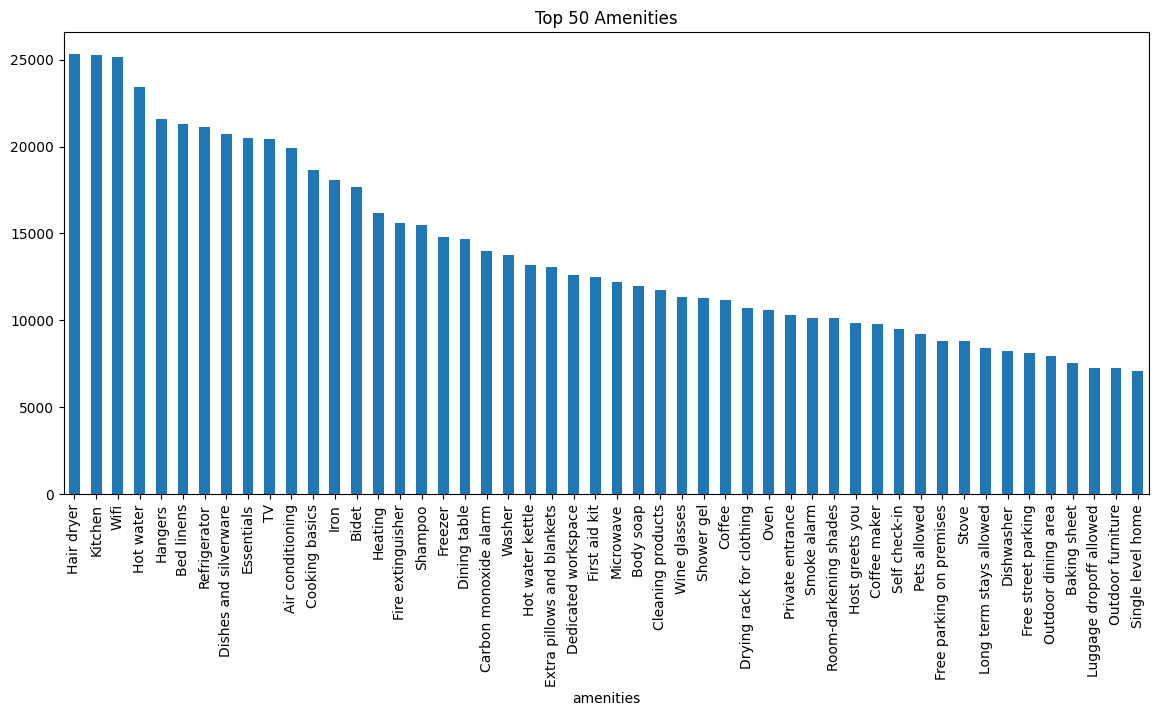

In [26]:
top_amenities = all_amenities.head(50)
top_amenities.plot.bar(figsize=(14, 6), title="Top 50 Amenities")

Si può notare come le categorie hanno una distribuzione piuttosto uniforme, con nessuna categoria che rappresenta una percentuale eccessiva rispetto alle altre. Tuttavia è da considerare che questo campo contiene circa 16000 categorie uniche, quindi è possibile che alcune categorie siano rappresentate da un numero molto basso di istanze.

Nella parte del pre-processing, è possibile decidere di mantenere solo i servizi più frequenti, in modo da ridurre la dimensionalità del dataset e migliorare la performance del modello di regressione. Un altro dato utile potrebbe essere contare il numero di amenità presenti in ogni record, in modo da avere una variabile numerica che rappresenta la quantità di servizi offerti da ogni alloggio, che potrebbe essere ulteriormente utile per la predizione del prezzo.

<Axes: title={'center': 'Top 50 Neighbourhoods'}, xlabel='neighbourhood_cleansed'>

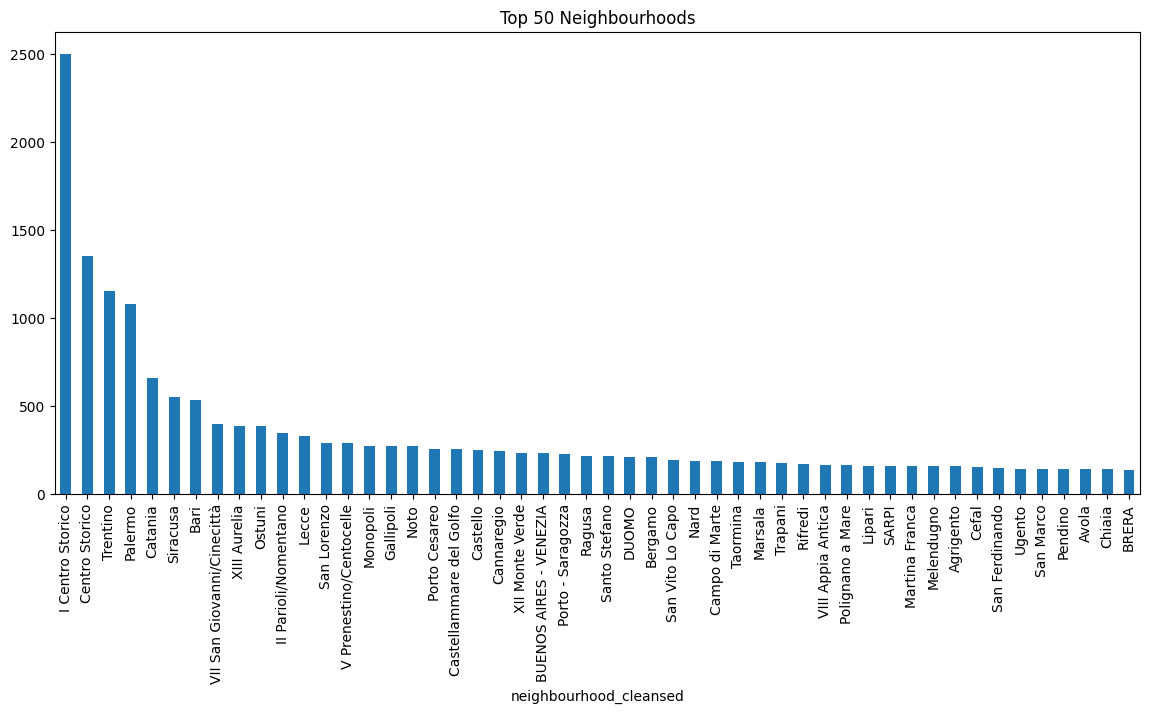

In [27]:
top_neighbourhoods = neighbourhoods.head(50)
top_neighbourhoods.plot.bar(figsize=(14, 6), title="Top 50 Neighbourhoods")

Per quanto riguarda i quartieri, le categorie più frequenti sono i centri storici delle città più grandi, in quanto sono le zone più turistiche e quindi più richieste per l'affitto di case vacanze. Oltre ai centri storici, sono presenti anche quartieri residenziali e quartieri periferici, che potrebbero essere meno richiesti ma comunque presenti nel dataset. I livelli di granularità dei quartieri sono diversi, con alcuni quartieri che rappresentano intere città, mentre altri rappresentano solo dei quartieri specifici all'interno di una città.

<Axes: title={'center': 'Top 50 Property Types'}, xlabel='property_type'>

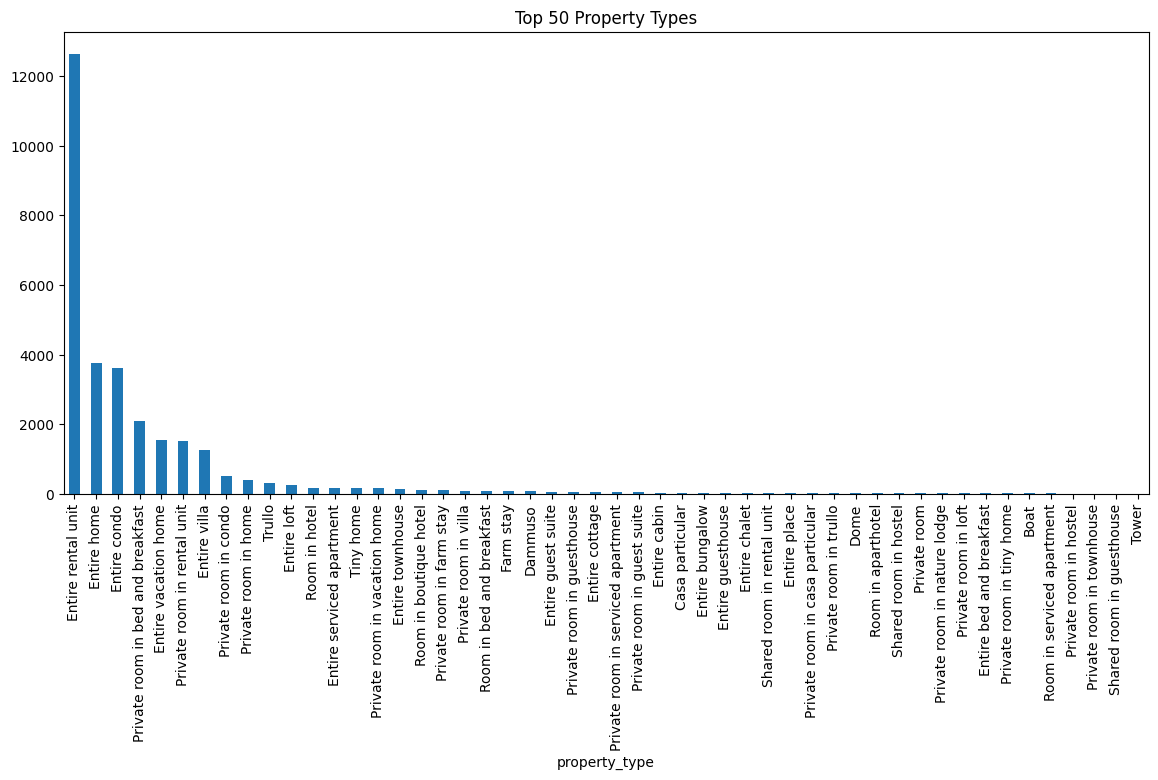

In [28]:
top_property_types = property_types.head(50)
top_property_types.plot.bar(figsize=(14, 6), title="Top 50 Property Types")

Si può vedere come le categorie più frequenti di `property_type` siano concentrate su appartamenti, case vacanze e case indipendenti, che sono le tipologie di alloggio più richieste per l'affitto di case vacanze. Oltre a queste tipologie, sono presenti anche altre tipologie di alloggio meno richieste ma comunque presenti nel dataset.

<Axes: xlabel='room_type'>

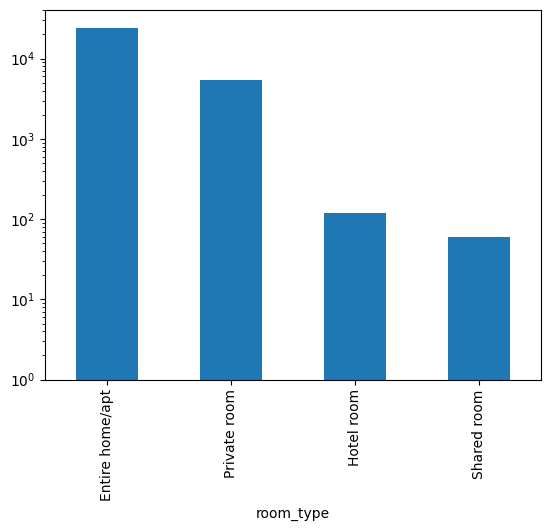

In [29]:
room_types.plot.bar(log=True)

Questo grafico mostra la distribuzione delle tipologie di alloggio presenti nel dataset. Come si può vedere, le tipologie più frequenti sono gli appartamenti, seguiti dalle stanze private. Il grafico è in scala logaritmica, in quanto ci sono solo un migliario di stanze d'hotel o stanze condivise, mentre per le altre tipologie di alloggio sono presenti decine di migliaia di istanze.

#### 2.1.d Correlation matrix and heatmap


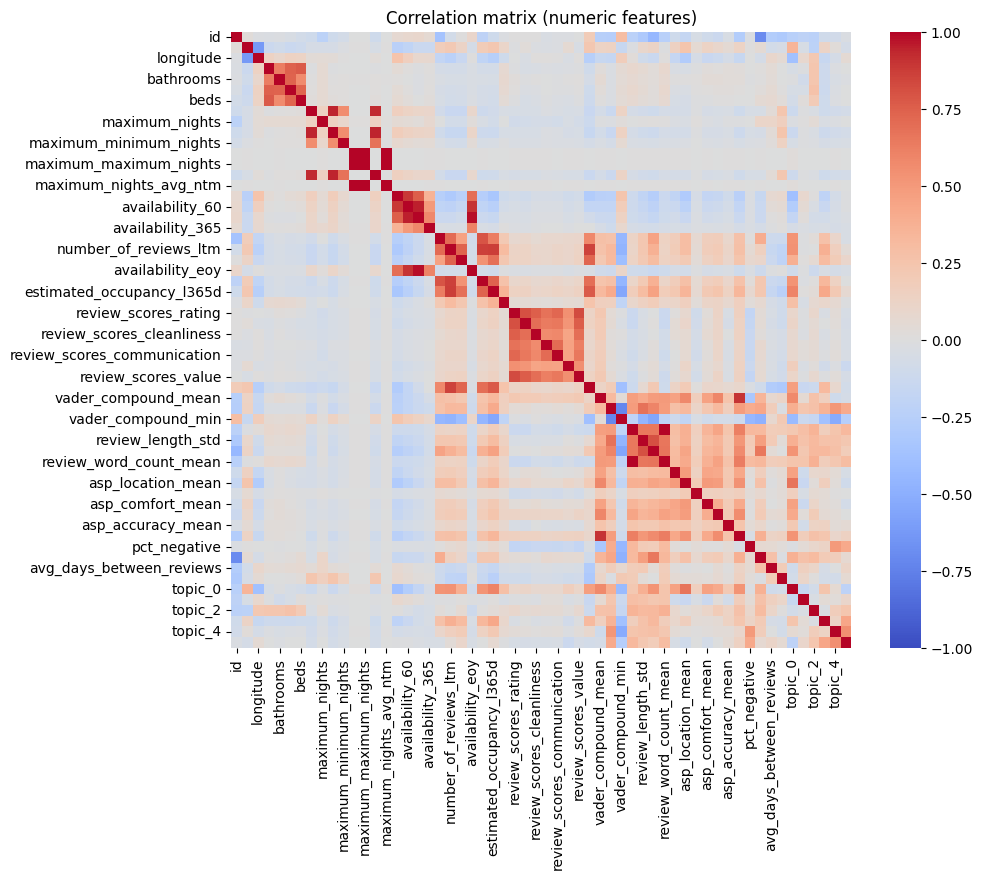

In [30]:
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
corr = df[num_cols].corr()
plt.figure(figsize=(10,8))
sns.heatmap(corr, cmap='coolwarm', center=0, vmin=-1, vmax=1)
plt.title('Correlation matrix (numeric features)')
plt.show()

Questa sottosezione visualizza la **matrice di correlazione** tra tutte le variabili numeriche del dataframe tramite una **heatmap**:

- Ogni cella della matrice misura la correlazione lineare tra due variabili numeriche.
- I valori vanno da **-1** a **1**:
  - **1** = correlazione positiva perfetta.
  - **0** = nessuna relazione lineare evidente.
  - **-1** = correlazione negativa perfetta.
- La diagonale principale è sempre pari a 1, perché ogni variabile è perfettamente correlata con sé stessa.

Come interpretare i colori della heatmap:

- Toni **rossi**: relazione positiva, cioè le due variabili tendono a crescere insieme.
- Toni **blu**: relazione negativa, cioè una cresce mentre l'altra tende a scendere.
- Toni molto chiari o quasi neutri: relazione debole o assente.

Cose interessanti da osservare nel nostro caso:

- Blocchi forti tra `accommodates`, `bathrooms`, `bedrooms` e `beds`: indicano che descrivono dimensioni simili dell'alloggio.
- Correlazioni tra `availability_30`, `availability_60`, `availability_90` e `availability_365`: sono attese perché misurano la disponibilità nello stesso senso ma su finestre diverse.
- Relazioni tra `number_of_reviews`, `reviews_per_month` e i punteggi recensione: utili per capire se l'attività dell'alloggio è associata alla qualità percepita.
- Eventuali correlazioni con `price` e `estimated_occupancy_l365d`: sono quelle più utili in vista dei modelli di regressione.

### 2.3 Specifiche per le singole task


Questa sezione contiene le specifiche per l'analisi esplorativa dei dati mirata alle singole task.

Le celle sono suddivise in sotto-sezioni:

- **2.3.a** Price Prediction
- **2.3.b** Occupancy Regression
- **2.3.c** NLP Classification
- **2.3.d** Recommendation System


#### 2.3.a - Price Regression

Per il task di regressione su `price` è necessario filtrare i dati per rimuovere le feature non necessarie. In particolare è necessario rimuovere le feature riguardanti il tasso di occupazione, in quanto non sono importanti per la predizione del prezzo.

Creiamo quindi un nuovo DataFrame `lst_for_price_analysis` che contiene solo le feature necessarie per la predizione del prezzo. In particolare, rimuoviamo le feature riguardanti il tasso di occupazione e la disponibilità:

- `minimum_nights`, `maximum_nights`, `minimum_minimum_nights`, `maximum_minimum_nights`, `minimum_maximum_nights`, `maximum_maximum_nights`, `minimum_nights_avg_ntm`, `maximum_nights_avg_ntm`
- `calendar_updated`, `has_availability`, `availability_30`, `availability_60`, `availability_90`, `availability_365`, `calendar_last_scraped`
- `number_of_reviews`, `number_of_reviews_ltm`, `number_of_reviews_l30d`, `availability_eoy`, `number_of_reviews_ly`
- `estimated_occupancy_l365d`, `estimated_revenue_l365d`


Manteniamo quindi solo le feature che potrebbero essere utili per la predizione del prezzo, ovvero:
- `id`
- `listing_url`
- `neighbourhood_cleansed`
- `latitude`
- `longitude`
- `property_type`
- `room_type`
- `accommodates`
- `bathrooms`
- `bedrooms`
- `beds`
- `amenities`
- `price`

In [31]:
filtered_features = [
    "id",
    "neighbourhood_cleansed",
    "latitude",
    "longitude",
    "property_type",
    "room_type",
    "accommodates",
    "bathrooms",
    "bedrooms",
    "beds",
    "amenities",
    "price",
    "city"
]

lst_for_price_analysis = df[filtered_features]

lst_for_price_analysis.info()

<class 'pandas.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 13 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   id                      30000 non-null  int64  
 1   neighbourhood_cleansed  30000 non-null  str    
 2   latitude                30000 non-null  float64
 3   longitude               30000 non-null  float64
 4   property_type           30000 non-null  str    
 5   room_type               30000 non-null  str    
 6   accommodates            30000 non-null  int64  
 7   bathrooms               29984 non-null  float64
 8   bedrooms                29964 non-null  float64
 9   beds                    29981 non-null  float64
 10  amenities               30000 non-null  str    
 11  price                   30000 non-null  str    
 12  city                    30000 non-null  str    
dtypes: float64(5), int64(2), str(6)
memory usage: 3.0 MB


Il nuovo DataFrame `lst_for_price_analysis` contiene quindi 12 variabili, di cui 11 sono feature e 1 è la variabile da predire. Le feature sono sono perlopiù numeriche. Ci sono alcune feature categoriche:
- `neighbourhood_cleansed`
- `property_type`
- `room_type`
- `amenities`

Che possono essere importanti per la predizione del prezzo, ma che vanno trattate in modo diverso dalle feature numeriche. In particolare, è necessario trasformare le feature categoriche viste nella sezione precedente in nuove variabili binarie.
Inoltre bisogna trattare anche il valore di `price`, che è una stringa. Per poter utilizzare questa variabile e poterla visualizzare nei plot, è necessario trasformarla in un valore numerico.

Vediamo ora il formato della variabile `price`.

In [32]:
print(lst_for_price_analysis["price"])

0         $18.00
1        $168.00
2         $74.00
3        $130.00
4        $180.00
          ...   
29995    $149.00
29996     $70.00
29997    $171.00
29998    $145.00
29999     $97.00
Name: price, Length: 30000, dtype: str


Come si può vedere, la variabile `price` è una stringa che contiene il simbolo del dollaro e le virgole per le migliaia. Per poter utilizzare questa variabile e poterla visualizzare nei plot, è necessario trasformarla in un valore numerico:

In [33]:
lst_for_price_analysis["price"] = (
    lst_for_price_analysis["price"]
        .str.replace('$', '', regex=False)
        .str.replace(',', '', regex=False)
        .astype(float)
)
lst_for_price_analysis["price"]

0         18.0
1        168.0
2         74.0
3        130.0
4        180.0
         ...  
29995    149.0
29996     70.0
29997    171.0
29998    145.0
29999     97.0
Name: price, Length: 30000, dtype: float64

Adesso `price` è una variabile numerica che può essere utilizzata per la predizione del prezzo.

Ora applichiamo il metodo describe al nuovo DataFrame `lst_for_price_analysis` per avere una prima idea della distribuzione dei dati dopo il filtraggio.

In [34]:
lst_for_price_analysis.describe()

,id,latitude,longitude,accommodates,bathrooms,bedrooms,beds,price
count,3.000000e+04,30000.000000,30000.000000,30000.000000,29984.000000,29964.000000,29981.000000,30000.000000
mean,7.258799e+17,41.343912,13.585587,4.073233,1.338164,1.592111,2.462760,296.519567
std,5.780211e+17,2.892676,2.690808,2.132765,0.849327,1.032929,1.751314,1191.028571
min,2.058700e+04,35.495377,9.066860,1.000000,0.000000,0.000000,0.000000,9.000000
25%,3.985954e+07,38.179595,11.999887,2.000000,1.000000,1.000000,1.000000,73.000000
50%,8.913041e+17,41.051930,12.883120,4.000000,1.000000,1.000000,2.000000,106.000000
75%,1.242834e+18,43.775272,15.270109,5.000000,1.500000,2.000000,3.000000,168.000000
max,1.520310e+18,46.493080,18.494540,16.000000,44.000000,44.000000,44.000000,52500.000000


La `latitudine`, come aspettato, è compresa tra 35.6 e 46.5, mentre la `longitudine` tra 9 e 18.5, che corrispondono alla posizione geografica dell'Italia. Per quanto riguarda le variabili `accomodates`, `bathrooms`, `bedrooms` e `beds`, si nota che sono presenti dei valori outliers.

Difatti il numero massimo di `accomodates` è 16, ancora accettabile, ma ben più alto dal valore del percentile 75 che equivale a 5. Per di più il numero massimo di `bathrooms` è 100, di `bedrooms` è 44 e di `beds` è 50, che sono valori molto elevati e potrebbero essere considerati outliers risultato di errori di immissione.

Questi valori si discostano significativamente dai dati, e possono influenzare negativamente la performance del modello di regressione. Per questo motivo, è necessario trattarli prima di procedere con la fase di modellazione.

Per quanto riguarda la variabile `price`, si nota che il prezzo massimo è 80000, mentre il prezzo del 75-esimo percentile è 168. Questo indica che ci sono dei valori di prezzo molto elevati che potrebbero anche essi essere considerati outliers.

Prima di andare a visualizzare con dei plot la distribuzione delle variabili, trattiamo i valori mancanti, visti nella sezione precedente. Visualizziamo comunque per ogni variabile il numero di valori mancanti:

In [35]:
na_values = lst_for_price_analysis.isna().sum()
print(na_values)

id                         0
neighbourhood_cleansed     0
latitude                   0
longitude                  0
property_type              0
room_type                  0
accommodates               0
bathrooms                 16
bedrooms                  36
beds                      19
amenities                  0
price                      0
city                       0
dtype: int64


Come possiamo vedere le variabili `bathrooms`, `bedrooms` e `beds` contengono un numero poco significativo di valori mancanti rispetto ai dati totali. Si suppone che questi valori mancanti siano dovuti a errori di immissione, siccome è impossibile avere un alloggio con 0 camere o 0 letti. Per quanto riguarda i bagni, è possibile che ci siano alloggi senza bagno, ma è più probabile che si tratti di errori di immissione. 

Per questi motivi:
- Per le variabili `bedrooms` e `beds`, si suppone che i valori mancanti siano dovuti a errori di immissione e verranno tolti dal dataset.
- Per la variabile `bathrooms`, si suppone che effettivamente ci siano alloggi senza bagno, quindi i valori mancanti verranno sostituiti con 0.

In [36]:
lst_for_price_analysis = lst_for_price_analysis.dropna(subset=["bedrooms", "beds"])
lst_for_price_analysis["bathrooms"] = lst_for_price_analysis["bathrooms"].fillna(0)
na_values = lst_for_price_analysis.isna().sum()
print(na_values)

id                        0
neighbourhood_cleansed    0
latitude                  0
longitude                 0
property_type             0
room_type                 0
accommodates              0
bathrooms                 0
bedrooms                  0
beds                      0
amenities                 0
price                     0
city                      0
dtype: int64


Ora non abbiamo più valori mancanti nelle variabili `bathrooms`, `bedrooms` e `beds`, e possiamo procedere con la visualizzazione della distribuzione delle variabili tramite dei plot.

Come primo plot, è possibile visualizzare la distribuzione della variabile `price` tramite un istogramma. In questo modo è possibile vedere se ci sono dei valori di prezzo molto elevati che potrebbero essere considerati outliers.

<Axes: ylabel='Frequency'>

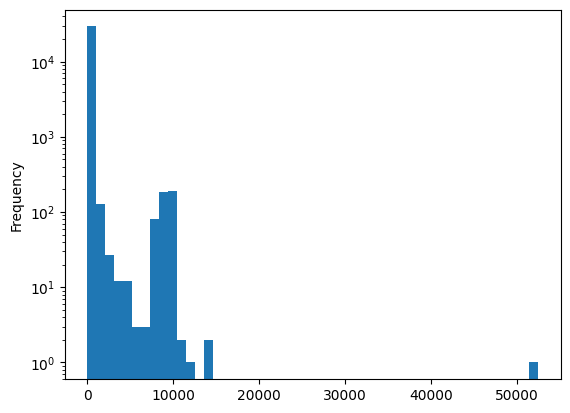

In [37]:
lst_for_price_analysis["price"].plot.hist(
    bins=50,
    log=True,
)

Come si può vedere, la distribuzione della variabile `price` è molto sbilanciata, con la maggior parte dei valori concentrati tra 0 e 10000, con alcuni valori molto elevati che potrebbero essere considerati outliers. Decidiamo di togliere i valori estremi, in particolare sopra i 10000 e sotto i 5. Il grafico è in scala logaritmica, in modo tale che anche i valori più elevati siano visibili. Questa cosa può essere vista anche con il boxplot:

In [38]:
# lst_for_price_analysis["price"] = lst_for_price_analysis["price"][lst_for_price_analysis["price"] < 1000]

Ora si può vedere che la distribuzione di price si concentra su due picchi principali, uno intorno a 5-2000 e l'altro intorno a 7000-1000. Questo potrebbe indicare che ci sono due categorie principali di alloggi, alcuni più economici e altri che potrebbero essere considerati di lusso.

Controlliamo ora il boxplot della variabile `price` per identificare visivamente la presenza di outliers e la distribuzione dei prezzi.

In [39]:
def cut_outliers(df, columns, coeff=1.5):
    for column in columns:
        Q1 = df[column].quantile(0.25)
        Q3 = df[column].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - coeff * IQR
        upper_bound = Q3 + coeff * IQR
        df = df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]

    return df

In [40]:
lst_for_price_analysis = cut_outliers(lst_for_price_analysis, ["price", "beds"], coeff=3.0)

<Axes: ylabel='Frequency'>

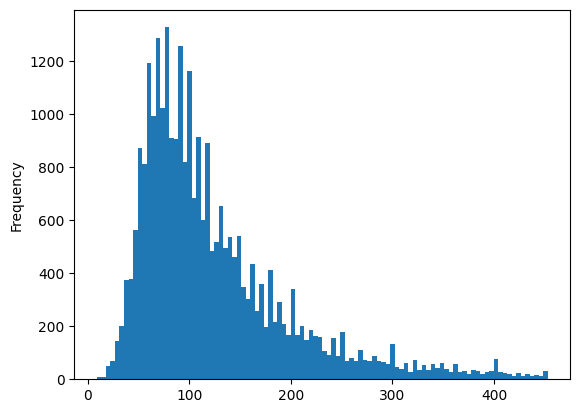

In [41]:
# lst_for_price_analysis["price"] = lst_for_price_analysis["price"].clip(upper=10000, lower=5)
lst_for_price_analysis["price"].plot.hist(
    bins=100,
)

<Axes: >

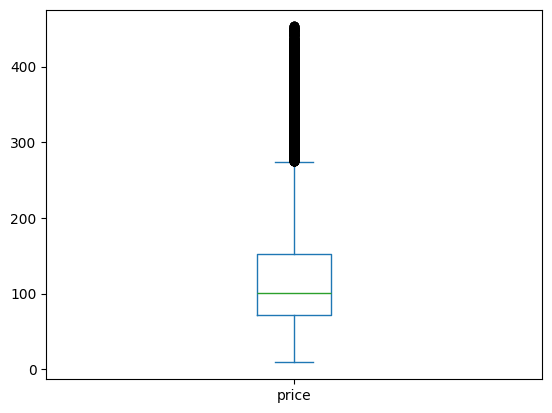

In [42]:
lst_for_price_analysis["price"].plot.box()

Proviamo a creare un istogramma colorato in base al `room_type`, per vedere se ci sono differenze nella distribuzione dei prezzi in base al tipo di alloggio.

C:\Users\cecca\AppData\Local\Temp\ipykernel_21588\2107741568.py:8: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title="Room Type")


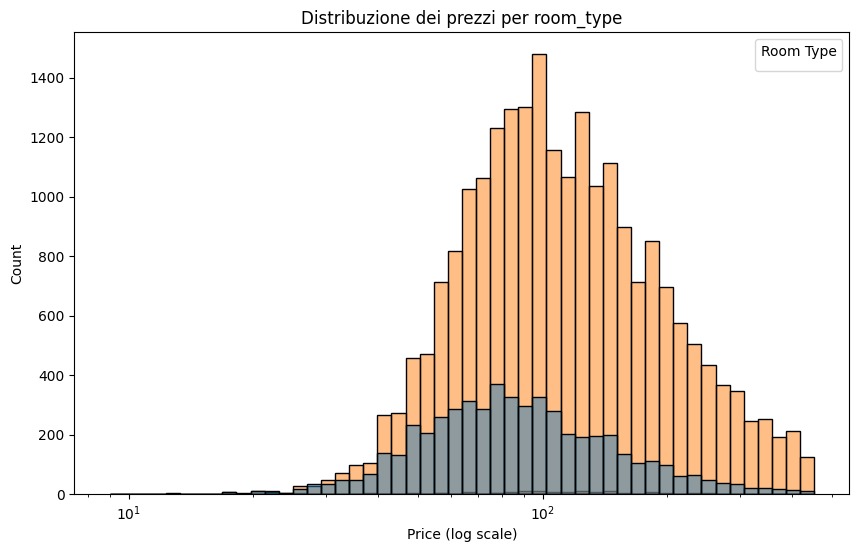

In [43]:
# Proviamo a creare un istogramma colorato in base al `room_type`, per vedere se ci sono differenze nella distribuzione dei prezzi in base al tipo di alloggio.
room_types = lst_for_price_analysis["room_type"].values
plt.figure(figsize=(10, 6))
sns.histplot(data=lst_for_price_analysis, x="price", hue=room_types, bins=50, log_scale=True)
plt.title("Distribuzione dei prezzi per room_type")
plt.xlabel("Price (log scale)")
plt.ylabel("Count")
plt.legend(title="Room Type")
plt.show()

Generiamo ora degli istogrammi per le variabili `accomodates`, `bathrooms`, `bedrooms` e `beds` per visualizzare meglio la presenza di outliers.

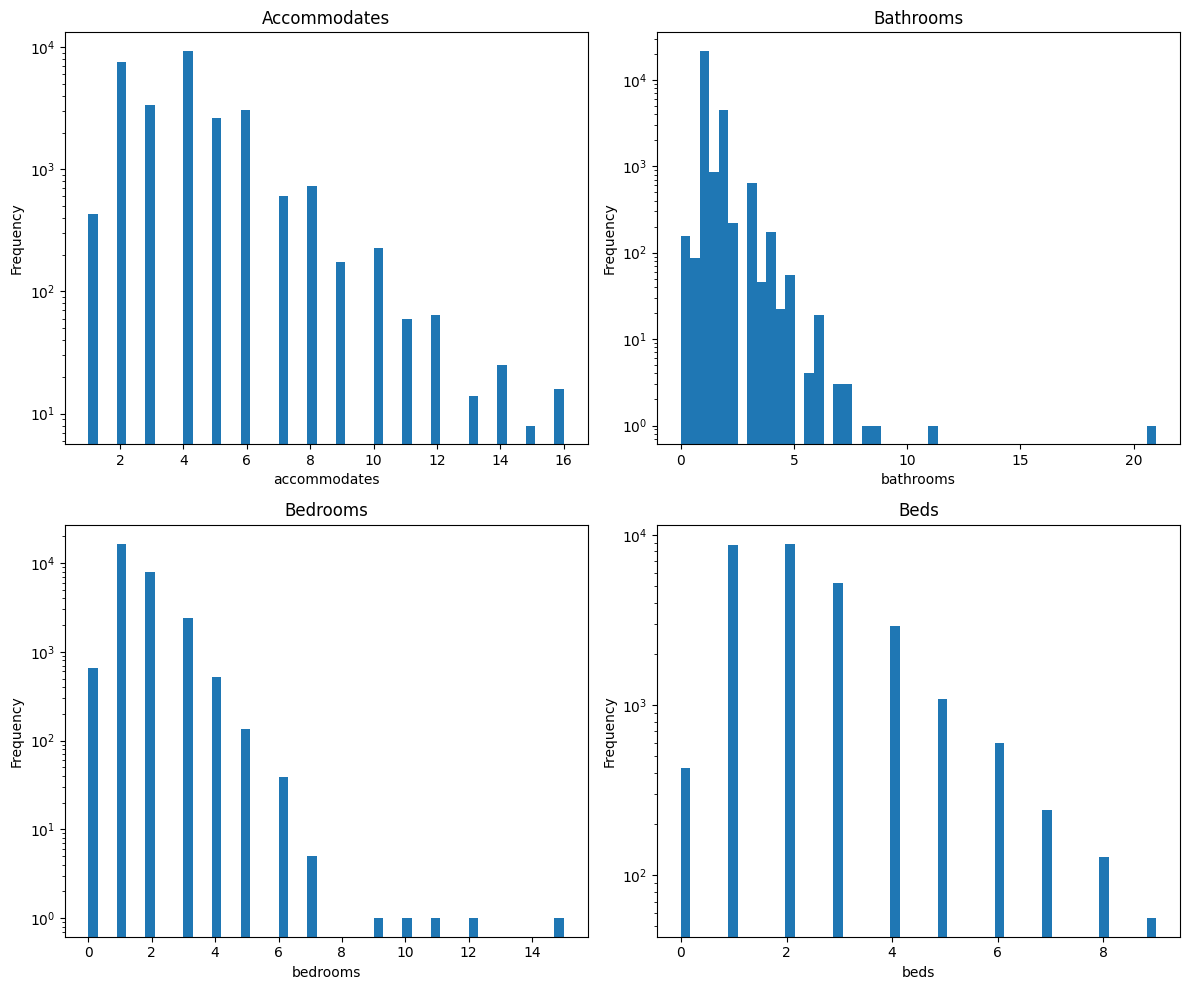

In [44]:
cols = ["accommodates", "bathrooms", "bedrooms", "beds"]

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.ravel() # Appiattisce la matrice di assi in un array 1D per iterare più facilmente

for ax, col in zip(axes, cols):
    lst_for_price_analysis[col].dropna().plot.hist(
        bins=50,
        log=True,
        ax=ax,
    )
    ax.set_title(col.capitalize())
    ax.set_xlabel(col)
    ax.set_ylabel("Frequency")

plt.tight_layout()
plt.show()

Come si può vedere bathrooms, bedrooms e beds presentano dei valori molto elevati che sono il risultato di probabili errori di immissione. Per questo motivo questi valori saranno eliminati dal dataset:
- `bathrooms` < 20
- `bedrooms` < 22
- `beds` < 35

In [45]:
lst_wout_outl_p_a = lst_for_price_analysis[
    (lst_for_price_analysis["bathrooms"] < 10) &
    (lst_for_price_analysis["bedrooms"] < 22) &
    (lst_for_price_analysis["beds"] < 35)
]

In [46]:
# lst_wout_outl_p_a = cut_outliers(lst_wout_outl_p_a, ["bathrooms", "bedrooms", "beds"], coeff=3.0)

Adesso generiamo i boxplot per tutte le variabili per visualizzare il risulato del filtraggio degli outliers dati da palesi errori di immissione.

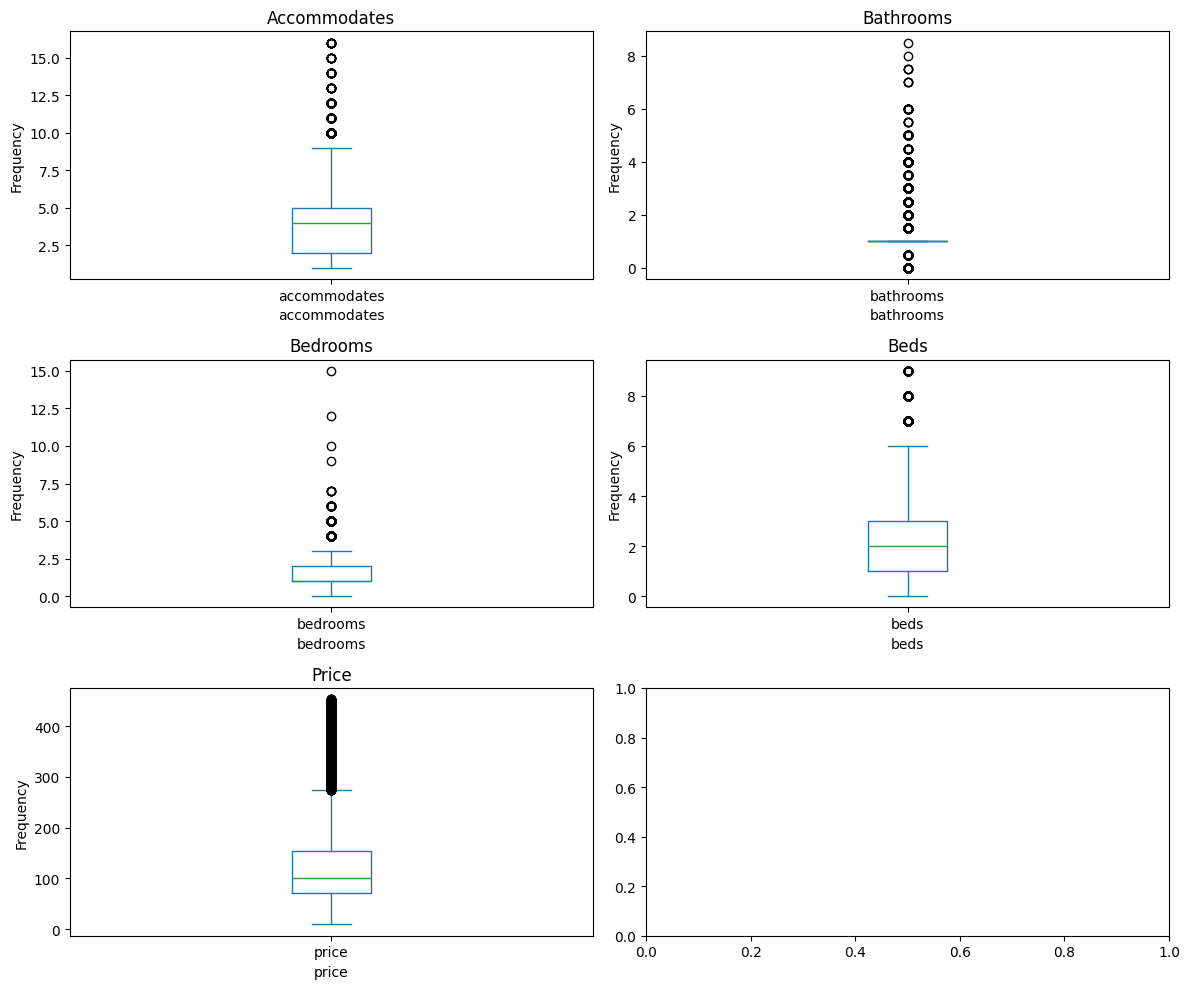

In [47]:
cols = ["accommodates", "bathrooms", "bedrooms", "beds", "price"]

fig, axes = plt.subplots(len(cols) // 2 + len(cols) % 2, len(cols) // 2, figsize=(12, 10))
axes = axes.ravel() # Appiattisce la matrice di assi in un array 1D per iterare più facilmente

for ax, col in zip(axes, cols):
    lst_wout_outl_p_a[col].dropna().plot.box(
        ax=ax,
    )
    ax.set_title(col.capitalize())
    ax.set_xlabel(col)
    ax.set_ylabel("Frequency")

plt.tight_layout()
plt.show()

Ora proviamo a visualizzare la relazione tra `price` e le variabili `accomodates`, `bathrooms`, `bedrooms` e `beds` tramite dei scatter plot. In questo modo è possibile vedere se ci sono delle relazioni tra queste variabili e il prezzo, e se ci sono dei valori di prezzo molto elevati che potrebbero essere considerati outliers.

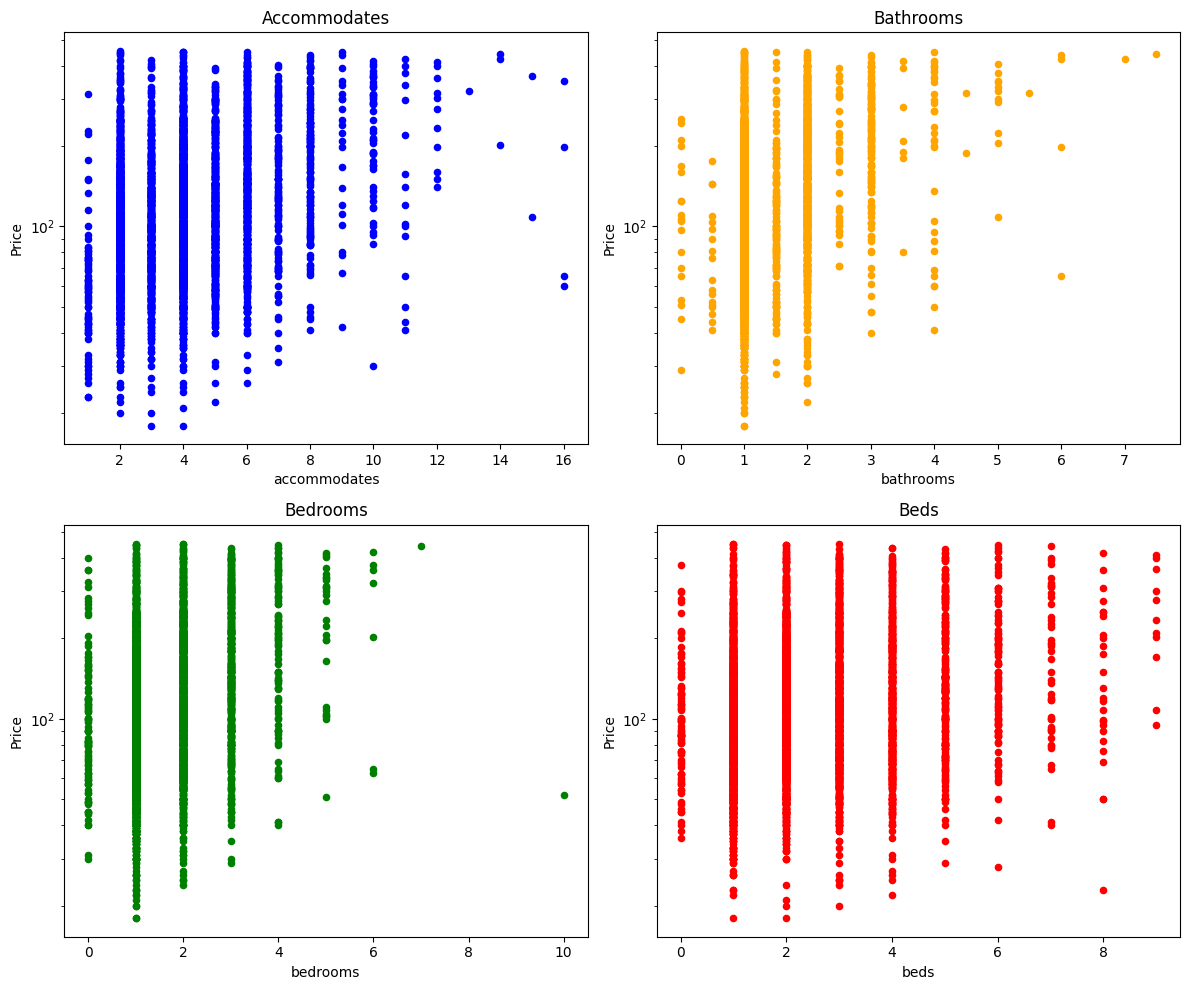

In [48]:
cols = ["accommodates", "bathrooms", "bedrooms", "beds"]
colors = ["blue", "orange", "green", "red"]

sample = lst_wout_outl_p_a.sample(n=5000, random_state=7112004)

fig, axes = plt.subplots(len(cols) // 2 + len(cols) % 2, len(cols) // 2, figsize=(12, 10))
axes = axes.ravel()

for ax, col in zip(axes, cols):
    sample[["price", col]].plot.scatter(
        x=col,
        y="price",
        ax=ax,
        logy= True,
        c=colors[cols.index(col)]
    )
    ax.set_title(col.capitalize())
    ax.set_xlabel(col)
    ax.set_ylabel("Price")

plt.tight_layout()
plt.show()

In tutti e quattro i grafici si vede una tendenza positiva, anche se debole: all'aumentare del numero di `accomodates`, `bathrooms`, `bedrooms` e `beds`, aumenta anche il prezzo. Sicuramente variabili categoriche che abbiamo lasciato fuori da questa analisi, come `neighbourhood_cleansed`, `property_type`, `room_type` e `amenities`, possono avere anche esse un impatto sul prezzo, e potrebbero essere utili per migliorare la performance del modello di regressione.

Adesso analizziamo queste variabili. Estraiamo i valori unici per ogni variabile categorica:

Le ultime variabili da esplorare che possono essere utili per la predizione del prezzo sono le densità di letti, camere e bagni per ogni alloggio. Aggiungiamo quindi quattro nuove variabili al dataset:
- `beds_per_person` = `beds` / `accomodates`: il numero di letti per persona. Un valore più alto di questa variabile potrebbe indicare un alloggio più confortevole, e quindi potrebbe essere associato a un prezzo più elevato.
- `bedrooms_per_person` = `bedrooms` / `accomodates`: il numero di camere da letto per persona. Un valore più alto di questa variabile potrebbe indicare un alloggio più spazioso, e quindi potrebbe essere associato a un prezzo più elevato.
- `bathrooms_per_person` = `bathrooms` / `accomodates`: il numero di bagni per persona. Un valore più alto di questa variabile potrebbe indicare un alloggio più confortevole, e quindi potrebbe essere associato a un prezzo più elevato.
- `beds_per_bedroom` = `beds` / `bedrooms`: il numero di letti per camera da letto. Un valore più alto di questa variabile potrebbe indicare un alloggio più spazioso, e quindi potrebbe essere associato a un prezzo più elevato.

In [49]:
data = lst_wout_outl_p_a.copy()
data["beds_per_person"] = data["beds"] / data["accommodates"]
data["bedrooms_per_person"] = data["bedrooms"] / data["accommodates"]
data["bathrooms_per_person"] = data["bathrooms"] / data["accommodates"]
data["beds_per_bedroom"] = data["beds"] / data["bedrooms"]
print(data)

                        id      neighbourhood_cleansed   latitude  longitude  \
0      1503565632325764205              QUARTO CAGNINO  45.471160   9.112930   
1       796228410550521671                       SARPI  45.481843   9.180663   
2      1167277763401356093  VII San Giovanni/Cinecittà  41.857370  12.561740   
3      1095420188138298131                      Alcamo  37.982417  12.965278   
4                 19867016            I Centro Storico  41.907230  12.457060   
...                    ...                         ...        ...        ...   
29995             17518816                    Trentino  46.290880  11.460770   
29996             13343779                     Pulsano  40.363670  17.353770   
29997  1462518426635349018                       DUOMO  45.464626   9.194502   
29998  1401571388625364925                  Rutigliano  41.016901  17.018704   
29999  1262369374479364929                    Marghera  45.472891  12.226631   

                           property_typ

Ora creiamo un grafico nello stile di quello superiore, per visualizzare se ci sono delle relazioni tra queste nuove variabili e il prezzo.

In [50]:
def plot_price_vs_features(
    data,
    cols,
    n_cols=2,
    colors=None,
    sample_n=7000,
    random_state=7112004,
    figsize=(12, 10),
    logx=True,
    logy=True,
):
    if colors is None:
        colors = ["blue"] * len(cols)
    sample_n = min(sample_n, len(data))
    sample = data.sample(n=sample_n, random_state=random_state)

    n_plots = len(cols)
    n_rows = (n_plots + n_cols - 1) // n_cols

    fig, axes = plt.subplots(n_rows, n_cols, figsize=figsize)
    axes = np.atleast_1d(axes).ravel()

    for idx, col in enumerate(cols):
        ax = axes[idx]
        sample.plot.scatter(
            x=col,
            y="price",
            ax=ax,
            logx=logx,
            logy=logy,
            c=[colors[idx % len(colors)]],
            alpha=0.3
        )
        ax.set_title(col.capitalize())
        ax.set_xlabel(col)
        ax.set_ylabel("Price")
        ax.grid(True)

    plt.tight_layout()
    plt.show()
    return fig, axes

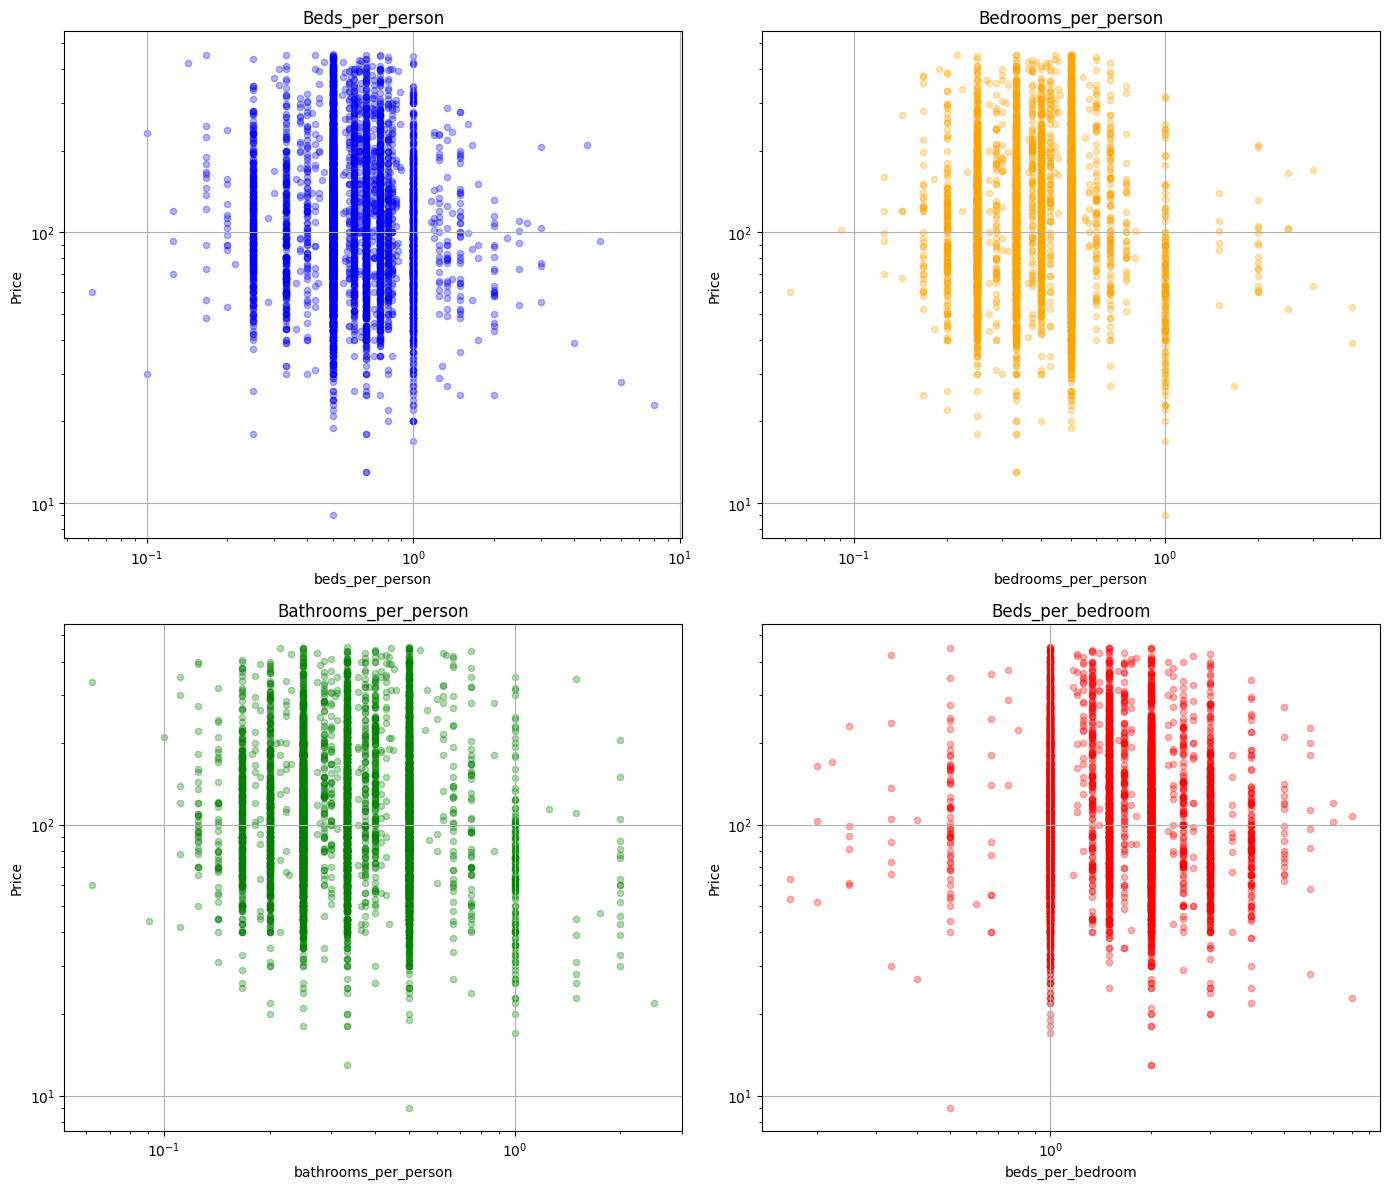

(<Figure size 1400x1200 with 4 Axes>,
 array([<Axes: title={'center': 'Beds_per_person'}, xlabel='beds_per_person', ylabel='Price'>,
        <Axes: title={'center': 'Bedrooms_per_person'}, xlabel='bedrooms_per_person', ylabel='Price'>,
        <Axes: title={'center': 'Bathrooms_per_person'}, xlabel='bathrooms_per_person', ylabel='Price'>,
        <Axes: title={'center': 'Beds_per_bedroom'}, xlabel='beds_per_bedroom', ylabel='Price'>],
       dtype=object))

In [51]:
plot_price_vs_features(
    data,
    cols=["beds_per_person", "bedrooms_per_person", "bathrooms_per_person", "beds_per_bedroom"],
    colors=["blue", "orange", "green", "red"],
    sample_n=7000,
    figsize=(14, 12),
)

Tutte e quattro le variabili non mostrano una relazione molto forte con il prezzo. Per una visualizzazione più chiara è stato utilizzato il logaritmo anche dell'asse x. Possono però essere effettuate le seguenti osservazioni:
- `beds_per_person` e `bedrooms_per_person`: si nota una lieve concentrazione dei prezzi più elevati in corrispondenza di valori prossimi a 1, ovvero listing con un letto o una camera per ospite. Tuttavia la dispersione è elevata, quindi il potere predittivo di queste feature è limitato.
- `bathrooms_per_person`: non emerge alcuna tendenza chiara. La distribuzione è sostanzialmente piatta lungo l'asse x, indicando una scarsa correlazione con il prezzo.
- `beds_per_bedroom`: si osserva una leggera tendenza inversa, infatti listing con più letti per camera (ipoteticamente dormitori o strutture condivise) tendono ad avere prezzi più bassi. Questa feature potrebbe quindi catturare indirettamente anche la tipologia di alloggio.

Un altro dato utile da estrarre potrebbe essere il calcolo della distanza di ogni alloggio dal centro della città, in modo da avere una variabile numerica che rappresenta la posizione geografica dell'alloggio. Per fare ciò, bisogna calcolare la distanza tra le coordinate geografiche di ogni alloggio e le coordinate del centro della città. In questo modo, si ottiene una nuova variabile numerica `distance_from_city_center` che potrebbe essere utile per la predizione del prezzo, siccome gli alloggi più vicini al centro potrebbero essere associati a un prezzo più elevato.

Creiamo quindi un dizionario con le coordinate del centro di ogni città presente nel dataset, in modo da poter calcolare la distanza di ogni alloggio dal centro della città. I dati sono stati presi da un LLM, e sono approssimativi, ma dovrebbero essere sufficienti per il nostro scopo.

In [52]:
lst_for_price_analysis = lst_wout_outl_p_a.copy()

In [53]:
city_centers = {
    "bergamo": [{"lat": 45.6983, "lon": 9.6773}],
    "bologna": [{"lat": 44.4949, "lon": 11.3426}],
    "firenze": [{"lat": 43.7696, "lon": 11.2558}],
    "milano":  [{"lat": 45.4654, "lon": 9.1859}],
    "napoli":  [{"lat": 40.8518, "lon": 14.2681}],
    "puglia": [
        {"city": "Bari",      "lat": 41.1171, "lon": 16.8719},
        {"city": "Foggia",    "lat": 41.4621, "lon": 15.5444},
        {"city": "Taranto",   "lat": 40.4644, "lon": 17.2470},
        {"city": "Lecce",     "lat": 40.3516, "lon": 18.1752},
        {"city": "Brindisi",  "lat": 40.6326, "lon": 17.9417},
        {"city": "Andria",    "lat": 41.2278, "lon": 16.2961},
        {"city": "Barletta",  "lat": 41.3197, "lon": 16.2820},
    ],
    "roma":    [{"lat": 41.9028, "lon": 12.4964}],
    "sicilia": [
        {"city": "Palermo",   "lat": 38.1157, "lon": 13.3615},
        {"city": "Catania",   "lat": 37.5079, "lon": 15.0830},
        {"city": "Messina",   "lat": 38.1938, "lon": 15.5540},
        {"city": "Siracusa",  "lat": 37.0755, "lon": 15.2866},
        {"city": "Agrigento", "lat": 37.3111, "lon": 13.5765},
        {"city": "Trapani",   "lat": 38.0176, "lon": 12.5365},
        {"city": "Ragusa",    "lat": 36.9282, "lon": 14.7256},
    ],
    "trentino": [
        {"city": "Trento",      "lat": 46.0748, "lon": 11.1217},
        {"city": "Bolzano",     "lat": 46.4983, "lon": 11.3548},
        {"city": "Rovereto",    "lat": 45.8912, "lon": 11.0396},
        {"city": "Merano",      "lat": 46.6713, "lon": 11.1594},
        {"city": "Bressanone",  "lat": 46.7154, "lon": 11.6565},
    ],
    "venezia": [{"lat": 45.4408, "lon": 12.3155}],
}

Per il centro delle regioni sono stati scelti i centri delle città più importanti. Ora creiamo una funzione `calculate_distances_from_city_center` che calcola la distanza tra le coordinate di ogni alloggio e le coordinate del centro della città. Siccome le regioni hanno più città, facciamo in modo che ritorni la lista delle distanze da ogni centro, in modo da poter prendere la distanza minima come distanza dell'alloggio dal centro della regione.

Siccome la terra è sferica, è necessario utilizzare la formula dell'haversine per calcolare la distanza tra due punti sulla superficie terrestre. L'idea della formula è quella di, dati due punti su una sfera, calcolare la lunghezza dell'arco che li collega passando per la sua superficie. 

Quindi:
1. Convertiamo le coordinate da gradi a radianti.
2. Calcoliamo le differenze di latitudine e longitudine.
3. Applichiamo la formula dell'haversine per ottenere la distanza in chilometri.

La formula dell'haversine è la seguente:

$$a = sin(\frac{dlat}{2})^2 + cos(lat1) * cos(lat2) * sin(\frac{dlon}{2})^2$$
$$c = 2 * atan2(\sqrt{a}, \sqrt{1−a})$$
$$d = R * c$$
Dove:
- `dlat` è la differenza di latitudine in radianti.
- `dlon` è la differenza di longitudine in radianti.
- `R` è il raggio della Terra (circa 6371 km).

Otteniamo alla fine $d$, che rappresenta la distanza in chilometri tra l'alloggio e il centro della città.

In [54]:
def haversine(lat1, lon1, lat2, lon2):
    R = 6371000  # raggio della Terra in metri
    lat1, lon1, lat2, lon2 = np.radians([lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat / 2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2)**2
    return R * 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))

In [55]:
def calculate_distances_from_city_center(city, lat, lon, city_centers=city_centers):
    centers = city_centers.get(city, [])
    if not centers:
        return None
    distances = [haversine(lat, lon, c["lat"], c["lon"]) for c in centers]
    return distances if distances else None

Applichiamo ora il metodo apply alle colonne `city`, `latitude`, e `longitude` per calcolare la distanza di ogni alloggio dal centro della città, e creiamo la nuova colonna.

In [56]:
lst_for_price_analysis["distance_from_city_center"] = lst_for_price_analysis.apply(
    lambda row: min(calculate_distances_from_city_center(row["city"], row["latitude"], row["longitude"])),
    axis=1
)

In [57]:
lst_for_price_analysis.head()

,id,neighbourhood_cleansed,latitude,longitude,property_type,room_type,accommodates,bathrooms,bedrooms,beds,amenities,price,city,distance_from_city_center
0,1503565632325764205,QUARTO CAGNINO,45.471160,9.112930,Private room in rental unit,Private room,1,2.0,1.0,1.0,"[""Heating"", ""Bed linens"", ""Kitchen"", ""Dining t...",18.0,milano,5726.238082
1,796228410550521671,SARPI,45.481843,9.180663,Entire condo,Entire home/apt,3,1.0,1.0,2.0,"[""Dedicated workspace"", ""Induction stove"", ""Ki...",168.0,milano,1873.447169
2,1167277763401356093,VII San Giovanni/Cinecittà,41.857370,12.561740,Entire condo,Entire home/apt,4,1.0,1.0,0.0,"[""Coffee maker: pour-over coffee"", ""Paid clamp...",74.0,roma,7401.406146
3,1095420188138298131,Alcamo,37.982417,12.965278,Entire rental unit,Entire home/apt,2,1.0,1.0,1.0,"[""Dishes and silverware"", ""Washer"", ""Cooking b...",130.0,sicilia,37727.607683
4,19867016,I Centro Storico,41.907230,12.457060,Entire rental unit,Entire home/apt,4,1.5,1.0,3.0,"[""Hangers"", ""Heating"", ""Carbon monoxide alarm""...",180.0,roma,3292.721615


Tuttavia potrebbero esserci anche degli altri punti di interesse, come ad esempio i punti di interesse turistico, che potrebbero essere utili per la predizione del prezzo. Per questo motivo, si potrebbe considerare di calcolare anche la distanza di ogni alloggio da questi punti di interesse, e creare delle nuove variabili numeriche che rappresentano queste distanze. Estraiamo sempre da un LLM le coordinate di alcuni punti di interesse turistico per le città e le regioni presenti nel dataset:

In [58]:
poi_by_city = {
    "bergamo": [
        {"lat": 45.7040, "lon": 9.6623}, # Campanone
        {"lat": 45.7035, "lon": 9.6622}, # Cappella Colleoni
        {"lat": 45.7035, "lon": 9.6627}, # Cattedrale di Bergamo
        {"lat": 45.7034, "lon": 9.6623}, # Basilica di Santa Maria Maggiore
        {"lat": 45.7038, "lon": 9.6627}, # Palazzo della Ragione
        {"lat": 45.7041, "lon": 9.6630}, # Fontana Contarini
        {"lat": 45.7041, "lon": 9.6578}, # Casematte di San Giovanni
    ],
    "bologna": [
        {"lat": 44.4942, "lon": 11.3467}, # Le Due Torri (Asinelli e Garisenda)
        {"lat": 44.4938, "lon": 11.3431}, # Piazza Maggiore
        {"lat": 44.4919, "lon": 11.3433}, # Palazzo dell'Archiginnasio
        {"lat": 44.4911, "lon": 11.3436}, # Portici di Bologna
        {"lat": 44.4923, "lon": 11.3483}, # Piazza Santo Stefano
        {"lat": 44.4937, "lon": 11.3422}, # Torre dell'Orologio
        {"lat": 44.4896, "lon": 11.3440}, # Basilica di San Domenico
    ],
    "firenze": [
        {"lat": 43.7693, "lon": 11.2562}, # Palazzo Vecchio
        {"lat": 43.7731, "lon": 11.2560}, # Cattedrale di Santa Maria del Fiore
        {"lat": 43.7697, "lon": 11.2556}, # Piazza della Signoria
        {"lat": 43.7686, "lon": 11.2623}, # Basilica di Santa Croce
        {"lat": 43.7629, "lon": 11.2651}, # Piazzale Michelangelo
        {"lat": 43.7729, "lon": 11.2558}, # Campanile di Giotto
        {"lat": 43.7692, "lon": 11.2555}, # Loggia dei Lanzi
    ],
    "milano": [
        {"lat": 45.4641, "lon": 9.1919}, # Duomo di Milano
        {"lat": 45.4642, "lon": 9.1897}, # Piazza del Duomo
        {"lat": 45.4705, "lon": 9.1793}, # Castello Sforzesco
        {"lat": 45.4658, "lon": 9.1899}, # Galleria Vittorio Emanuele II
        {"lat": 45.4660, "lon": 9.1710}, # Basilica di Santa Maria delle Grazie
        {"lat": 45.4864, "lon": 9.1826}, # Torre Arcobaleno
        {"lat": 45.4692, "lon": 9.1809}, # Piazza Castello (Fontana)
    ],
    "napoli": [
        {"lat": 40.8651, "lon": 14.2474}, # Catacombe di San Gennaro
        {"lat": 40.8373, "lon": 14.2455}, # Napoli Sotterranea
        {"lat": 40.8362, "lon": 14.2494}, # Palazzo Reale di Napoli
        {"lat": 40.8536, "lon": 14.2505}, # Museo Archeologico Nazionale
        {"lat": 40.8385, "lon": 14.2527}, # Castel Nuovo (Maschio Angioino)
        {"lat": 40.8358, "lon": 14.2486}, # Piazza del Plebiscito
        {"lat": 40.8436, "lon": 14.2408}, # Certosa e Museo di San Martino
        {"lat": 40.8595, "lon": 14.2485}, # Catacombe di San Gaudioso
    ],
    "puglia": [
        {"lat": 41.1303, "lon": 16.8701}, # Basilica di San Nicola (Bari)
        {"lat": 41.1286, "lon": 16.8688}, # Cattedrale di San Sabino (Bari)
        {"lat": 41.1279, "lon": 16.8664}, # Castello Svevo di Bari
        {"lat": 40.8759, "lon": 17.1480}, # Grotte di Castellana
        {"lat": 41.0848, "lon": 16.2709}, # Castel del Monte
    ],
    "roma": [
        {"lat": 41.8921, "lon": 12.4864}, # Foro Romano
        {"lat": 41.9009, "lon": 12.4833}, # Fontana di Trevi
        {"lat": 41.8986, "lon": 12.4769}, # Pantheon
        {"lat": 41.8902, "lon": 12.4922}, # Colosseo
        {"lat": 41.8992, "lon": 12.4731}, # Piazza Navona
        {"lat": 41.9107, "lon": 12.4764}, # Piazza del Popolo
        {"lat": 41.8956, "lon": 12.4722}, # Campo de' Fiori
        {"lat": 41.9060, "lon": 12.4828}, # Scalinata di Trinità dei Monti
    ],
    "sicilia": [
        {"lat": 38.1132, "lon": 13.3530}, # Cattedrale di Palermo
        {"lat": 38.1109, "lon": 13.3517}, # Palazzo dei Normanni
        {"lat": 37.5025, "lon": 15.0871}, # Fontana dell'Elefante (Catania)
        {"lat": 37.5024, "lon": 15.0877}, # Basilica di Sant'Agata (Catania)
        {"lat": 37.5024, "lon": 15.0906}, # Palazzo Biscari (Catania)
        {"lat": 37.5090, "lon": 15.1025}, # Museo Sbarco in Sicilia 1943
        {"lat": 37.5022, "lon": 15.0877}, # Terme Achilliane (Catania)
    ],
    "trentino": [
        {"lat": 46.0715, "lon": 11.1271}, # Castello del Buonconsiglio
        {"lat": 46.0673, "lon": 11.1215}, # Piazza del Duomo (Trento)
        {"lat": 46.0695, "lon": 11.1214}, # Torre Mirana
        {"lat": 46.4983, "lon": 11.3548}, # Piazza Walther (Bolzano)
        {"lat": 46.5011, "lon": 11.3570}, # Museo di Scienze Naturali Alto Adige
        {"lat": 46.4828, "lon": 11.1322}, # Cascata di Tret
    ],
    "venezia": [
        {"lat": 45.4346, "lon": 12.3397}, # Basilica di San Marco
        {"lat": 45.4337, "lon": 12.3404}, # Palazzo Ducale
        {"lat": 45.4380, "lon": 12.3359}, # Ponte di Rialto
        {"lat": 45.4340, "lon": 12.3409}, # Ponte dei Sospiri
        {"lat": 45.4342, "lon": 12.3385}, # Piazza San Marco
        {"lat": 45.4340, "lon": 12.3390}, # Campanile di San Marco
        {"lat": 45.4348, "lon": 12.3368}, # Gondola Ride Experience
    ],
}

Da queste coordinate si possono ricavare delle nuove variabili numeriche che rappresentano la distanza di ogni alloggio da il punto di interesse più vicino, utilizzando la stessa funzione `calculate_distances_from_city_center` che abbiamo creato prima, ma adattandola per calcolare la distanza da un punto di interesse invece che dal centro della città.

Altre feature interessanti da estrarre potrebbero essere il numero di punti di interesse a meno di 250m, 500m, 1km, 2km, 5km. In questo modo, si ottengono nuove variabili numeriche che rappresentano la vicinanza di ogni alloggio a punti di interesse turistico, che potrebbero essere utili per la predizione del prezzo, in quanto gli alloggi più vicini a punti di interesse potrebbero essere associati a un prezzo più elevato. Creiamo quindi una nuova funzione `calculate_n_poi` che calcola il numero di punti di interesse a distanze variabili.

In [59]:
def calculate_n_poi(city, lat, lon, thresh):
    distances = calculate_distances_from_city_center(city, lat, lon)
    if not distances:
        return None
    count = len([distance for distance in distances if distance <= thresh])
    return count

In [60]:
distances_from_poi = lst_for_price_analysis.apply(
    lambda row: calculate_distances_from_city_center(row["city"], row["latitude"], row["longitude"], city_centers=poi_by_city),
    axis=1
)

print(distances_from_poi.head())

lst_for_price_analysis["distance_from_poi"] = distances_from_poi.apply(lambda dists: min(dists))

n_poi_250 = distances_from_poi.apply(lambda dists: sum(1 for d in dists if d <= 250))

n_poi_500 = distances_from_poi.apply(lambda dists: sum(1 for d in dists if d <= 500))

n_poi_1000 = distances_from_poi.apply(lambda dists: sum(1 for d in dists if d <= 1000))

n_poi_2000 = distances_from_poi.apply(lambda dists: sum(1 for d in dists if d <= 2000))

n_poi_5000 = distances_from_poi.apply(lambda dists: sum(1 for d in dists if d <= 5000))

0    [6208.101146182899, 6036.515255200938, 5175.91...
1    [2158.771628633072, 2084.5501492839066, 1265.7...
2    [7336.528639570955, 8099.5069803697, 8387.8530...
3    [36934.49745990204, 36730.14345898901, 194047....
4    [2954.1554733555095, 2282.802161677579, 1901.8...
dtype: object


Queste variabili sono fortemente correlate tra loro, il che potrebbe causare problemi di multicollinearità nel modello di regressione. Per questo motivo si potrebbe creare una nuova variabile che rappresenta la densità di punti di interesse, calcolata come media pesata del numero di punti di interesse a diverse distanze, in modo da ridurre la dimensionalità del dataset e migliorare la performance del modello di regressione. La formula per calcolare la densità di punti di interesse potrebbe essere la seguente:

$$poi\_density = n\_poi\_250m * w1 + n\_poi\_500m * w2 + n\_poi\_1km * w3 + n\_poi\_2km * w4 + n\_poi\_5km * w5$$
Dove `w1`, `w2`, `w3`, `w4`, e `w5` sono i pesi che rappresentano l'importanza relativa dei punti di interesse a diverse distanze.

Assegnamo quindi dei pesi decrescenti ai punti di interesse a distanze , la cui somma è 1, ovvero:
- `w1` = 0.25 (peso per i punti di interesse a 250 metri)
- `w2` = 0.25 (peso per i punti di interesse a 500 metri)
- `w3` = 0.25 (peso per i punti di interesse a 1 chilometro)
- `w4` = 0.15 (peso per i punti di interesse a 2 chilometri)
- `w5` = 0.1 (peso per i punti di interesse a 5 chilometri)

In [61]:
lst_for_price_analysis["poi_density"] = n_poi_250 * 0.25 + n_poi_500 * 0.25 + n_poi_1000 * 0.25 + n_poi_2000 * 0.15 + n_poi_5000 * 0.1

In [62]:
lst_for_price_analysis.head()

,id,neighbourhood_cleansed,latitude,longitude,property_type,room_type,accommodates,bathrooms,bedrooms,beds,amenities,price,city,distance_from_city_center,distance_from_poi,poi_density
0,1503565632325764205,QUARTO CAGNINO,45.471160,9.112930,Private room in rental unit,Private room,1,2.0,1.0,1.0,"[""Heating"", ""Bed linens"", ""Kitchen"", ""Dining t...",18.0,milano,5726.238082,4564.563354,0.1
1,796228410550521671,SARPI,45.481843,9.180663,Entire condo,Entire home/apt,3,1.0,1.0,2.0,"[""Dedicated workspace"", ""Induction stove"", ""Ki...",168.0,milano,1873.447169,528.718726,1.7
2,1167277763401356093,VII San Giovanni/Cinecittà,41.857370,12.561740,Entire condo,Entire home/apt,4,1.0,1.0,0.0,"[""Coffee maker: pour-over coffee"", ""Paid clamp...",74.0,roma,7401.406146,6817.478828,0.0
3,1095420188138298131,Alcamo,37.982417,12.965278,Entire rental unit,Entire home/apt,2,1.0,1.0,1.0,"[""Dishes and silverware"", ""Washer"", ""Cooking b...",130.0,sicilia,37727.607683,36730.143459,0.0
4,19867016,I Centro Storico,41.907230,12.457060,Entire rental unit,Entire home/apt,4,1.5,1.0,3.0,"[""Hangers"", ""Heating"", ""Carbon monoxide alarm""...",180.0,roma,3292.721615,1599.818219,1.4


Proviamo ora a guardare le relazioni tra queste nuove variabili e il prezzo, tramite dei scatter plot.

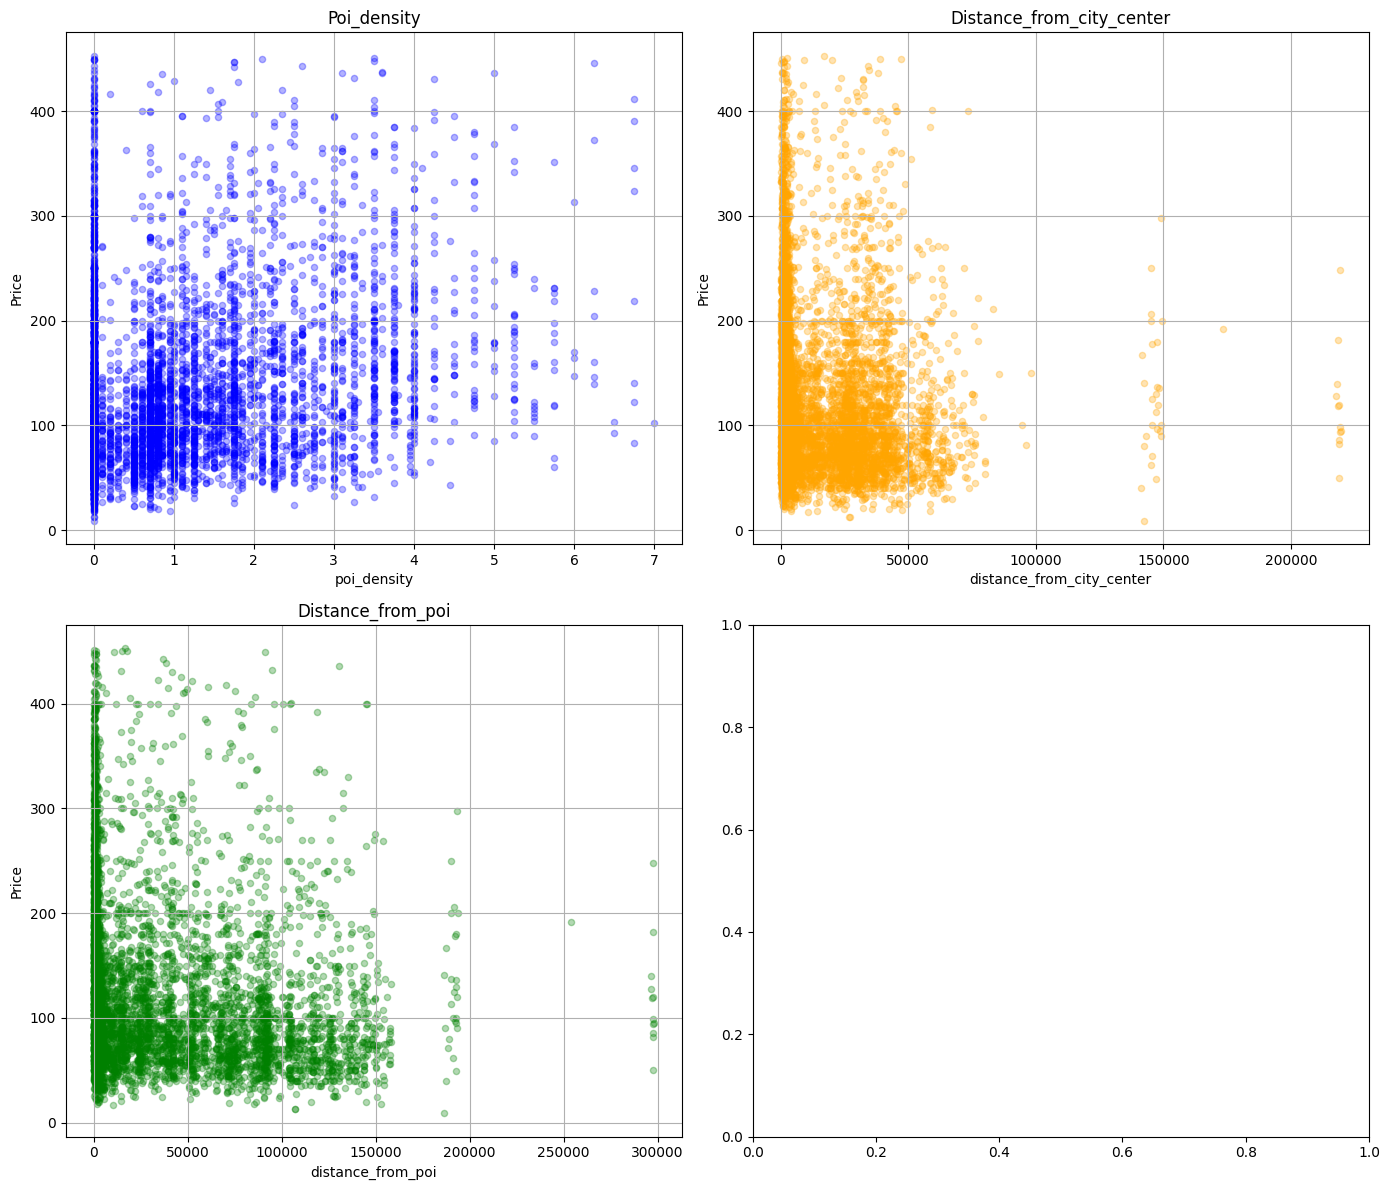

(<Figure size 1400x1200 with 4 Axes>,
 array([<Axes: title={'center': 'Poi_density'}, xlabel='poi_density', ylabel='Price'>,
        <Axes: title={'center': 'Distance_from_city_center'}, xlabel='distance_from_city_center', ylabel='Price'>,
        <Axes: title={'center': 'Distance_from_poi'}, xlabel='distance_from_poi', ylabel='Price'>,
        <Axes: >], dtype=object))

In [63]:
plot_price_vs_features(
    lst_for_price_analysis,
    cols=["poi_density", "distance_from_city_center", "distance_from_poi"],
    colors=["blue", "orange", "green"],
    sample_n=7000,
    figsize=(14, 12),
    logx=False,
    logy=False,
)

Tutte e tre le variabili non mostrano una relazione lineare molto forte con il prezzo. Possono però essere effettuate le seguenti osservazioni:

- `poi_density`: sembra esserci una relazione con il prezzo, all'aumentare della densità dei punti di interesse, anche se molto debole.
- `distance_from_city_center`: presenta un forte addensamento ridosso dello zero. I prezzi massimi si concentrano esclusivamente a ridosso del centro, mentre si schiacciano verso la fascia medio-bassa all'aumentare della distanza.
- `distance_from_poi`: ha una tendenza simile a quella della distanza dal centro. La forte concentrazione di punti sotto i 100 indica che la vicinanza ai punti di interesse è una condizione necessaria ma non sufficiente per giustificare prezzi elevati.

Proviamo come ultima cosa a creare dei geocluster per identificare delle aree geografiche omogenee in cui si trovano gli alloggi, in modo da avere una nuova variabile categorica che rappresenta l'area geografica. Per fare ciò, è possibile utilizzare l'algoritmo di clustering K-means, che è un algoritmo di clustering non supervisionato che suddivide i dati in K cluster basandosi sulla distanza tra i punti.

Creiamo quindi 15 cluster per ogni città e creiamo due nuove variabili:
- `geo_cluster`: rappresenta il cluster a cui appartiene ogni alloggio.
- `distance_from_geo_cluster`: rappresenta la distanza di ogni alloggio dal centro del suo cluster geo.

In [64]:
from sklearn.cluster import KMeans

n_clusters_per_city = 15
min_listings_for_clustering = 50

lst_for_price_analysis['geo_cluster'] = -1

for city, group in lst_for_price_analysis.groupby('city'):
    mask = lst_for_price_analysis['city'] == city
    n_listings = len(group)

    if n_listings < min_listings_for_clustering:
        lst_for_price_analysis.loc[mask, 'geo_cluster'] = 0
        continue

    coords = group[['latitude', 'longitude']].values
    kmeans = KMeans(n_clusters=n_clusters_per_city, random_state=SEED, n_init=10)
    cluster_labels = kmeans.fit_predict(coords)

    lst_for_price_analysis.loc[mask, 'geo_cluster'] = cluster_labels

    centers = kmeans.cluster_centers_
    distances = np.linalg.norm(
        coords - centers[cluster_labels],
        axis=1
    )
    lst_for_price_analysis.loc[mask, 'distance_from_geo_cluster'] = distances


c:\Users\cecca\miniconda3\envs\adi\Lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)
c:\Users\cecca\miniconda3\envs\adi\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
c:\Users\cecca\miniconda3\envs\adi\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when 

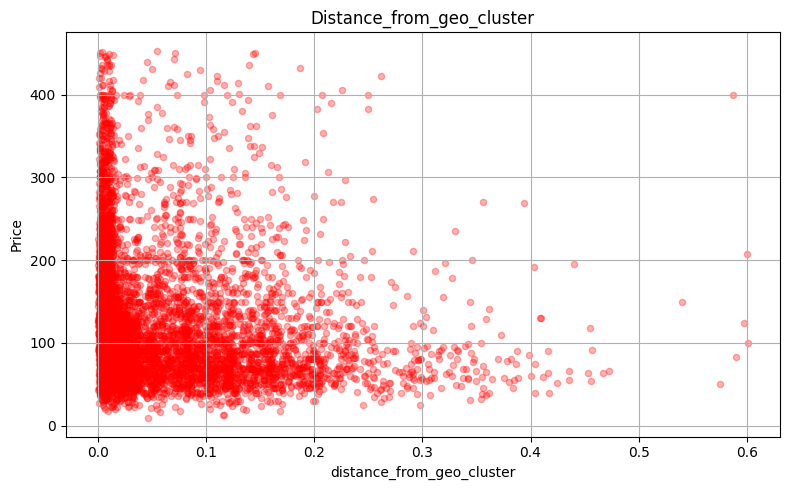

(<Figure size 800x500 with 1 Axes>,
 array([<Axes: title={'center': 'Distance_from_geo_cluster'}, xlabel='distance_from_geo_cluster', ylabel='Price'>],
       dtype=object))

In [65]:
plot_price_vs_features(
    lst_for_price_analysis,
    cols=["distance_from_geo_cluster"],
    colors=["red"],
    sample_n=7000,
    n_cols=1,
    figsize=(8, 5),
    logx=False,
    logy=False,
)

Il grafico presenta un grande addensamento verticale, come nei grafici precedenti, a ridosso dello zero, confermando che la quasi totalità dei listing si concentra all'interno o nelle immediate vicinanze dei cluster geografici individuati. I prezzi più elevati si riscontrano esclusivamente a distanze minime, mentre all'allontanarsi dal cluster la nuvola di punti si dirada nettamente e le tariffe tendono a schiacciarsi sotto i 200 euro.

#### 2.3.b - Occupancy Regression

Obiettivo: esplorare `estimated_occupancy_l365d` e le sue relazioni con le feature disponibili, escludendo le colonne che creerebbero leakage: `price`, `estimated_revenue_l365d`, tutte le colonne `availability_*` e le colonne `number_of_reviews*`.

Sottosezioni:

- **A**: Panoramica target (distribuzione, missingness, statistica descrittiva).
- **B**: Correlazioni numeriche — elenco feature più correlate (positive/negative) con il target.
- **C**: Scatter / regplot per le top feature correlate.
- **D**: Analisi categorica: boxplot di `estimated_occupancy_l365d` per `room_type` e per i top quartieri.
- **E**: Missingness per feature rilevanti.

Count non-null: 30000
Missing: 0


count    30000.000000
mean        53.702233
std         77.356348
min          0.000000
25%          0.000000
50%         12.000000
75%         72.000000
max        255.000000
Name: estimated_occupancy_l365d, dtype: float64

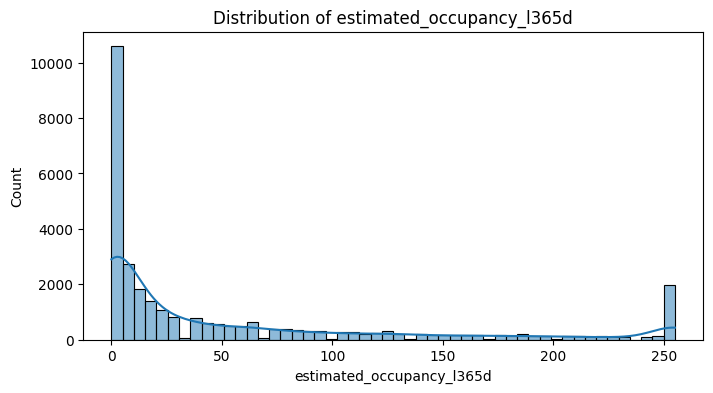

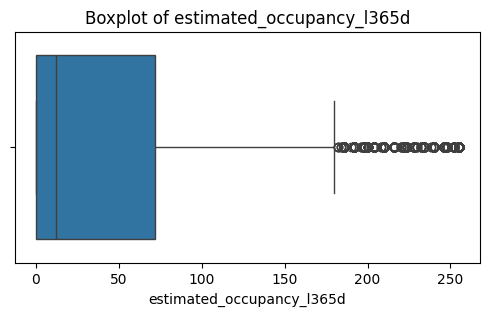

In [66]:
# A Target overview: `estimated_occupancy_l365d`
t = df['estimated_occupancy_l365d']
print('Count non-null:', t.count())
print('Missing:', t.isna().sum())
display(t.describe())
plt.figure(figsize=(8,4))
sns.histplot(t.dropna(), kde=True, bins=50)
plt.title('Distribution of estimated_occupancy_l365d')
plt.xlabel('estimated_occupancy_l365d')
plt.show()
plt.figure(figsize=(6,3))
sns.boxplot(x=t)
plt.title('Boxplot of estimated_occupancy_l365d')
plt.show()

### Come leggere i grafici

- Istogramma + KDE: mostra la forma della distribuzione (asimmetria, picchi, code).
- Boxplot: mette in evidenza mediana, IQR e outlier.
- Statistiche rapide: media, mediana, quartili, count e missing.

### Cosa emerge

- Distribuzione fortemente asimmetrica con massa vicino a 0 e lunga coda verso valori alti: molti annunci hanno poche prenotazioni mentre pochi sono molto popolari (hotel, appartamenti centrali).
- Mediana relativamente bassa: la maggioranza degli annunci presenta occupazione contenuta.
- Presenza di outlier (valori molto alti) che vanno verificati ma non sono necessariamente errori.
- Potrebbe essere utile considerare trasformazioni del target o modelli robusti se si cerca stabilità nelle previsioni.


In [67]:
# B Correlazioni con il target
exclude_prefixes = ['availability_', 'number_of_reviews']
exclude_exact = {'price', 'estimated_revenue_l365d'}
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
if 'estimated_occupancy_l365d' in num_cols:
    num_cols.remove('estimated_occupancy_l365d')
cols_for_corr = [c for c in num_cols if c not in exclude_exact and not any(c.startswith(p) for p in exclude_prefixes)]
print(f'Total numeric features considered for correlation: {len(cols_for_corr)}')
corr_with_target = df[cols_for_corr + ['estimated_occupancy_l365d']].corr()['estimated_occupancy_l365d'].drop('estimated_occupancy_l365d')
corr_sorted = corr_with_target.sort_values(ascending=False)
display(corr_sorted.head(20))
display(corr_sorted.tail(20))

Total numeric features considered for correlation: 47


reviews_per_month         0.766954
topic_0                   0.596115
review_length_max         0.456147
topic_3                   0.424482
vader_compound_std        0.406752
asp_location_mean         0.347386
pct_positive              0.340272
vader_compound_mean       0.321848
review_length_std         0.302596
asp_host_quality_mean     0.249190
review_span_days          0.230345
latitude                  0.227263
asp_cleanliness_mean      0.220406
asp_comfort_mean          0.214724
topic_4                   0.212415
review_word_count_mean    0.183427
review_length_mean        0.172604
review_scores_value       0.146571
review_scores_accuracy    0.143481
asp_accuracy_mean         0.139177
Name: estimated_occupancy_l365d, dtype: float64

asp_value_mean              0.066079
topic_2                     0.035945
topic_1                     0.009761
minimum_maximum_nights     -0.002210
maximum_maximum_nights     -0.002211
maximum_nights_avg_ntm     -0.002212
maximum_minimum_nights     -0.045164
bathrooms                  -0.047850
bedrooms                   -0.074245
accommodates               -0.076425
beds                       -0.082537
maximum_nights             -0.085259
minimum_nights             -0.086777
minimum_nights_avg_ntm     -0.100368
id                         -0.106952
minimum_minimum_nights     -0.118126
avg_days_between_reviews   -0.162327
days_since_last_review     -0.239314
longitude                  -0.254769
vader_compound_min         -0.551456
Name: estimated_occupancy_l365d, dtype: float64

### Come leggere

- La tabella ordina le feature per correlazione con `estimated_occupancy_l365d` (dal più positivo al più negativo).
- Guardare sia il segno (positivo/negativo) sia la magnitudo: le feature con valore assoluto più alto sono le più rilevanti.
- Sono state escluse le colonne di possibile leakage: `price`, `estimated_revenue_l365d`, `availability_*` e `number_of_reviews*`.

### Cosa emerge

- Le metriche di recensione (es. `reviews_per_month`, `review_scores_*`) mostrano le associazioni più evidenti.
- Gli effetti osservati sono generalmente moderati: le correlazioni non sono enormi e possono essere influenzate da confondenti o da differenze fra città.
- Usare queste indicazioni per selezionare le candidate feature da approfondire con scatterplot e analisi stratificate.


Top features by absolute correlation: ['reviews_per_month', 'topic_0', 'vader_compound_min', 'review_length_max', 'topic_3']


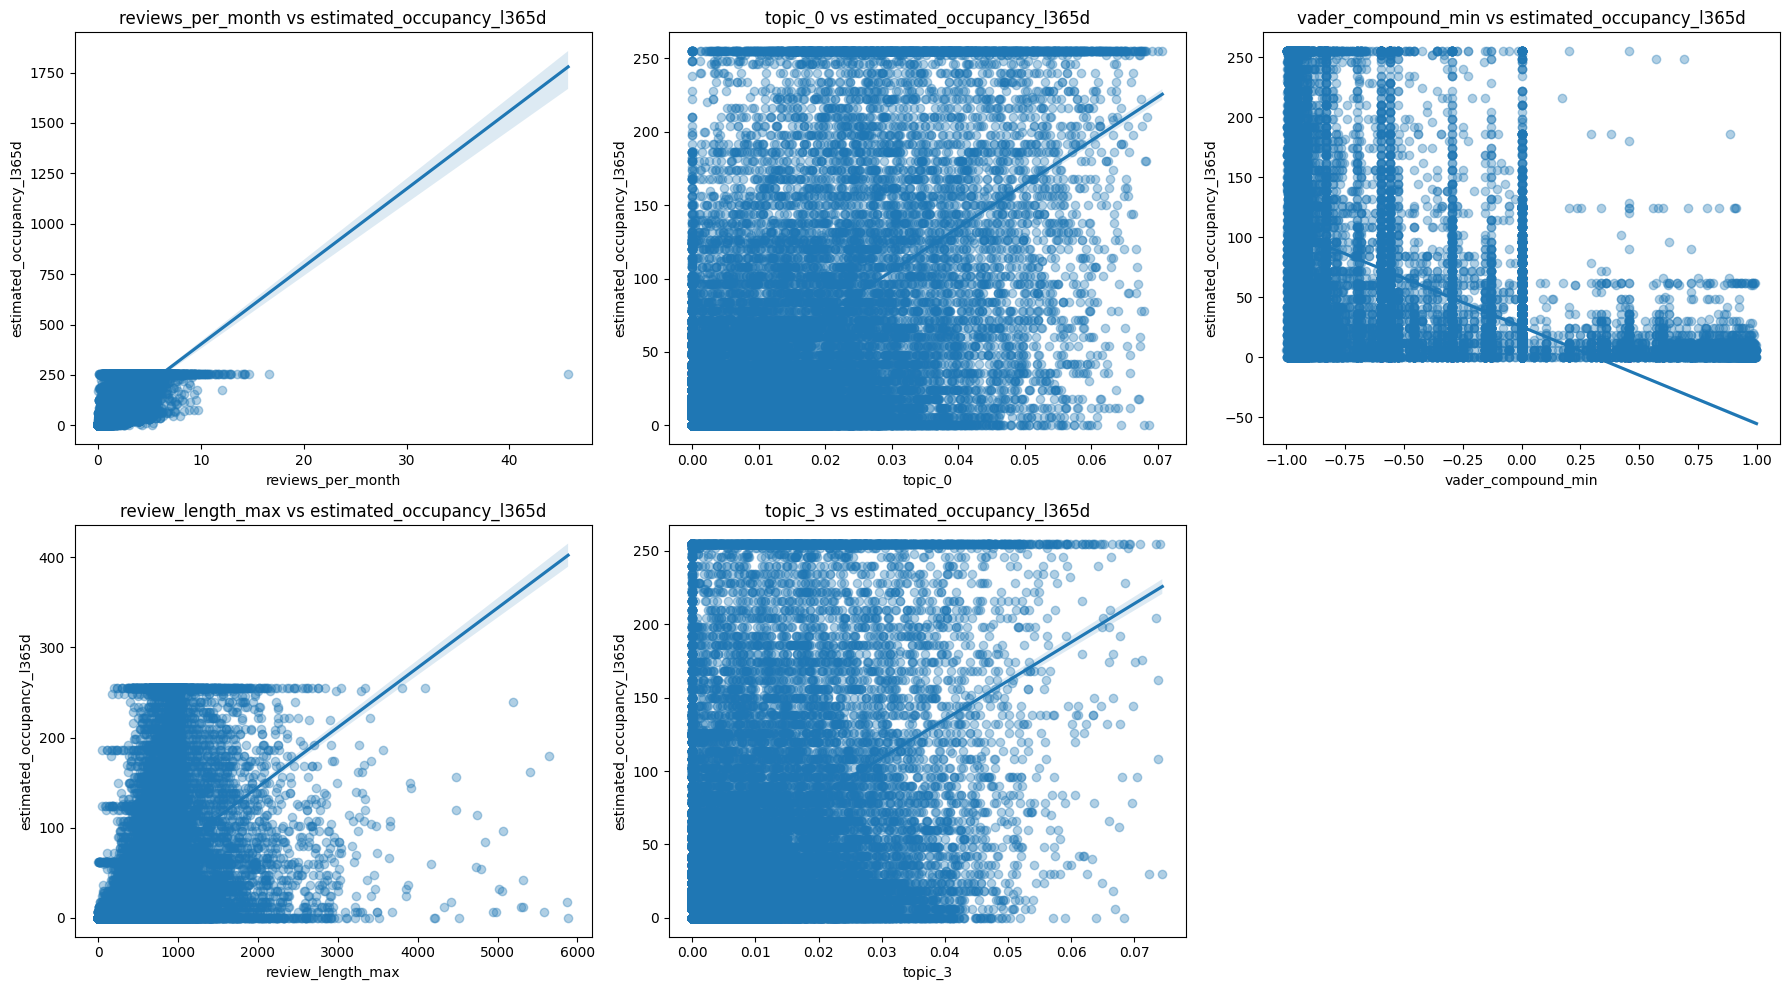

In [68]:
# C Scatter / regplot per le top feature correlate
corr_vals = corr_with_target.abs().sort_values(ascending=False)
top_feats = corr_vals.head(5).index.tolist()
print('Top features by absolute correlation:', top_feats)

n_cols = 3
n_rows = 2
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 10))
axes = axes.ravel()

for ax, f in zip(axes, top_feats):
    sns.regplot(x=df[f], y=df['estimated_occupancy_l365d'], scatter_kws={'alpha':0.35}, ax=ax)
    ax.set_title(f'{f} vs estimated_occupancy_l365d')
    ax.set_xlabel(f)
    ax.set_ylabel('estimated_occupancy_l365d')

for ax in axes[len(top_feats):]:
    ax.axis('off')

plt.tight_layout()
plt.show()

### Come leggere gli scatter/regplot

- Ogni grafico mostra la relazione tra una feature numerica e `estimated_occupancy_l365d`.
- I punti sparsi danno l'idea della variabilità reale dei dati, mentre la linea di regressione aiuta a capire se il legame è crescente, decrescente o quasi assente.
- Se la nuvola di punti è molto larga e la linea è quasi orizzontale, la feature è poco informativa da sola.
- La vista a scacchiera rende più facile confrontare i grafici e vedere subito quali relazioni sembrano più stabili.

### Cosa emerge

- Le feature più interessanti sono `reviews_per_month`, `latitude`, `longitude`, `review_scores_value` e `review_scores_accuracy`, ma il segnale non è sempre pulito.
- `reviews_per_month` sembra la più informativa, anche se la relazione è influenzata da alcuni valori molto estremi e da una forte concentrazione di punti nei valori bassi.
- Le variabili geografiche vanno lette con cautela: il dataset è aggregato per città, quindi `latitude` e `longitude` riflettono anche differenze tra mercati diversi.
- In generale, questi grafici servono soprattutto a individuare feature promettenti e a capire la forma della relazione, non a dire che una variabile è forte in senso assoluto.

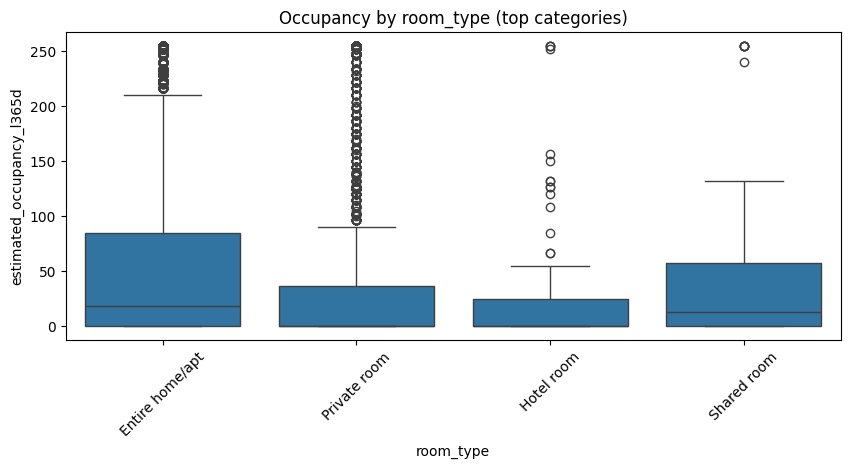

Plotting neighbourhoods with >= 10 listings (344 neighbourhoods).


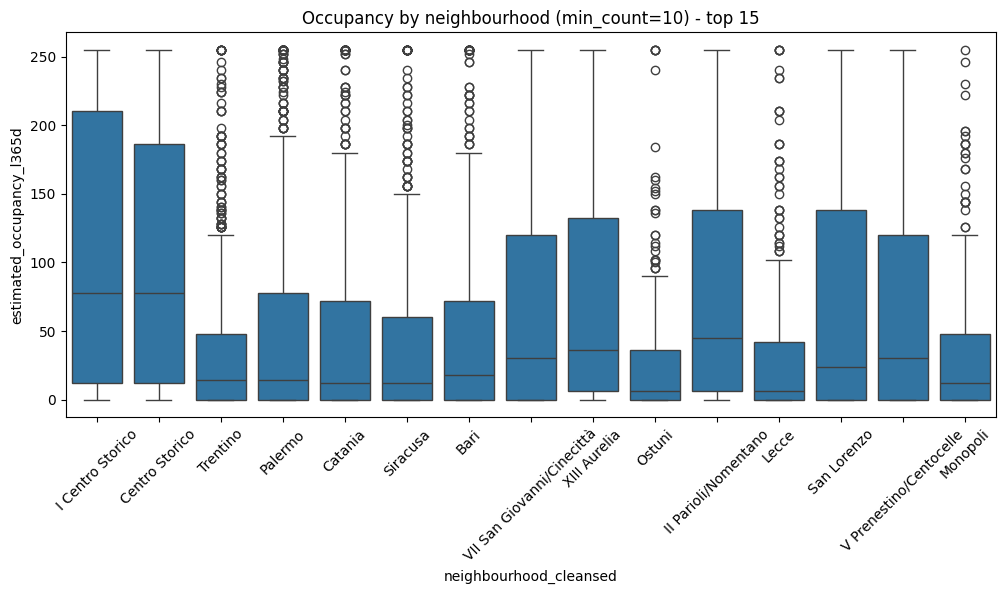

neighbourhood_cleansed
I Centro Storico              2500
Centro Storico                1351
Trentino                      1155
Palermo                       1083
Catania                        661
Siracusa                       554
Bari                           536
VII San Giovanni/Cinecittà     397
XIII Aurelia                   385
Ostuni                         385
II Parioli/Nomentano           348
Lecce                          329
San Lorenzo                    292
V Prenestino/Centocelle        289
Monopoli                       276
Gallipoli                      276
Noto                           272
Porto Cesareo                  258
Castellammare del Golfo        258
Castello                       249
Cannaregio                     243
XII Monte Verde                236
BUENOS AIRES - VENEZIA         233
Porto - Saragozza              228
Ragusa                         218
Santo Stefano                  215
DUOMO                          211
Bergamo                        2

In [69]:
# D Analisi categorica (semplificata): room_type + neighbourhoods filtrati
min_count = 10

# Boxplot per `room_type`
plt.figure(figsize=(10,4))
order = df['room_type'].value_counts().index
sns.boxplot(x='room_type', y='estimated_occupancy_l365d', data=df, order=order)
plt.xticks(rotation=45)
plt.title('Occupancy by room_type (top categories)')
plt.show()

# Boxplot per `neighbourhood_cleansed` ma escludendo quartieri con pochi listing
counts = df['neighbourhood_cleansed'].value_counts()
good_neigh = counts[counts >= min_count].index
print(f'Plotting neighbourhoods with >= {min_count} listings ({len(good_neigh)} neighbourhoods).')
top_to_plot = counts.loc[good_neigh].sort_values(ascending=False).head(15).index
if len(top_to_plot) > 0:
    plt.figure(figsize=(12,5))
    sns.boxplot(x='neighbourhood_cleansed', y='estimated_occupancy_l365d',
                data=df[df['neighbourhood_cleansed'].isin(top_to_plot)],
                order=top_to_plot)
    plt.xticks(rotation=45)
    plt.title(f'Occupancy by neighbourhood (min_count={min_count}) - top {len(top_to_plot)}')
    plt.show()

counts = df['neighbourhood_cleansed'].value_counts()
filtered = counts[counts >= min_count].sort_values(ascending=False)
print(filtered.to_string())

### Come leggere i boxplot

- Ogni boxplot confronta la distribuzione di `estimated_occupancy_l365d` tra le categorie (es. `room_type` o `neighbourhood_cleansed`).
- La linea centrale è la mediana; il box mostra l'IQR (50% centrale). Baffi e punti fuori indicano variabilità e outlier.
- Attenzione alle categorie con pochi annunci: medie elevate possono dipendere da pochi valori estremi.
- In questa versione abbiamo applicato un filtro di supporto: vengono plottati solo i quartieri con almeno `min_count` listing (default 10). Controllare sempre il valore di `min_count` usato nella cella di codice.
- Controllare sempre la frequenza (count) per categoria insieme alla mediana prima di trarre conclusioni.

### Cosa emerge

- Alcuni quartieri presentano medie molto alte (es. Lenna, Pra' Secco, Ca' Brentelle): prima di considerare questi risultati, verificare il conteggio di listing per quei quartieri — se il conteggio è basso, la mediana o la media può essere fuorviante.
- `room_type` mostra differenze pratiche: intere case tendono ad avere mediane e variabilità maggiori rispetto a stanze condivise o private.
- Il filtro `min_count` riduce l'impatto dei quartieri con supporto scarso, rendendo le comparazioni più robuste; tuttavia potrebbe escludere nicchie reali se `min_count` è troppo alto.
- Questi grafici servono a individuare categorie e quartieri da approfondire con analisi stratificate o con filtri per numero di osservazioni; usare la stampa dei conteggi (ordinata per frequenza) per ispezionare i quartieri esclusi.


Missingness percentage for relevant numeric features:


review_scores_value            0.205033
review_scores_location         0.205000
review_scores_rating           0.204933
reviews_per_month              0.204933
review_scores_cleanliness      0.204933
review_scores_accuracy         0.204933
review_scores_checkin          0.204933
review_scores_communication    0.204933
bedrooms                       0.001200
beds                           0.000633
bathrooms                      0.000533
maximum_minimum_nights         0.000333
minimum_minimum_nights         0.000333
minimum_maximum_nights         0.000333
maximum_maximum_nights         0.000333
minimum_nights                 0.000000
maximum_nights_avg_ntm         0.000000
minimum_nights_avg_ntm         0.000000
maximum_nights                 0.000000
id                             0.000000
dtype: float64

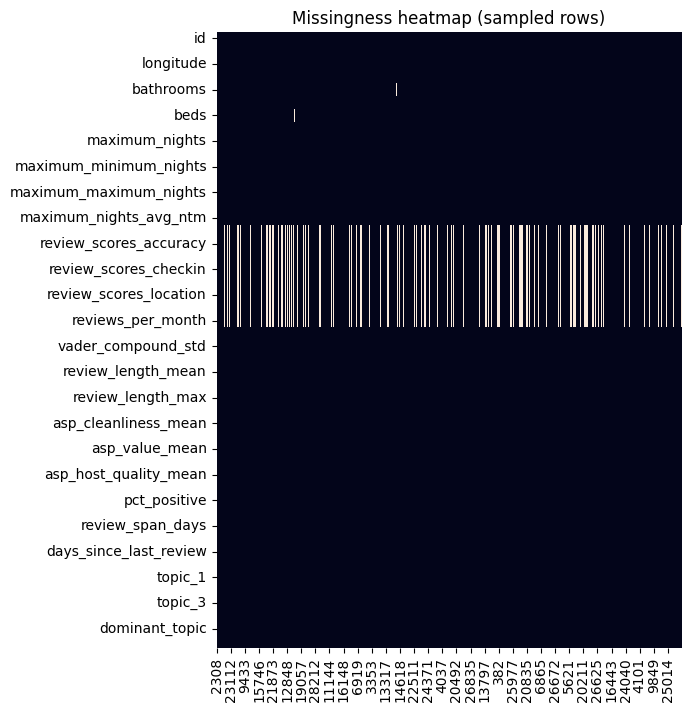

In [70]:
# E Missingness summary per feature rilevanti
relevant = cols_for_corr.copy() if 'cols_for_corr' in globals() else []
relevant += ['estimated_occupancy_l365d'] if 'estimated_occupancy_l365d' in df.columns else []
miss_pct = df[relevant].isna().mean().sort_values(ascending=False)
print('Missingness percentage for relevant numeric features:')
display(miss_pct.head(20))
plt.figure(figsize=(6,8))
sns.heatmap(df[relevant].isna().astype(int).sample(frac=0.2, random_state=42).T, cbar=False)
plt.title('Missingness heatmap (sampled rows)')
plt.show()

### Come leggere la missingness

- La tabella mostra la percentuale di valori mancanti per ciascuna feature: valori più alti indicano meno osservazioni utili per quella colonna.
- La heatmap campionata visualizza la struttura dei missing (colonne = variabili, righe = campione di record): strisce verticali indicano missing sparsi, blocchi orizzontali indicano assenze sistematiche su gruppi di righe.
- Confrontare sempre missingness e target: se il target è completo, le feature mancanti possono essere imputate o segnalate con indicatori di missing.
- Prestare attenzione a variabili derivate da recensioni (`review_scores_*`, `reviews_per_month`): spesso hanno missing non casuale (dipendono dall'assenza di recensioni).

### Cosa emerge

- Le feature legate alle recensioni mostrano missing non trascurabile: considerare imputazione (mediana) o l'uso di una variabile indicator per missingness.
- La heatmap suggerisce pattern sparsi piuttosto che blocchi grandi: i missing tendono a essere associati a singoli annunci, non a interi sottogruppi (ma verificare stratificando per città/quartiere).
- Regole pratiche consigliate: valutare l'eliminazione di colonne con percentuale di missing molto alta (es. >50%), oppure imputare con strategie stratificate; testare modelli con/senza le colonne imputate.
- Se i missing sono correlati a feature geografiche o categorie, preferire imputazione stratificata per evitare bias.


In [71]:
# F Caricamento dei dati di calendar precedentemente processati
calendar_dfs = []

for sub in os.listdir("./data"):
    subpath = os.path.join("./data", sub)
    if not os.path.isdir(subpath):
        continue

    csv_path = os.path.join(subpath, "calendar.csv")

    if os.path.exists(csv_path):
        city_df = pd.read_csv(csv_path)
        calendar_dfs.append(city_df)
    else:
        for root, _, files in os.walk(subpath):
            if "calendar.csv" in files:
                city_df = pd.read_csv(os.path.join(root, "calendar.csv"))
                calendar_dfs.append(city_df)
                break

if calendar_dfs:
    calendars = pd.concat(calendar_dfs, ignore_index=True)
else:
    calendars = pd.DataFrame()

calendars.count()

listing_id                193940
occ_days_01               193940
occ_days_02               193940
occ_days_03               193940
occ_days_04               193940
occ_days_05               193939
occ_days_06               193938
occ_days_07               193938
occ_days_08               193938
occ_days_09               193940
occ_days_10               193940
occ_days_11               193940
occ_days_12               193940
occupancy_rate_01         193940
occupancy_rate_02         193940
occupancy_rate_03         193940
occupancy_rate_04         193940
occupancy_rate_05         193939
occupancy_rate_06         193938
occupancy_rate_07         193938
occupancy_rate_08         193938
occupancy_rate_09         193940
occupancy_rate_10         193940
occupancy_rate_11         193940
occupancy_rate_12         193940
total_occ_days            193940
total_observed_days       193940
monthly_occupancy_mean    193940
occupancy_rate            193940
dtype: int64

Sezione di esplorazione dei dati di `calendar`: controlliamo dimensioni, intervallo temporale, distribuzione delle variabili di occupazione e qualche statistica base sui campi più utili per il Task B.  
L'obiettivo è avere un primo quadro della disponibilità giornaliera e del tasso di occupazione osservato, senza entrare ancora nel preprocessing vero e proprio.

In [72]:
print('Shape:', calendars.shape)
display(calendars.head(1))

if 'date' in calendars.columns:
    calendars['date'] = pd.to_datetime(calendars['date'], errors='coerce')
    print('Date range:', calendars['date'].min(), '->', calendars['date'].max())

numeric_cols = [c for c in ['occ_days_01', 'occ_days_02', 'occ_days_03', 'occ_days_04', 'occ_days_05', 'occ_days_06', 'occ_days_07', 'occ_days_08', 'occ_days_09', 'occ_days_10', 'occ_days_11', 'occ_days_12', 'occupancy_rate_01', 'occupancy_rate_02', 'occupancy_rate_03', 'occupancy_rate_04', 'occupancy_rate_05', 'occupancy_rate_06', 'occupancy_rate_07', 'occupancy_rate_08', 'occupancy_rate_09', 'occupancy_rate_10', 'occupancy_rate_11', 'occupancy_rate_12', 'total_occ_days', 'total_observed_days', 'monthly_occupancy_mean', 'occupancy_rate'] if c in calendars.columns]

if numeric_cols:
    display(calendars[numeric_cols].describe().T)

Shape: (193940, 29)


,listing_id,occ_days_01,occ_days_02,occ_days_03,occ_days_04,occ_days_05,occ_days_06,occ_days_07,occ_days_08,occ_days_09,...,occupancy_rate_07,occupancy_rate_08,occupancy_rate_09,occupancy_rate_10,occupancy_rate_11,occupancy_rate_12,total_occ_days,total_observed_days,monthly_occupancy_mean,occupancy_rate
0,1000469206969420955,31.0,0.0,31.0,30.0,31.0,30.0,31.0,31.0,30.0,...,1.0,1.0,1.0,0.612903,0.266667,0.225806,279,365,0.758781,0.764384


,count,mean,std,min,25%,50%,75%,max
occ_days_01,193940.0,11.110199,13.965683,0.0,0.000000,1.000000,31.000000,31.0
occ_days_02,193940.0,10.315531,12.939099,0.0,0.000000,0.000000,28.000000,28.0
occ_days_03,193940.0,11.449031,14.247863,0.0,0.000000,0.000000,31.000000,31.0
occ_days_04,193940.0,12.068903,14.192016,0.0,0.000000,0.000000,30.000000,30.0
occ_days_05,193939.0,12.402859,14.673874,0.0,0.000000,0.000000,31.000000,31.0
occ_days_06,193938.0,12.710469,13.913059,0.0,0.000000,4.000000,30.000000,30.0
occ_days_07,193938.0,15.330307,15.149499,0.0,0.000000,9.000000,31.000000,31.0
occ_days_08,193938.0,15.613861,15.237430,0.0,0.000000,15.000000,31.000000,31.0
occ_days_09,193940.0,16.466026,12.635894,0.0,1.000000,16.000000,30.000000,32.0
occ_days_10,193940.0,15.498123,11.697407,0.0,3.000000,16.000000,27.000000,31.0


**Correlazione tra le metriche di occupazione:**

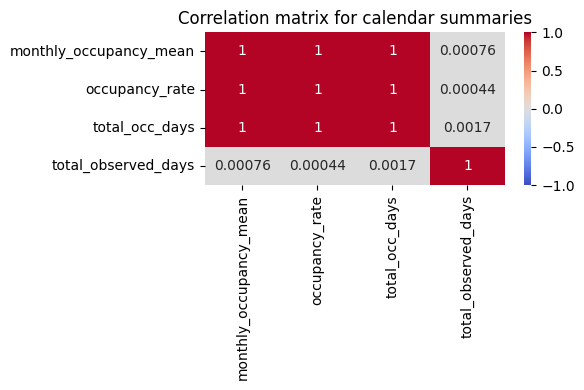

In [73]:
summary_cols = [c for c in ['monthly_occupancy_mean', 'occupancy_rate', 'total_occ_days', 'total_observed_days'] if c in calendars.columns]
if summary_cols:
    corr_calendar = calendars[summary_cols].corr()
    plt.figure(figsize=(6, 4))
    sns.heatmap(corr_calendar, annot=True, cmap='coolwarm', center=0, vmin=-1, vmax=1)
    plt.title('Correlation matrix for calendar summaries')
    plt.tight_layout()
    plt.show()

**Confronto Occupancy rate nei vari mesi**

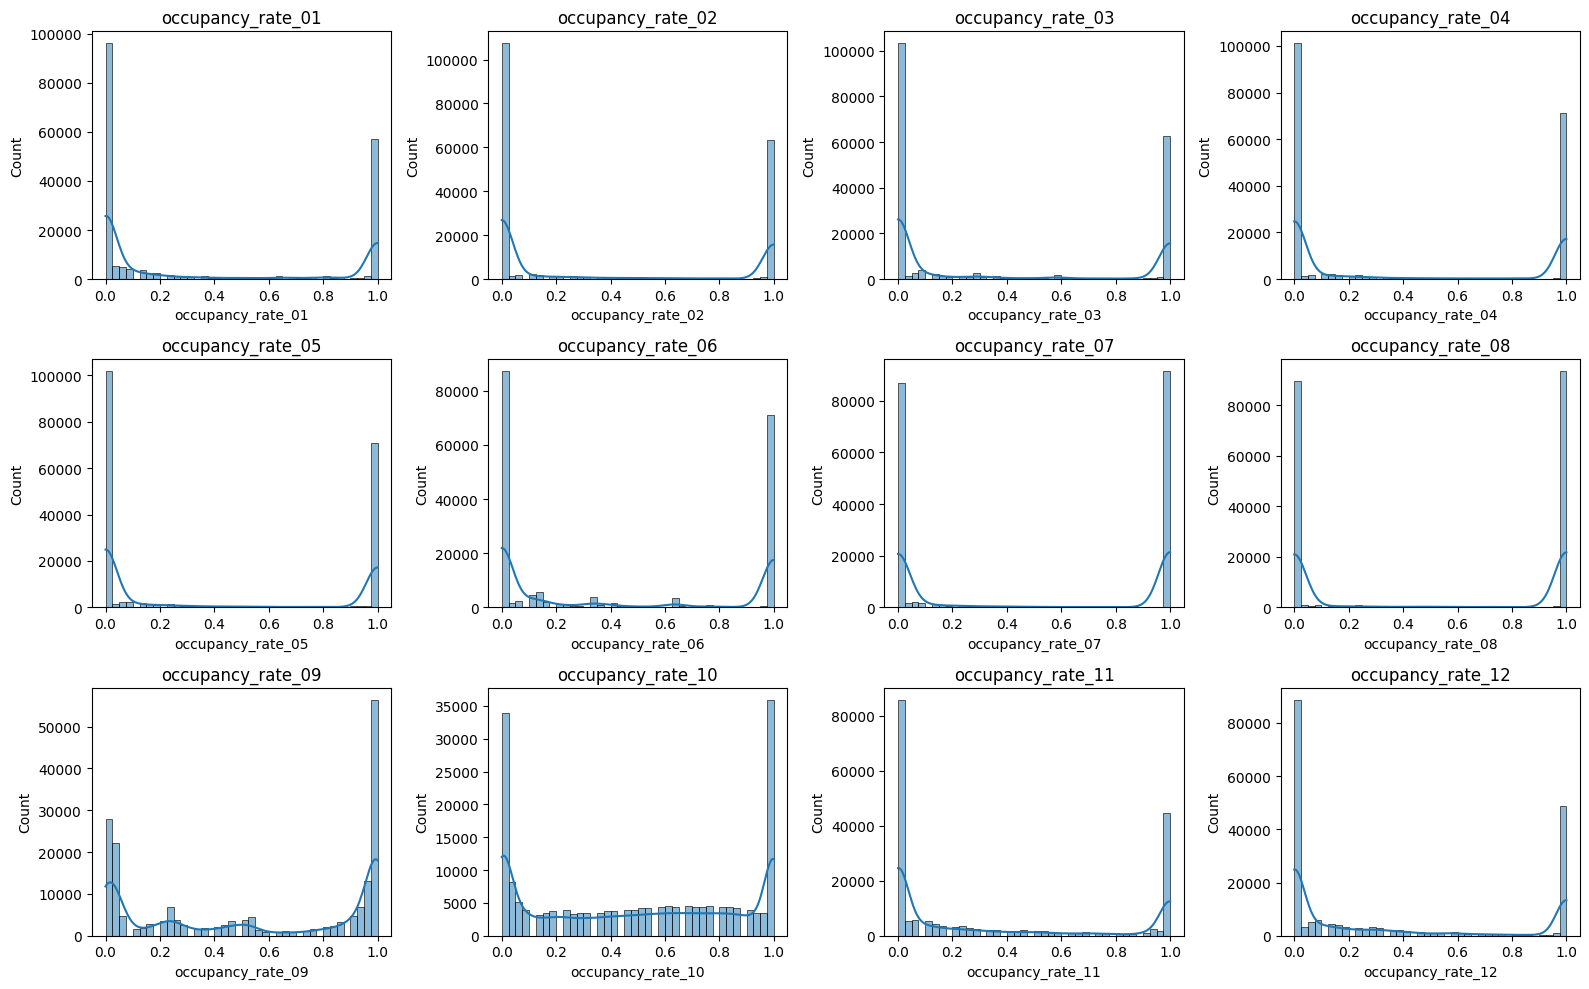

In [74]:
rate_cols = [c for c in calendars.columns if c.startswith('occupancy_rate_')]
if rate_cols:
    fig, axes = plt.subplots(3, 4, figsize=(16, 10))
    axes = axes.ravel()
    for ax, col in zip(axes, rate_cols):
        sns.histplot(calendars[col].dropna(), bins=40, kde=True, ax=ax)
        ax.set_title(col)
    plt.tight_layout()
    plt.show()

Dall'esplorazione minima emergono alcuni punti utili per il Task B:
- `calendar` contiene 193940 righe e 29 colonne, quindi il dataset è già abbastanza ricco da solo.
- Le distribuzioni di `occupancy_rate_01`, `occupancy_rate_02` e `occupancy_rate_03` sono fortemente bimodali, con molta massa vicino a 0 e a 1: questo suggerisce che molti annunci sono quasi sempre liberi o quasi sempre occupati nei mesi osservati.
- I valori osservati nei giorni mensili variano poco attorno al totale atteso, quindi il dato calendar sembra stabile a livello di copertura temporale.
- In ottica modellistica, `monthly_occupancy_mean`, `occupancy_rate` e `total_occ_days` sembrano le variabili calendar più promettenti da confrontare con il target `estimated_occupancy_l365d`.

### 2.4 Pipeline di Review Intelligence (Estrazione delle Caratteristiche)

Questa sezione implementa la **Pipeline di Review Intelligence** per estrarre caratteristiche strutturate e predittive dal testo delle recensioni degli ospiti (`reviews.csv`) per tutte le città target.

I segnali estratti includono:
- **Sentiment VADER**: `sentiment_mean`, `sentiment_std`, `sentiment_min`, `pct_positive`, `pct_negative`.
- **Lessici di Dominio (Aspetti)**: pulizia, posizione, rapporto qualità-prezzo, comfort, qualità dell’host, accuratezza.
- **Segnali temporali**: periodo di attività, intervalli medi, trend del sentiment, recenza, accelerazione.
- **Metadati**: lunghezza media delle recensioni, deviazione standard, conteggio delle parole.
- **Topic Modeling NMF**: distribuzioni dei topic (`topic_0` fino a `topic_4`) e `dominant_topic`.

In [75]:
import os
import re
import numpy as np
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import NMF
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

# Lexicon mappings for Aspect Extraction
ASPECTS = {
    "cleanliness":  ["clean", "dirty", "spotless", "tidy", "dust", "stain", "hygienic", "smell", "mold", "filthy", "immaculate"],
    "location":     ["location", "central", "metro", "station", "walk", "close", "far", "noisy", "quiet", "neighborhood", "convenient", "transport", "bus", "tram"],
    "value":        ["value", "price", "expensive", "cheap", "worth", "overpriced", "bargain", "money", "affordable"],
    "comfort":      ["comfortable", "cozy", "spacious", "cramped", "bed", "mattress", "pillow", "sleep", "noise", "thin walls"],
    "host_quality": ["host", "responsive", "helpful", "kind", "welcoming", "rude", "communication", "attentive", "friendly", "flexible", "accommodating"],
    "accuracy":     ["accurate", "photos", "description", "misleading", "exactly", "as described", "different", "expectation"]
}

# Multilingual Stopwords to force semantic (rather than language-based) topics
ITALIAN_STOPS = {
    "il", "lo", "la", "le", "gli", "un", "una", "di", "da", "in",
    "con", "su", "per", "tra", "fra", "che", "non", "è", "sono",
    "molto", "tutto", "questa", "questo", "anche", "più", "ma"
}
GERMAN_STOPS = {
    "der", "die", "das", "und", "ist", "in", "zu", "den", "von", "mit", 
    "auf", "für", "was", "waren", "war", "wir", "es", "ein", "eine", "sich", 
    "dem", "dass", "er", "sie", "uns", "aus", "an", "bei", "noch", "nur", "oder", "sehr"
}
FRENCH_STOPS = {
    "le", "la", "les", "et", "en", "de", "dans", "une", "un", "est", 
    "pour", "nous", "vous", "avec", "tout", "plus", "sur", "très", "était", "qui", "aux"
}
SPANISH_STOPS = {
    "el", "la", "los", "las", "y", "en", "de", "un", "una", "es", 
    "para", "con", "por", "lo", "nos", "se", "al", "del", "que", "muy", "todo", "como"
}
COMBINED_STOPS = list(ENGLISH_STOP_WORDS | ITALIAN_STOPS | GERMAN_STOPS | FRENCH_STOPS | SPANISH_STOPS)
COMBINED_STOPS.append("br")

# Text cleaning function: removes HTML residues and isolated 'br' words
def clean_review_text(text):
    if pd.isna(text):
        return ""
    text = str(text).lower()
    text = re.sub(r'<br\s*/?>', ' ', text)  # Replace HTML breaks
    text = re.sub(r'[^a-záàéèíìóòúùñüäöß\s]', ' ', text)
    text = re.sub(r'\bbr\b', ' ', text)      # Remove isolated 'br'
    return re.sub(r'\s+', ' ', text).strip()


# Aggressive multilingual domain stopwords to avoid language segregation in NMF topics
EXTENDED_STOPS = {
    # Italian generic stay/room nouns and common verbs
    "appartamento", "casa", "alloggio", "stato", "siamo", "abbiamo", "ha", "ci", 
    "posizione", "disponibile", "camera", "ottima", "bello", "soggiorno",
    # French generic stay/room nouns and common verbs
    "appartement", "logement", "séjour", "propre", "situé", "metro", "avons", 
    "chambre", "bien", "très", "loger",
    # German generic stay/room nouns and common verbs
    "wohnung", "unterkunft", "sauber", "super", "nicht", "gut", "auch", "haben", 
    "alles", "hat", "man", "sch", "zimmer", "tolle", "gerne", "wieder",
    # English generic stay/room nouns and common verbs
    "apartment", "stay", "nice", "good", "great", "perfect", "place", "host", 
    "recommend", "clean", "room", "house", "lovely", "amazing"
}
COMBINED_STOPS = list(set(COMBINED_STOPS) | EXTENDED_STOPS)

print("Task D Setup complete. Combined stops count:", len(COMBINED_STOPS))


Task D Setup complete. Combined stops count: 455


In [76]:
# Loop and extract structured features per city to preserve memory and handle the ~2.5 GB dataset
city_features = []
listing_texts = {}
analyzer = SentimentIntensityAnalyzer()
MAX_REVIEWS_PER_LISTING = 200  # For scaling performance, sample up to 200 recent reviews per listing

for sub in os.listdir("./data"):
    subpath = os.path.join("./data", sub)
    if not os.path.isdir(subpath):
        continue

    csv_path = os.path.join(subpath, "reviews.csv")
    if not os.path.exists(csv_path):
        # Check subdirectories as well
        for root, _, files in os.walk(subpath):
            if "reviews.csv" in files:
                csv_path = os.path.join(root, "reviews.csv")
                break

    if os.path.exists(csv_path):
        print(f"Processing reviews for city: {sub}...")
        
        # Load reviews dynamically with only required columns
        df = pd.read_csv(csv_path, usecols=["listing_id", "comments", "date"])
        df = df.dropna(subset=["comments"])
        df["date"] = pd.to_datetime(df["date"], errors="coerce")
        df = df.dropna(subset=["date"])
        
        # Sort reviews chronologically per listing and cap them to recent ones to optimize performance
        df = df.sort_values(["listing_id", "date"], ascending=[True, False])
        df = df.groupby("listing_id").head(MAX_REVIEWS_PER_LISTING).copy()
        
        # Apply text cleaning
        df["comments_clean"] = df["comments"].apply(clean_review_text)
        
        # VADER Sentiment Analysis
        scores = [analyzer.polarity_scores(c) for c in df["comments_clean"].tolist()]
        df["vader_compound"] = [s["compound"] for s in scores]
        df["vader_neg"] = [s["neg"] for s in scores]
        
        # Aspect keyword counts (optimized using vectorized C-level regex engines)
        for aspect, keywords in ASPECTS.items():
            pattern = r'\b(' + '|'.join(keywords) + r')\b'
            df[f"asp_{aspect}"] = df["comments_clean"].str.count(pattern).fillna(0)
            
        # Text Metadata
        df["review_length"] = df["comments"].str.len().fillna(0)
        df["review_word_count"] = df["comments"].str.split().str.len().fillna(0)
        
        # Store concatenated text per listing for NMF Topic Modeling
        for lid, group in df.groupby("listing_id"):
            all_text = " ".join(group["comments_clean"].tolist())
            listing_texts[lid] = listing_texts.get(lid, "") + " " + all_text
            
        # Fast Groupby Aggregations
        aggregations = {
            "vader_compound": ["mean", "std", "min"],
            "review_length": ["mean", "std", "max"],
            "review_word_count": ["mean"]
        }
        for aspect in ASPECTS:
            aggregations[f"asp_{aspect}"] = ["mean"]
            
        agg_df = df.groupby("listing_id").agg(aggregations)
        # Flatten multi-level columns
        agg_df.columns = [f"{col[0]}_{col[1]}" for col in agg_df.columns]
        
        # Calculate ratio of positive/negative reviews
        pct_df = df.groupby("listing_id")["vader_compound"].agg(
            pct_positive=lambda x: (x > 0.05).mean(),
            pct_negative=lambda x: (x < -0.05).mean()
        )
        
        # Vectorized Temporal Signals
        temp_agg = df.groupby("listing_id")["date"].agg(["min", "max", "count"])
        temp_agg["review_span_days"] = (temp_agg["max"] - temp_agg["min"]).dt.days
        temp_agg["avg_days_between_reviews"] = temp_agg["review_span_days"] / (temp_agg["count"] - 1 + 1e-9)
        
        # Days since last review (relative to scrape date 2025-09-22)
        temp_agg["days_since_last_review"] = (pd.Timestamp("2025-09-22") - temp_agg["max"]).dt.days
        
        # Join all aggregated features for the city
        city_agg = agg_df.join(pct_df).join(temp_agg[["review_span_days", "avg_days_between_reviews", "days_since_last_review"]])
        city_features.append(city_agg)

# Concatenate listing-level features across all processed cities
if city_features:
    consolidated_df = pd.concat(city_features, axis=0)
    # Handle duplicated listings across different city downloads if any
    consolidated_df = consolidated_df.groupby(level=0).mean()
    print("Aggregated reviews shape:", consolidated_df.shape)
else:
    consolidated_df = pd.DataFrame()
    print("No reviews processed.")

No reviews processed.


In [77]:
# Phase 3: TF-IDF and NMF Topic Modeling across all listings
if not consolidated_df.empty and listing_texts:
    print("Fitting TF-IDF and NMF Topic Modeling...")
    
    # Filter listing_texts to only include listings present in consolidated_df
    active_lids = consolidated_df.index.tolist()
    active_texts = [listing_texts.get(lid, "") for lid in active_lids]
    
    # Fit TF-IDF Vectorizer (increased min_df to 20 to decrease sparsity)
    tfidf = TfidfVectorizer(max_features=5000, stop_words=COMBINED_STOPS, ngram_range=(1, 2), min_df=20)
    tfidf_matrix = tfidf.fit_transform(active_texts)
    
    # Fit NMF Topic Modeling using mathematically stable nndsvda initialization to avoid overflow/underflow warnings
    N_TOPICS = 5
    nmf = NMF(n_components=N_TOPICS, random_state=42, max_iter=300, init="nndsvda")
    topic_matrix = nmf.fit_transform(tfidf_matrix)
    
    # Topic Dataframe
    topic_df = pd.DataFrame(
        topic_matrix,
        columns=[f"topic_{i}" for i in range(N_TOPICS)],
        index=active_lids
    )
    topic_df["dominant_topic"] = topic_df[[f"topic_{i}" for i in range(N_TOPICS)]].idxmax(axis=1)
    # Convert to numerical topic category index
    topic_df["dominant_topic"] = topic_df["dominant_topic"].str.replace("topic_", "").astype(int)
    
    # Print top words per topic to verify coherence
    feature_names = tfidf.get_feature_names_out()
    for i, component in enumerate(nmf.components_):
        top_words = [feature_names[j] for j in component.argsort()[-15:]]
        print(f"Topic {i} Top Words: {', '.join(top_words)}")
        
    # Consolidate all NLP features
    nlp_features_df = consolidated_df.join(topic_df)
    print("NLP Features shape:", nlp_features_df.shape)
    
    # Merge NLP features back into the global listings DataFrame
    original_count = len(df)
    df = df.merge(nlp_features_df, left_on="id", right_index=True, how="left")
    
    # Impute missing review values with 0 for listings that have no reviews
    numeric_nlp_cols = nlp_features_df.select_dtypes(include=[np.number]).columns.tolist()
    df[numeric_nlp_cols] = df[numeric_nlp_cols].fillna(0)
    
    print(f"Successfully merged NLP features into global listings. Count check: {original_count} -> {len(df)}")
else:
    print("Skipping topic modeling (no reviews loaded).")


Skipping topic modeling (no reviews loaded).


In [78]:
# # Salvataggio listings con nuove feature NLP
# listings.to_csv("./data/listings_full.csv", index=False)

Topic modeling NMF è stato applicato al testo delle recensioni per identificare 5 topic latenti ricorrenti. Ecco le parole più rappresentative per ciascun topic:
- Topic 0: good, walk, close, restaurants, nice, perfect, recommend, host, rome, clean, place, location, stay, great, apartment
- Topic 1: centro, mare, alloggio, stato, siamo, abbiamo, host, ottima, ha, si, posizione, disponibile, ci, appartamento, casa
- Topic 2: piscine, lovely, amazing, trullo, maison, great, view, garden, beach, place, stay, beautiful, house, villa, pool
- Topic 3: au, situé, ce, te, propre, des, je, avons, pas, metro, séjour, du, appartement, logement, bien
- Topic 4: sauber, einen, aber, im, super, nicht, gut, auch, haben, alles, unterkunft, hat, sch, wohnung, man

In [79]:
df = pd.read_csv("./data/listings_full.csv")

In [80]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 194245 entries, 0 to 194244
Data columns (total 68 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   id                           194245 non-null  int64  
 1   neighbourhood_cleansed       194245 non-null  str    
 2   latitude                     194245 non-null  float64
 3   longitude                    194245 non-null  float64
 4   property_type                194245 non-null  str    
 5   room_type                    194245 non-null  str    
 6   accommodates                 194245 non-null  int64  
 7   bathrooms                    194162 non-null  float64
 8   bedrooms                     194046 non-null  float64
 9   beds                         194073 non-null  float64
 10  amenities                    194245 non-null  str    
 11  price                        194245 non-null  str    
 12  minimum_nights               194245 non-null  int64  
 13  maximum_ni

In [81]:
df.iloc[:, 44:].head()

,vader_compound_mean,vader_compound_std,vader_compound_min,review_length_mean,review_length_std,review_length_max,review_word_count_mean,asp_cleanliness_mean,asp_location_mean,asp_value_mean,...,pct_negative,review_span_days,avg_days_between_reviews,days_since_last_review,topic_0,topic_1,topic_2,topic_3,topic_4,dominant_topic
0,0.349791,0.676897,-0.9781,337.063830,258.385321,1206.0,56.127660,0.063830,0.148936,0.021277,...,0.170213,5167.0,112.326087,47.0,0.010020,0.007424,0.040722,0.001519,0.037391,2.0
1,0.337378,0.496702,-0.7783,269.444444,151.652165,578.0,44.777778,0.222222,0.222222,0.055556,...,0.166667,2623.0,154.294118,52.0,0.004377,0.025251,0.003470,0.012164,0.003103,1.0
2,0.481590,0.486606,-0.5574,313.000000,203.621954,722.0,51.857143,0.095238,0.142857,0.095238,...,0.095238,2053.0,102.650000,626.0,0.007765,0.012608,0.010674,0.001641,0.013948,4.0
3,0.504923,0.454615,-0.9423,167.866667,135.489835,704.0,27.533333,0.266667,0.440000,0.013333,...,0.040000,4485.0,60.608108,66.0,0.027770,0.009405,0.001998,0.015074,0.006106,0.0
4,0.497617,0.476884,-0.9750,185.050000,143.052078,789.0,30.690000,0.270000,0.485000,0.025000,...,0.065000,3205.0,16.105528,151.0,0.039048,0.006913,0.002211,0.019140,0.009412,0.0


#### 3.0.b Preprocessing delle Amenities (Count-Based)

Andiamo a categorizzare le amenities presenti nei listing in 20 macro-categorie basate sui conteggi, più una categoria `n_others` per i servizi rimanenti. Questa operazione viene eseguita a livello globale sul DataFrame `listings`.

In [82]:
import json

AMENITY_CLUSTERS = {
    # ── 1. Cucina ──
    "n_kitchen":       ["kitchen", "oven", "stove", "microwave", "fridge",
                        "refrigerator", "dishwasher", "cooking", "freezer",
                        "blender", "toaster", "baking sheet", "induction",
                        "rice maker", "bread maker"],
    # ── 2. Intrattenimento ──
    "n_entertainment": ["tv", "netflix", "chromecast", "game console",
                        "books", "board game", "sound system", "streaming",
                        "amazon prime", "hdtv", "piano", "record player",
                        "movie theater", "arcade"],
    # ── 3. Clima ──
    "n_climate":       ["air conditioning", "heating", "central heating",
                        "fan", "portable heater", "radiator", "central air",
                        "portable fan", "fireplace", "window ac",
                        "split type", "ductless"],
    # ── 4. Essenziali ospite ──
    "n_essentials":    ["essentials", "bed linens", "towels", "shampoo",
                        "soap", "toilet paper", "hangers", "cleaning products"],
    # ── 5. Lusso / Premium ──
    "n_luxury":        ["pool", "gym", "hot tub", "jacuzzi", "sauna",
                        "rooftop", "doorman", "concierge", "terrace",
                        "resort access", "exercise equipment"],
    # ── 6. Workspace ──
    "n_workspace":     ["workspace", "dedicated workspace", "desk",
                        "monitor", "office", "laptop friendly"],
    # ── 7. Connettività ──
    "n_wifi":          ["wifi", "fast wifi", "ethernet", "internet"],
    # ── 8. Lavanderia ──
    "n_laundry":       ["washer", "dryer", "iron", "ironing board",
                        "laundry", "clothes rack", "drying rack", "laundromat"],
    # ── 9. Sicurezza ──
    "n_safety":        ["smoke alarm", "carbon monoxide", "fire extinguisher",
                        "first aid", "security camera", "window guard", "safe",
                        "outlet covers", "fire pit"],
    # ── 10. Parcheggio e Trasporti ──
    "n_parking":       ["parking", "garage", "bike", "bicycle", "ev charger",
                        "carport", "driveway"],
    # ── 11. Spazi esterni ──
    "n_outdoor":       ["balcony", "patio", "backyard", "bbq", "grill",
                        "outdoor dining", "outdoor furniture", "garden",
                        "hammock", "sun lounger", "outdoor shower",
                        "outdoor playground"],
    # ── 12. Bambini e Famiglie ──
    "n_family":        ["crib", "high chair", "baby", "children",
                        "toys", "changing table", "table corner guard",
                        "fireplace guard"],
    # ── 13. Accessibilità ──
    "n_accessibility": ["elevator", "wheelchair", "accessible", "step-free",
                        "wide entrance", "grab bar"],
    # ── 14. Check-in ──
    "n_self_checkin":  ["self check-in", "lockbox", "keypad", "smart lock",
                        "door code", "building staff"],
    # ── 15. Colazione ──
    "n_breakfast":     ["breakfast", "cereal", "coffee maker", "espresso",
                        "tea kettle"],
    # ── 16. Bagno ──
    "n_bathroom":      ["hot water", "bidet", "shower gel", "conditioner",
                        "bathtub", "body soap", "hot water kettle"],
    # ── 17. Zona pranzo ──
    "n_dining":        ["dishes and silverware", "dining table",
                        "wine glasses", "coffee"],
    # ── 18. Camera da letto ──
    "n_bedroom":       ["pillow", "blanket", "room-darkening",
                        "mosquito net", "shade"],
    # ── 19. Politiche host ──
    "n_policies":      ["long term stays", "pets allowed", "smoking allowed",
                        "host greets", "luggage dropoff", "cleaning available",
                        "housekeeping"],
    # ── 20. Storage e Spazi ──
    "n_storage":       ["clothing storage", "closet", "wardrobe", "dresser",
                        "private entrance", "single level"],
}

def parse_amenities(amenity_str):
    """Parsing della lista JSON di amenities."""
    try:
        return [a.lower().strip() for a in json.loads(amenity_str)]
    except (json.JSONDecodeError, TypeError):
        return []

# Pre-compute lookup table: ogni amenity unica -> lista di cluster matchati.
print("Pre-computing lookup table...")
all_amenities = set()
for raw in df["amenities"].dropna():
    all_amenities.update(parse_amenities(raw))

_amenity_lookup = {}
for amenity in all_amenities:
    _amenity_lookup[amenity] = [
        cluster_name
        for cluster_name, keywords in AMENITY_CLUSTERS.items()
        if any(kw in amenity for kw in keywords)
    ]

def cluster_amenities(amenity_list):
    """Restituisce dict di conteggi per ogni cluster + n_others."""
    result = {cluster_name: 0 for cluster_name in AMENITY_CLUSTERS}
    n_others = 0
    for amenity in amenity_list:
        clusters = _amenity_lookup.get(amenity, [])
        if clusters:
            for c in clusters:
                result[c] += 1
        else:
            n_others += 1
    result["n_others"] = n_others
    result["n_amenities"] = len(amenity_list)
    return result

print("Clustering amenities...")
# Applicazione al dataframe
amenity_counts = df["amenities"].apply(
    lambda x: pd.Series(cluster_amenities(parse_amenities(x)))
)
df = pd.concat([df, amenity_counts], axis=1)
print("Amenities clustered successfully. Shape:", df.shape)


Pre-computing lookup table...
Clustering amenities...
Amenities clustered successfully. Shape: (194245, 90)


In [83]:
print(df.columns[-25:])

Index(['topic_3', 'topic_4', 'dominant_topic', 'n_kitchen', 'n_entertainment',
       'n_climate', 'n_essentials', 'n_luxury', 'n_workspace', 'n_wifi',
       'n_laundry', 'n_safety', 'n_parking', 'n_outdoor', 'n_family',
       'n_accessibility', 'n_self_checkin', 'n_breakfast', 'n_bathroom',
       'n_dining', 'n_bedroom', 'n_policies', 'n_storage', 'n_others',
       'n_amenities'],
      dtype='str')


In [84]:
listings = df

In [85]:
listings = pd.read_csv("./data/listings_full.csv")

## 3. Preprocessing

Adesso definiamo delle funzioni comuni utili per entrambi i task di regressione.

In [86]:
from sklearn.cluster import KMeans

def create_geo_clusters(df, n_clusters_per_city=15, min_listings_for_clustering=50):
    df = df.copy()
    df['geo_cluster'] = -1

    for city, group in df.groupby('city'):
        mask = df['city'] == city
        n_listings = len(group)

        if n_listings < min_listings_for_clustering:
            # Città piccola: tutto nel cluster 0
            df.loc[mask, 'geo_cluster'] = 0
            continue

        # KMeans su lat/lon di quella città
        coords = group[['latitude', 'longitude']].values
        # n_init indica in quanti punti diversi KMeans inizializza i centri per evitare risultati subottimali
        kmeans = KMeans(n_clusters=n_clusters_per_city, random_state=SEED, n_init=10)
        cluster_labels = kmeans.fit_predict(coords)

        df.loc[mask, 'geo_cluster'] = cluster_labels

        centers = kmeans.cluster_centers_
        distances = np.linalg.norm(
            coords - centers[cluster_labels],
            axis=1
        )
        df.loc[mask, 'distance_from_geo_cluster'] = distances

    return df

In [87]:
def calculate_distances_from_points(lat, lon, points):
    if not points:
        return []

    return [
        haversine(lat, lon, p["lat"], p["lon"])
        for p in points
    ]


def process_poi_distances(df, poi_dict=poi_by_city):
    df = df.copy()

    distances = df.apply(
        lambda row: calculate_distances_from_points(
            row["latitude"],
            row["longitude"],
            poi_dict.get(row["city"], [])
        ),
        axis=1
    )

    df["distance_from_poi"] = distances.apply(lambda dists: min(dists) if dists else np.nan)

    weights = {
        250: 0.25,
        500: 0.25,
        1000: 0.25,
        2000: 0.15,
        5000: 0.10
    }
    df["poi_density"] = distances.apply(
        lambda dists: sum(
            sum(d <= th for d in dists) * weight
            for th, weight in weights.items()
        ) if dists else 0
    )

    df["distance_from_city_center"] = df.apply(
        lambda row: min(calculate_distances_from_city_center(row["city"], row["latitude"], row["longitude"])),
        axis=1
    )

    return df

#### 3.1 Preprocessing per Price Regression

Passiamo alla fase di preprocessing per il task di regressione su `price`. In questa fase, è necessario preparare i dati in modo che siano adatti per l'addestramento del modello di regressione. I passi che seguono sono:

Procediamo con il creare un nuovo DataFrame `lst_for_price_preproc` a partire da `listings`, che contiene solo le feature necessarie per la predizione del prezzo. Effettuiamo il filtraggio delle feature come fatto nella sezione precedente. Lo ripetiamo qui per maggiore chiarezza:

In [88]:
def prepare_price_regression_data_base(listings=df):
    lst_for_price_preproc = listings.copy()

    # Definizione delle feature da mantenere per il task di regressione su price
    filtered_features = [
        "id",
        "city",
        "neighbourhood_cleansed",
        "latitude",
        "longitude",
        "property_type",
        "room_type",
        "accommodates",
        "bathrooms",
        "bedrooms",
        "beds",
        "amenities",
        "availability_30",
        "availability_60",
        "availability_90",
        "instant_bookable",
        "minimum_nights",
        "price",
        "n_accessibility",
        "n_bathroom",
        "n_bedroom",
        "n_breakfast",
        "n_climate",
        "n_dining",
        "n_entertainment",
        "n_essentials",
        "n_family",
        "n_kitchen",
        "n_laundry",
        "n_luxury",
        "n_outdoor",
        "n_parking",
        "n_policies",
        "n_safety",
        "n_self_checkin",
        "n_storage",
        "n_wifi",
        "n_workspace",
    ]

    # Filtraggio feature per il task di regressione su price
    lst_for_price_preproc = lst_for_price_preproc[filtered_features]

    lst_for_price_preproc = lst_for_price_preproc.rename(
        columns={"neighbourhood_cleansed": "neighbourhood"}
    )
    # Trasformazione della feature neighbourhood in una combinazione di city e neighbourhood per in modo da eliminare i quartieri omonimi
    lst_for_price_preproc["neighbourhood"] = lst_for_price_preproc["city"].str.cat(
        lst_for_price_preproc["neighbourhood"], sep="_"
    )

    # Trattamento della variabile price per trasformarla in un valore numerico
    lst_for_price_preproc["price"] = (
        lst_for_price_preproc["price"]
        .str.replace("$", "", regex=False)
        .str.replace(",", "", regex=False)
        .astype(float)
    )

    # Trattamento dei valori mancanti per le feature numeriche
    lst_for_price_preproc = lst_for_price_preproc.dropna(subset=["bedrooms", "beds"])
    lst_for_price_preproc["bathrooms"] = (
        lst_for_price_preproc["bathrooms"].fillna(0).astype(int)
    )

    # Filtraggio outliers dati da palesi errori di immissione
    lst_for_price_preproc = lst_for_price_preproc[
        (lst_for_price_preproc["bathrooms"] < 5)
        & (lst_for_price_preproc["bedrooms"] < 8)
    ]

    # lst_for_price_preproc = lst_for_price_preproc[lst_for_price_preproc["price"] < 10000]
    # lst_for_price_preproc["price"] = np.log1p(lst_for_price_preproc["price"])

    if lst_for_price_preproc["amenities"].dtype != object:
        lst_for_price_preproc["amenities"] = lst_for_price_preproc["amenities"].apply(
            ast.literal_eval
        )

    # Creazione di nuove feature a partire da quelle esistenti
    lst_for_price_preproc["beds_per_person"] = (
        lst_for_price_preproc["beds"] / lst_for_price_preproc["accommodates"]
    )
    lst_for_price_preproc["bedrooms_per_person"] = (
        lst_for_price_preproc["bedrooms"] / lst_for_price_preproc["accommodates"]
    )
    lst_for_price_preproc["bathrooms_per_person"] = (
        lst_for_price_preproc["bathrooms"] / lst_for_price_preproc["accommodates"]
    )
    lst_for_price_preproc["beds_per_bedroom"] = (
        lst_for_price_preproc["beds"] / lst_for_price_preproc["bedrooms"]
    )

    lst_for_price_preproc = cut_outliers(
        lst_for_price_preproc,
        [
            "price",
            "beds_per_person",
            "bedrooms_per_person",
            "bathrooms_per_person",
            "beds_per_bedroom",
        ],
        coeff=3.0,
    )

    # Creazione di una feature che delinearizza accomodates
    lst_for_price_preproc["accommodates_squared"] = np.square(
        lst_for_price_preproc["accommodates"]
    )

    # Trattamento di inf e -inf derivanti da divisioni per zero o valori nulli
    cols = [
        "beds_per_person",
        "bedrooms_per_person",
        "bathrooms_per_person",
        "beds_per_bedroom",
    ]

    lst_for_price_preproc[cols] = (
        lst_for_price_preproc[cols].replace([np.inf, -np.inf], np.nan).fillna(0)
    )
    return lst_for_price_preproc

In [89]:
lst_for_price_preproc = prepare_price_regression_data_base()

In [90]:
lst_for_price_preproc.describe()

,id,latitude,longitude,accommodates,bathrooms,bedrooms,beds,availability_30,availability_60,availability_90,...,n_safety,n_self_checkin,n_storage,n_wifi,n_workspace,beds_per_person,bedrooms_per_person,bathrooms_per_person,beds_per_bedroom,accommodates_squared
count,1.717120e+05,171712.000000,171712.000000,171712.000000,171712.000000,171712.000000,171712.000000,171712.000000,171712.000000,171712.000000,...,171712.000000,171712.000000,171712.000000,171712.000000,171712.000000,171712.000000,171712.000000,171712.000000,171712.000000,171712.000000
mean,7.229676e+17,41.333608,13.575689,3.979757,1.234823,1.537272,2.363166,14.806472,34.900962,57.035315,...,2.104139,0.640934,1.119491,1.013814,0.436755,0.591727,0.409206,0.351042,1.576311,19.316681
std,5.791600e+17,2.875199,2.676478,1.865003,0.532805,0.769448,1.403991,10.783417,19.695850,28.506495,...,1.674087,0.933352,0.963432,0.487423,0.506811,0.186053,0.137964,0.154142,0.673389,20.746374
min,2.737000e+03,35.494560,9.066860,1.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.062500,0.062500,0.000000,0.166667,1.000000
25%,3.865644e+07,38.184190,12.231709,2.000000,1.000000,1.000000,1.000000,5.000000,20.000000,37.000000,...,1.000000,0.000000,0.000000,1.000000,0.000000,0.500000,0.300000,0.250000,1.000000,4.000000
50%,8.882719e+17,41.101515,12.880502,4.000000,1.000000,1.000000,2.000000,14.000000,36.000000,62.000000,...,2.000000,0.000000,1.000000,1.000000,0.000000,0.500000,0.400000,0.333333,1.500000,16.000000
75%,1.247589e+18,43.773700,15.254838,5.000000,1.000000,2.000000,3.000000,27.000000,54.000000,83.000000,...,3.000000,2.000000,2.000000,1.000000,1.000000,0.666667,0.500000,0.500000,2.000000,25.000000
max,1.520465e+18,46.490320,18.506376,16.000000,4.000000,7.000000,18.000000,30.000000,60.000000,90.000000,...,10.000000,3.000000,3.000000,4.000000,3.000000,1.153846,1.250000,1.000000,5.000000,256.000000


Spiega cosa hai mantenuto e perchè

- proporzioni tipic * media del prezzo per tipologia di alloggio. Per catturare anche il sentiment in base ad una certa categoria di topic catturata da vander

In [91]:
def prepare_price_regression_data_base_w_nlp(listings=df):
    lst_for_price_preproc = prepare_price_regression_data_base(listings)

    nlp_cols = [
        "vader_compound_mean",
        "vader_compound_std",
        "review_word_count_mean",
        "asp_cleanliness_mean",
        "asp_location_mean",
        "asp_comfort_mean",
        "asp_accuracy_mean",
        "days_since_last_review",
        "avg_days_between_reviews",
        "topic_0",
        "topic_1",
        "topic_2",
        "topic_3",
        "topic_4"
    ]


    nlp_data = listings[["id"] + nlp_cols].set_index("id")
    
    
    for i in range(5):
        topic_col = f"topic_{i}"
        interact_col = f"topic_{i}_x_sentiment"
        # Calcolo dell'interazione (Proporzione Topic * Media Sentiment)
        nlp_data[interact_col] = nlp_data[topic_col] * nlp_data["vader_compound_mean"]

    lst_for_price_preproc = lst_for_price_preproc.set_index("id").join(nlp_data, how="left").fillna(0).reset_index()

    return lst_for_price_preproc

Guardiamo ora il risultato del preprocessing:

In [92]:
lst_for_price_preproc.head()

,id,city,neighbourhood,latitude,longitude,property_type,room_type,accommodates,bathrooms,bedrooms,...,n_safety,n_self_checkin,n_storage,n_wifi,n_workspace,beds_per_person,bedrooms_per_person,bathrooms_per_person,beds_per_bedroom,accommodates_squared
0,15526,bergamo,bergamo_Solto Collina,45.783200,10.026600,Entire villa,Entire home/apt,5,2,2.0,...,2,0,0,1,1,0.800000,0.400000,0.400000,2.0,25
1,116423,bergamo,bergamo_Bossico,45.828400,10.044760,Entire rental unit,Entire home/apt,4,1,2.0,...,3,0,2,0,1,1.000000,0.500000,0.250000,2.0,16
3,215933,bergamo,bergamo_Bergamo,45.698385,9.675597,Private room in loft,Private room,3,1,1.0,...,4,0,0,1,0,0.666667,0.333333,0.333333,2.0,9
4,215946,bergamo,bergamo_Bergamo,45.697690,9.674850,Private room in rental unit,Private room,2,1,1.0,...,4,0,0,1,0,0.500000,0.500000,0.500000,1.0,4
5,225436,bergamo,bergamo_Solto Collina,45.786790,10.042440,Entire home,Entire home/apt,4,1,1.0,...,2,0,0,1,0,0.250000,0.250000,0.250000,1.0,16


Andiamo ora a modificare le categorie di `property_type` in modo da avere solo i top 10 più frequenti, e gli altri valori raggruppati in una categoria "other". In questo modo, si riduce la dimensionalità della variabile categorica, mantenendo comunque le categorie più rappresentative per la predizione del prezzo.

Creiamo una funzione keep_top_categories che prende in input una colonna categorica, il numero di categorie da mantenere e il nome di una categoria per le rimanenti.

In [93]:
def keep_top_categories(df, column, top_n=10, other_label="Other"):
    top_values = df[column].value_counts().head(top_n).index
    df[column] = df[column].where(df[column].isin(top_values), other_label)
    return df, top_values

In [94]:
lst_for_price_preproc, _ = keep_top_categories(
    lst_for_price_preproc,
    "property_type",
    top_n=10
)

lst_for_price_preproc.head()

,id,city,neighbourhood,latitude,longitude,property_type,room_type,accommodates,bathrooms,bedrooms,...,n_safety,n_self_checkin,n_storage,n_wifi,n_workspace,beds_per_person,bedrooms_per_person,bathrooms_per_person,beds_per_bedroom,accommodates_squared
0,15526,bergamo,bergamo_Solto Collina,45.783200,10.026600,Entire villa,Entire home/apt,5,2,2.0,...,2,0,0,1,1,0.800000,0.400000,0.400000,2.0,25
1,116423,bergamo,bergamo_Bossico,45.828400,10.044760,Entire rental unit,Entire home/apt,4,1,2.0,...,3,0,2,0,1,1.000000,0.500000,0.250000,2.0,16
3,215933,bergamo,bergamo_Bergamo,45.698385,9.675597,Other,Private room,3,1,1.0,...,4,0,0,1,0,0.666667,0.333333,0.333333,2.0,9
4,215946,bergamo,bergamo_Bergamo,45.697690,9.674850,Private room in rental unit,Private room,2,1,1.0,...,4,0,0,1,0,0.500000,0.500000,0.500000,1.0,4
5,225436,bergamo,bergamo_Solto Collina,45.786790,10.042440,Entire home,Entire home/apt,4,1,1.0,...,2,0,0,1,0,0.250000,0.250000,0.250000,1.0,16


Creiamo una variabile neighbourhood_price_median che rappresenta la mediana dei prezzi per ogni quartiere, in modo da avere una variabile numerica che rappresenta il prezzo mediano per quartiere.

In [95]:
# lst_for_price_preproc['neighbourhood_price_median'] = lst_for_price_preproc.groupby('neighbourhood')['price'].transform('median')

Facciamo la stessa cosa per `neighbourhood`, mantenendo solo i top 50 quartieri più frequenti e raggruppando gli altri in "other". In questo modo, si riduce la dimensionalità della variabile categorica, mantenendo comunque i quartieri più rappresentativi per la predizione del prezzo.

In [96]:
lst_for_price_preproc, _ = keep_top_categories(
    lst_for_price_preproc,
    "neighbourhood",
    top_n=50
)
lst_for_price_preproc.head()

,id,city,neighbourhood,latitude,longitude,property_type,room_type,accommodates,bathrooms,bedrooms,...,n_safety,n_self_checkin,n_storage,n_wifi,n_workspace,beds_per_person,bedrooms_per_person,bathrooms_per_person,beds_per_bedroom,accommodates_squared
0,15526,bergamo,Other,45.783200,10.026600,Entire villa,Entire home/apt,5,2,2.0,...,2,0,0,1,1,0.800000,0.400000,0.400000,2.0,25
1,116423,bergamo,Other,45.828400,10.044760,Entire rental unit,Entire home/apt,4,1,2.0,...,3,0,2,0,1,1.000000,0.500000,0.250000,2.0,16
3,215933,bergamo,bergamo_Bergamo,45.698385,9.675597,Other,Private room,3,1,1.0,...,4,0,0,1,0,0.666667,0.333333,0.333333,2.0,9
4,215946,bergamo,bergamo_Bergamo,45.697690,9.674850,Private room in rental unit,Private room,2,1,1.0,...,4,0,0,1,0,0.500000,0.500000,0.500000,1.0,4
5,225436,bergamo,Other,45.786790,10.042440,Entire home,Entire home/apt,4,1,1.0,...,2,0,0,1,0,0.250000,0.250000,0.250000,1.0,16


Per le amenities, si è deciso di mantenere solo i 20 servizi più frequenti, e di raggruppare gli altri in una categoria "other". In questo modo, si riduce la dimensionalità della variabile categorica. Per ottenere un altra informazione utile, si è deciso di creare una nuova variabile numerica `n_amenities`, che rappresenta il numero di servizi offerti da ogni alloggio. Questa variabile potrebbe essere utile per la predizione del prezzo, in quanto un alloggio con più servizi potrebbe essere associato a un prezzo più elevato.
Facciamo diventare amenities un set in modo da non ripetere più volte lo stesso servizio.

In [97]:
def preprocess_amenities(df, top_n=30, other_label="Other"):
    df = df.copy()
    df["n_amenities"] = df["amenities"].apply(len)

    top_amenities = (
        df["amenities"]
        .explode()
        .value_counts()
        .sort_values(ascending=False)
        .head(top_n)
        .index
    )

    df["amenities"] = df["amenities"].apply(
        lambda x: list({a if a in top_amenities else other_label for a in x})
    )

    return df, top_amenities

In [98]:
lst_for_price_preproc.head()

,id,city,neighbourhood,latitude,longitude,property_type,room_type,accommodates,bathrooms,bedrooms,...,n_safety,n_self_checkin,n_storage,n_wifi,n_workspace,beds_per_person,bedrooms_per_person,bathrooms_per_person,beds_per_bedroom,accommodates_squared
0,15526,bergamo,Other,45.783200,10.026600,Entire villa,Entire home/apt,5,2,2.0,...,2,0,0,1,1,0.800000,0.400000,0.400000,2.0,25
1,116423,bergamo,Other,45.828400,10.044760,Entire rental unit,Entire home/apt,4,1,2.0,...,3,0,2,0,1,1.000000,0.500000,0.250000,2.0,16
3,215933,bergamo,bergamo_Bergamo,45.698385,9.675597,Other,Private room,3,1,1.0,...,4,0,0,1,0,0.666667,0.333333,0.333333,2.0,9
4,215946,bergamo,bergamo_Bergamo,45.697690,9.674850,Private room in rental unit,Private room,2,1,1.0,...,4,0,0,1,0,0.500000,0.500000,0.500000,1.0,4
5,225436,bergamo,Other,45.786790,10.042440,Entire home,Entire home/apt,4,1,1.0,...,2,0,0,1,0,0.250000,0.250000,0.250000,1.0,16


Usiamo l'algoritmo KMeans per creare una nuova variabile categorica che rappresenta il cluster di appartenenza di ogni alloggio in base alla sua posizione geografica. In questo modo, si ottiene una nuova variabile categorica che rappresenta la zona in cui si trova ogni alloggio, oltre ai quartieri già presenti nel dataset.

In [99]:
def build_price_preprocessing_dataframe(
        listings_df=df,
        top_n_property_types=10,
        top_n_neighbourhoods=None, # se None mantiene tutte le categorie senza raggruppare in "Other", utile se si fa Target Encoding
        top_n_amenities=30,
        with_nlp_features=False,
    ):


    if with_nlp_features:
        df = prepare_price_regression_data_base_w_nlp(listings_df)
    else:
        df = prepare_price_regression_data_base(listings_df)

    df, _ = keep_top_categories(df, "property_type", top_n=top_n_property_types, other_label="Other")
    if top_n_neighbourhoods is not None:
        df, _ = keep_top_categories(df, "neighbourhood", top_n=top_n_neighbourhoods, other_label="Other")

    df, _ = preprocess_amenities(df, top_n=top_n_amenities, other_label="Other")

    df = process_poi_distances(df)

    df = create_geo_clusters(df)

    # inversa della distanza da un punto di interesse (ipotetico) per vedere se migliora la performance del modello
    df['inv_distance_poi'] = 1 / (df['distance_from_poi'] + 0.1)
    df['inv_distance_city_center'] = 1 / (df['distance_from_city_center'] + 0.1)

    return df

In [100]:
lst_preproc = build_price_preprocessing_dataframe(df, with_nlp_features=True)

Procediamo ora con il preprocessing delle variabili categoriche `neighbourhood_cleansed`, `property_type`, `room_type` e `amenities`. Per fare ciò, è necessario trasformare queste variabili in nuove variabili binarie, in modo da poterle utilizzare per l'addestramento del modello di regressione. Usiamo i metodi di scikit-learn `OneHotEncoder` e `MultiLabelBinarizer` per trasformare le variabili categoriche in variabili binarie.

Tuttavia è necessario creare una classe custom MLBTransformer che utilizza `MultiLabelBinarizer` per trasformare la variabile `amenities`, in quanto questa variabile contiene una lista di servizi per ogni record, e non è possibile utilizzare direttamente MultiLabelBinarizer per trasformarla in variabili binarie.

Questa classe custom `MLBTransformer` implementa i metodi `fit`, `transform` e `fit_transform` per adattarsi alle interfacce BaseEstimator e TransformerMixin di scikit-learn. Il metodo `fit` adatta il `MultiLabelBinarizer` ai dati, il metodo `transform` trasforma i dati in un array binario, e il metodo `fit_transform` combina entrambe le operazioni. Inoltre si vuole mantenere i nomi delle feature originali, quindi si aggiunge un metodo `get_feature_names_out` che restituisce i nomi delle feature trasformate (che in MultiLabelBinarizer sono nell'attributo `classes_`).

In [101]:
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.preprocessing import OneHotEncoder, MultiLabelBinarizer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split

class MLBTransformer(BaseEstimator, TransformerMixin):
    def __init__(self):
        self.mlb = MultiLabelBinarizer(sparse_output=False)
        self.classes_ = None

    def fit(self, X, y=None):
        self.mlb.fit(X)
        self.classes_ = self.mlb.classes_ # per catboost
        return self

    def transform(self, X):
        return self.mlb.transform(X)

    def get_feature_names_out(self, input_features=None):
        return np.array([c for c in self.mlb.classes_])

In [102]:
from sklearn.model_selection import KFold
from sklearn.preprocessing import TargetEncoder

def preprocess_data_for_price(listings, cols_to_drop, seed=SEED):
    categorical_cols = ["city", "property_type", "room_type", "instant_bookable"]

    # Aggiungo "neighbourhood" e "geo_cluster" alle colonne da codificare con TargetEncoder
    target_enc_cols = ["neighbourhood", "geo_cluster"]
    amenities_col = "amenities"

    ohe = OneHotEncoder(sparse_output=False, drop="first")

    # Il TargetEncoder nativo applica lo smoothing in modo automatico
    te = TargetEncoder(smooth="auto", cv=5, target_type="continuous", random_state=seed)

    preprocessor = ColumnTransformer(
        transformers=[
            ("cat", ohe, categorical_cols),
            ("target_geo", te, target_enc_cols),
            ("amenities", MLBTransformer(), amenities_col)
        ],
        remainder="passthrough"
    )

    X = listings.drop(columns=["id", "price"] + cols_to_drop)
    y = listings["price"]

    X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=1/3, random_state=seed)

    # Passiamo anche y_train al fit del preprocessor per permettere al TargetEncoder di calcolare le medie corrette
    X_train_processed = preprocessor.fit_transform(X_train, y_train)
    X_val_processed = preprocessor.transform(X_val)

    cols = X_train.columns.tolist() + preprocessor.get_feature_names_out().tolist()
    return X_train_processed, X_val_processed, y_train, y_val, cols, preprocessor, X_train, X_val

In [103]:
lst_for_price_preproc = build_price_preprocessing_dataframe(df, with_nlp_features=True)
X_train, X_val, y_train, y_val, cols, preprocessor, X_train_orig, X_val_orig = preprocess_data_for_price(lst_for_price_preproc, cols_to_drop=["latitude", "longitude"])

In [104]:
preprocessor.get_feature_names_out()

array(['cat__city_bologna', 'cat__city_firenze', 'cat__city_milano',
       'cat__city_napoli', 'cat__city_puglia', 'cat__city_roma',
       'cat__city_sicilia', 'cat__city_trentino', 'cat__city_venezia',
       'cat__property_type_Entire home',
       'cat__property_type_Entire rental unit',
       'cat__property_type_Entire vacation home',
       'cat__property_type_Entire villa', 'cat__property_type_Other',
       'cat__property_type_Private room in bed and breakfast',
       'cat__property_type_Private room in condo',
       'cat__property_type_Private room in home',
       'cat__property_type_Private room in rental unit',
       'cat__property_type_Trullo', 'cat__room_type_Hotel room',
       'cat__room_type_Private room', 'cat__room_type_Shared room',
       'cat__instant_bookable_t', 'target_geo__neighbourhood',
       'target_geo__geo_cluster', 'amenities__Air conditioning',
       'amenities__Bed linens', 'amenities__Bidet',
       'amenities__Body soap', 'amenities__Carbon mo

In [105]:
lst_for_price_preproc.info()

<class 'pandas.DataFrame'>
RangeIndex: 171712 entries, 0 to 171711
Data columns (total 70 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   id                         171712 non-null  int64  
 1   city                       171712 non-null  str    
 2   neighbourhood              171712 non-null  str    
 3   latitude                   171712 non-null  float64
 4   longitude                  171712 non-null  float64
 5   property_type              171712 non-null  str    
 6   room_type                  171712 non-null  str    
 7   accommodates               171712 non-null  int64  
 8   bathrooms                  171712 non-null  int64  
 9   bedrooms                   171712 non-null  float64
 10  beds                       171712 non-null  float64
 11  amenities                  171712 non-null  object 
 12  availability_30            171712 non-null  int64  
 13  availability_60            171712 non-nu

#### 3.2 Preprocessing per Occupancy Regression

Come prima cosa, importiamo i dati di listing con gìa le feature preprocessate per il task di NLP delle recensioni, in modo da avere a disposizione tutte le feature estratte dalle recensioni per il task di regressione su `occupancy`.

In [106]:
full_dataset_path = "./data/listings_full.csv" 

df = pd.read_csv(full_dataset_path)

print(f"Dataset caricato con successo!")
print(f"Numero di righe: {df.shape[0]}")
print(f"Numero di colonne: {df.shape[1]}")

Dataset caricato con successo!
Numero di righe: 194245
Numero di colonne: 68


Ora definiamo l’insieme delle variabili usate per la predizione dell’occupazione, manteniamo solo le colonne effettivamente presenti nel dataset, rinominiamo neighbourhood_cleansed in neighbourhood e verifichiamo la dimensione finale del dataframe.

In [107]:
# 1. Definiamo le feature
OCC_FEATURES = [
    # --- FEATURE ORIGINALI ---
    "id", "city", "neighbourhood_cleansed", "latitude", "longitude",
    "property_type", "room_type", "accommodates", "bathrooms", "bedrooms", "beds",
    "amenities", "price", "minimum_nights", 
    "review_scores_rating", "review_scores_cleanliness", "review_scores_checkin", 
    "review_scores_communication", "review_scores_location", "review_scores_value", 
    "reviews_per_month", "estimated_occupancy_l365d", 
    
    # --- NUOVE FEATURE NLP ---
    "vader_compound_mean", "vader_compound_std", "review_length_mean",
    "asp_cleanliness_mean", "asp_location_mean", "asp_value_mean", "asp_host_quality_mean", 
    "pct_positive", "pct_negative", "review_span_days", 
    "avg_days_between_reviews", "days_since_last_review",
    "topic_0", "topic_1", "topic_2", "topic_3", "topic_4"
]

# Verifichiamo esistenza colonne
OCC_FEATURES = [c for c in OCC_FEATURES if c in df.columns]
lst_for_occ = df[OCC_FEATURES].copy()
lst_for_occ = lst_for_occ.rename(columns={"neighbourhood_cleansed": "neighbourhood"})
print(f"Shape iniziale con feature NLP: {lst_for_occ.shape}")

Shape iniziale con feature NLP: (194245, 39)


Procediamo eliminando i record duplicati, rimuovendo le righe senza target di occupancy, convertendo price in formato numerico con limitazione per i valori anomali e filtrando gli outlier principali sulle variabili strutturali.

In [108]:
# 2. Deduplicazione e pulizia
_dedup_cols = [c for c in lst_for_occ.columns if c != "amenities"]
lst_for_occ = lst_for_occ.drop_duplicates(subset=_dedup_cols).reset_index(drop=True)
lst_for_occ = lst_for_occ.dropna(subset=["estimated_occupancy_l365d"]).reset_index(drop=True)

# Conversione price in numerico e clipping
lst_for_occ["price"] = lst_for_occ["price"].astype(str).str.replace("$", "", regex=False).str.replace(",", "", regex=False)
lst_for_occ["price"] = pd.to_numeric(lst_for_occ["price"], errors="coerce")
lst_for_occ["price"] = lst_for_occ["price"].clip(upper=10000, lower=5)

# Pulizia outlier principali
lst_for_occ = lst_for_occ.dropna(subset=["bedrooms", "beds"])
lst_for_occ["bathrooms"] = lst_for_occ["bathrooms"].fillna(0)
lst_for_occ = lst_for_occ[(lst_for_occ["bathrooms"] < 20) & (lst_for_occ["bedrooms"] < 22) & (lst_for_occ["beds"] < 35)].reset_index(drop=True)

A questo punto creiamo una variabile binaria per indicare la presenza di recensioni, imputiamo con la mediana le feature NLP e di review mancanti e limitiamo minimum_nights a un valore massimo ragionevole.

In [109]:
# 3. Gestione dei Missing NLP
lst_for_occ["has_reviews"] = (lst_for_occ["reviews_per_month"].fillna(0) > 0).astype(int)

# Imputiamo le feature NLP mancanti con la mediana
nlp_and_review_cols = [c for c in OCC_FEATURES if "review" in c or "vader" in c or "asp_" in c or "topic_" in c or "pct_" in c or "days" in c]
for col in nlp_and_review_cols:
    if col in lst_for_occ.columns:
        median_val = lst_for_occ[col].median()
        lst_for_occ[col] = lst_for_occ[col].fillna(median_val)

if "minimum_nights" in lst_for_occ.columns:
    lst_for_occ["minimum_nights"] = lst_for_occ["minimum_nights"].fillna(lst_for_occ["minimum_nights"].median()).clip(upper=90)

print(f"Shape dopo la pulizia e l'imputazione NLP: {lst_for_occ.shape}")
print(f"Feature NLP e di Review attive: {len([c for c in nlp_and_review_cols if c in lst_for_occ.columns])}")

Shape dopo la pulizia e l'imputazione NLP: (193864, 40)
Feature NLP e di Review attive: 24


Convertiamo amenities in una lista pulita, calcoliamo il numero di servizi presenti, raggruppiamo i servizi meno frequenti nella categoria Other e facciamo lo stesso per property_type mantenendo solo le classi più comuni.

In [110]:
# 4. Amenities e Categoriche
def _safe_parse(x):
    if isinstance(x, list): return x
    if pd.isna(x): return []
    try:
        parsed = ast.literal_eval(x)
        return parsed if isinstance(parsed, list) else []
    except (ValueError, SyntaxError):
        return []

lst_for_occ["amenities"] = lst_for_occ["amenities"].apply(_safe_parse)
lst_for_occ["n_amenities"] = lst_for_occ["amenities"].apply(len)

top_amenities_occ = lst_for_occ["amenities"].explode().value_counts().head(20).index
lst_for_occ["amenities"] = lst_for_occ["amenities"].apply(
    lambda x: list({a if a in top_amenities_occ else "Other" for a in x})
)

top_prop_occ = lst_for_occ["property_type"].value_counts().head(15).index
lst_for_occ["property_type"] = lst_for_occ["property_type"].where(
    lst_for_occ["property_type"].isin(top_prop_occ), "Other"
)

Calcoliamo alcuni rapporti tra letti, camere da letto, bagni e numero di ospiti, e poi gestiamo valori non validi o infiniti sostituendoli con zero.

In [111]:
# 5. Feature ratio
lst_for_occ["beds_per_person"]      = lst_for_occ["beds"] / lst_for_occ["accommodates"]
lst_for_occ["bedrooms_per_person"]  = lst_for_occ["bedrooms"] / lst_for_occ["accommodates"]
lst_for_occ["bathrooms_per_person"] = lst_for_occ["bathrooms"] / lst_for_occ["accommodates"]
lst_for_occ["beds_per_bedroom"]     = lst_for_occ["beds"] / lst_for_occ["bedrooms"]

ratio_cols = ["beds_per_person", "bedrooms_per_person", "bathrooms_per_person", "beds_per_bedroom"]
lst_for_occ[ratio_cols] = lst_for_occ[ratio_cols].replace([np.inf, -np.inf], np.nan).fillna(0)

Calcoliamo la distanza di ogni alloggio dal centro città e dai principali punti di interesse, e ricaviamo una misura sintetica della densità dei POI nelle vicinanze.

In [112]:
# 6. Feature geografiche (usiamo le funzioni che hai già in memoria)
lst_for_occ["distance_from_city_center"] = lst_for_occ.apply(
    lambda row: min(calculate_distances_from_city_center(row["city"], row["latitude"], row["longitude"])), axis=1
)

distances_from_poi_occ = lst_for_occ.apply(
    lambda row: calculate_distances_from_city_center(row["city"], row["latitude"], row["longitude"], city_centers=poi_by_city), axis=1
)
lst_for_occ["distance_from_poi"] = distances_from_poi_occ.apply(min)
lst_for_occ["poi_density"] = (
    distances_from_poi_occ.apply(lambda d: sum(1 for x in d if x <= 250))  * 0.25 +
    distances_from_poi_occ.apply(lambda d: sum(1 for x in d if x <= 500))  * 0.25 +
    distances_from_poi_occ.apply(lambda d: sum(1 for x in d if x <= 1000)) * 0.25 +
    distances_from_poi_occ.apply(lambda d: sum(1 for x in d if x <= 2000)) * 0.15 +
    distances_from_poi_occ.apply(lambda d: sum(1 for x in d if x <= 5000)) * 0.10
)

print("Feature engineering (Ratio, Geografiche, Amenities) completato.")

Feature engineering (Ratio, Geografiche, Amenities) completato.


Aggregiamo i dati del calendario per ottenere i target mensili di occupancy, li uniamo al dataset principale e imputiamo eventuali valori mancanti con la mediana.

In [113]:
# 7. Merge con il Calendario per ottenere i target mensili (occupancy_rate_01..12)
if "calendars" in globals() and isinstance(calendars, pd.DataFrame) and not calendars.empty:
    calendar_key = next((k for k in ["listing_id", "id"] if k in calendars.columns), None)
    target_cols_monthly = [f"occupancy_rate_{m:02d}" for m in range(1, 13)]
    keep_cal = [c for c in target_cols_monthly if c in calendars.columns]

    if calendar_key and keep_cal:
        cal_agg = (
            calendars[[calendar_key] + keep_cal]
            .groupby(calendar_key, as_index=False)
            .mean(numeric_only=True)
            .rename(columns={calendar_key: "id"})
        )
        lst_for_occ = lst_for_occ.merge(cal_agg, on="id", how="left")
        for c in keep_cal:
            lst_for_occ[c] = lst_for_occ[c].fillna(lst_for_occ[c].median())
        print(f"Merge calendar completato. Target mensili presenti: {len(keep_cal)}")

Merge calendar completato. Target mensili presenti: 12


Trasformiamo i target mensili in formato long, escludiamo il target annuale aggregato, aggiungiamo le feature cicliche del mese tramite seno e coseno e rimuoviamo eventuali valori mancanti nel target.

In [114]:
# 8. Melt (Passaggio dal formato wide al formato long per l'addestramento)
target_cols_occ = [c for c in [f"occupancy_rate_{m:02d}" for m in range(1, 13)] if c in lst_for_occ.columns]
# Togliamo esplicitamente dal melt il vecchio target aggregato annuale
feature_cols_occ = [c for c in lst_for_occ.columns if c not in target_cols_occ and c != "estimated_occupancy_l365d"]

df_occ_long = pd.melt(
    lst_for_occ,
    id_vars=feature_cols_occ,
    value_vars=target_cols_occ,
    var_name="month",
    value_name="occupancy_rate",
)
df_occ_long["month"] = df_occ_long["month"].str.extract(r"(\d+)").astype(int)

# Feature ingegneristica per la ciclicità dei mesi
df_occ_long["month_sin"] = np.sin(2 * np.pi * df_occ_long["month"] / 12)
df_occ_long["month_cos"] = np.cos(2 * np.pi * df_occ_long["month"] / 12)
df_occ_long = df_occ_long.drop(columns=["month"])

df_occ_long = df_occ_long.dropna(subset=["occupancy_rate"]).reset_index(drop=True)

print(f"Melting completato con successo. Shape FINALE df_occ_long: {df_occ_long.shape}")

Melting completato con successo. Shape FINALE df_occ_long: (2326368, 50)


E' il momento di definire un transformer compatibile con scikit-learn che adatta un MultiLabelBinarizer a colonne contenenti liste, trasformando ogni categoria in una feature binaria e rendendo disponibili i nomi delle feature generate.

In [115]:
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.preprocessing import MultiLabelBinarizer
import numpy as np

class MLBTransformer(BaseEstimator, TransformerMixin):
    def __init__(self):
        self.mlb = MultiLabelBinarizer(sparse_output=False)

    def fit(self, X, y=None):
        self.mlb.fit(X)
        return self

    def transform(self, X):
        return self.mlb.transform(X)

    def get_feature_names_out(self, input_features=None):
        return np.array([c for c in self.mlb.classes_])

## 4. Addestramento e Valutazione dei Modelli

### 4.1 Price Regression

Partiamo ora con l'addestramento e la valutazione dei modelli per il task di regressione su `price`. In questa fase, è necessario utilizzare il dataset preprocessato per addestrare un modello di regressione che possa predire il prezzo degli alloggi sulla base delle feature disponibili. I passi che seguono sono:

#### Valutazione dei modelli

Per valutare la performance del modello di regressione, è necessario utilizzare delle metriche di valutazione appropriate. Quelle che andremo a valutare saranno:

- **train_r2**: $R^2$ calcolato sul training set,  misura la proporzione della varianza nei dati che è spiegata dal modello sui dati di addestramento.
- **val_r2**: $R^2$ calcolato sul validation set, misura la proporzione della varianza nei dati che è spiegata dal modello sui dati di validazione.
- **overfit_gap**: differenza train_r2 − val_r2, un valore più basso indica un modello più generalizzabile, mentre un valore più alto indica un possibile overfitting.
- **val_mse**: MSE sul validation set, misura l'errore medio quadratico tra le predizioni del modello e i valori reali. Un valore più basso indica una migliore performance.
- **val_rmse**: RMSE sul validation set, è la radice quadrata del MSE, tiene conto della varianza degli errori, quindi se sbaglia molto su una osservazione particolare, rispetto che a tante osservazioni piccole, sarà più alto.
- **val_relative_error**: misura l'errore relativo tra le predizioni del modello e i valori reali. Un valore più basso indica una migliore performance.

Alla luce dell'overfit gap, in particolare se supera una soglia di 0.10, diremo se il modello è affetto da overfitting o meno.

Definiamo le funzioni per calcolare queste metriche di valutazione:

In [116]:
from sklearn.metrics import r2_score, mean_squared_error

def safe_mape(y_real, y_pred):
    y_real = np.asarray(y_real)
    y_pred = np.asarray(y_pred)

    # Evitiamo divisione per zero
    mask = np.abs(y_real) > 1e-8

    # Calcoliamo solo dove il reale è diverso da zero
    error = np.abs((y_real[mask] - y_pred[mask]) / y_real[mask])

    mape = np.mean(error)
    return mape


def evaluate_regression_model(model, X_train, y_train, X_val, y_val):
    train_pred = model.predict(X_train)
    val_pred = model.predict(X_val)

    train_r2 = r2_score(y_train, train_pred)
    val_r2 = r2_score(y_val, val_pred)
    val_mse = mean_squared_error(y_val, val_pred)
    val_rmse = np.sqrt(val_mse)
    val_relative_error = safe_mape(y_val, val_pred)

    return {
        "train_r2": train_r2,
        "val_r2": val_r2,
        "overfit_gap": train_r2 - val_r2,
        "val_mse": val_mse,
        "val_rmse": val_rmse,
        "val_relative_error": val_relative_error,
    }


def print_compact_eval(name, metrics, n_features):
    print(f"{name} con {n_features} feature")
    print(f"                        R2 train: {metrics['train_r2']:.4f}")
    print(f"                   R2 validation: {metrics['val_r2']:.4f}")
    print(f"                     Overfit gap: {metrics['overfit_gap']:.4f}")
    print(f"                  validation MSE: {metrics['val_mse']:.4f}")
    print(f"                 validation RMSE: {metrics['val_rmse']:.4f}")
    print(f"validation relative error (MAPE): {metrics['val_relative_error']:.2%}")

    if metrics["overfit_gap"] > 0.10:
        print("\tOsservazione: gap train-validation alto, possibile overfitting.")
    else:
        print("\tOsservazione: gap contenuto, il modello sembra stabile.")


def print_eval(model, X_train, y_train, X_val, y_val):
    metrics = evaluate_regression_model(model, X_train, y_train, X_val, y_val)
    print_compact_eval("Modello", metrics, X_train.shape[1])


#### Regressione Lasso

La **regressione Lasso** è un modello di regressione lineare che effttua la regolarizzazione introducendo una penalizzazione sulla somma dei valori assoluti dei parametri. Questo meccanismo consente sia di ridurre l'overfitting che di effettuare una la selezione delle feature, siccome tende ad azzerare i coefficienti non rilevanti.

La funzione di loss della Lasso è:

$$\min_{\theta} \left\{ \frac{1}{2n} \sum_{i=1}^{n} (\mathbf{x}_i^T \boldsymbol{\theta} - y_i)^2 + \lambda \sum_{j=1}^{m} |\theta_j| \right\}$$

Abbiamo quindi che la loss è composta da un termine di errore e un termine di regolarizzazione. In particolare, l'iperparametro $\lambda$ controlla la forza della regolarizzazione. Il termine $\lambda \sum_{j=1}^{m} |\theta_j|$ rappresenta la **penalizzazione L1**, che ha la proprietà di spingere molti coefficienti verso esattamente zero, anziché semplicemente ridurli come farebbe la regressione Ridge.


Effettuiamo ora l'addestramento di un modello di regressione Lasso, facendo una grid cross validation per trovare il miglior valore di $\lambda$ (chiamato `alpha` in scikit-learn). La grid di valori di `alpha` che andremo a testare è la seguente: [0.1, 1, 5].

In [117]:
lst_for_price_preproc = build_price_preprocessing_dataframe(df, with_nlp_features=True)

KeyError: "['n_accessibility', 'n_bathroom', 'n_bedroom', 'n_breakfast', 'n_climate', 'n_dining', 'n_entertainment', 'n_essentials', 'n_family', 'n_kitchen', 'n_laundry', 'n_luxury', 'n_outdoor', 'n_parking', 'n_policies', 'n_safety', 'n_self_checkin', 'n_storage', 'n_wifi', 'n_workspace'] not in index"

In [ ]:
X_train, X_val, y_train, y_val, cols, preprocessor, X_train_orig, X_val_orig = preprocess_data_for_price(
    lst_for_price_preproc,
    cols_to_drop=["latitude", "longitude"],
)

In [ ]:
# Regressione Lasso

from sklearn.linear_model import Lasso
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler

model = Pipeline([
    ("scale", StandardScaler(with_mean=False)),
    ("regr", Lasso())
])

grid = {
    "regr__alpha": [0.1, 1, 5]
}

# cols = ["rank_test_score","mean_test_score","mean_train_score","params"]
gs = GridSearchCV(model, param_grid=grid, cv=5, n_jobs=-1)
gs.fit(X_train, y_train)

pd.DataFrame(gs.cv_results_).sort_values("mean_test_score", ascending=False)

In [ ]:
best_lasso = gs.best_estimator_
print_eval(best_lasso, X_train, y_train, X_val, y_val)

Come si può vedere il modello di regressione Lasso ha un $R^2$ di 0.48 con alpha a 0.1 e la differenza tra i l'$R^2$ di training e di validation è bassa. Rimane comunque un punto di partenza da cui partire per migliorare la performance del modello.

In ogni caso possiamo guardare i coefficienti del modello a 0 per capire quali feature sono state considerate più importanti per la predizione del prezzo. Questo perchè la regolarizzazione L1 tende a azzerare i coefficienti delle feature meno importanti.

In [ ]:
def print_lasso_eval(model):
    lasso = pd.Series(model.named_steps["regr"].coef_, preprocessor.get_feature_names_out())
    n_cols = lasso.count()
    n_cols_zero = lasso[lasso != 0].count()
    print(f"Numero di feature con coefficiente diverso da zero: {n_cols_zero} / {n_cols}")
    print("Top feature più importanti (in valore assoluto):")
    for feature, coef in lasso[lasso != 0].abs().sort_values(ascending=False).items():
        print(f"{feature}: {coef:.4f}")
    print("Feature con coefficiente zero:")
    for feature, coef in lasso[lasso == 0].items():
        print(f"{feature}: {coef:.4f}")

In [ ]:
print_lasso_eval(best_lasso)

Proviamo ora ad estrarre un modello che mantenga un $R^2$ di almeno 0.45, ma che mantenga almeno una quarantina di feature, in modo da poter avere un modello interpretabile e con una buona performance allo stesso tempo. Poi quelle feature possono essere utilizzate per costruire un modello polinomiale, e confrontarlo con i modelli precedenti.

In [ ]:
model_lasso = Pipeline([
    ("scale",  StandardScaler(with_mean=False)),
    ("regr", Lasso(alpha=1.4))
])
model_lasso.fit(X_train, y_train)

print_eval(model_lasso, X_train, y_train, X_val, y_val)

In [ ]:
print_lasso_eval(model_lasso)

Abbiamo scelto a mano un alpha di 1.4 in modo tale da avere 44 feature non nulle, e un $R^2$ di 0.47, che è un buon compromesso tra performance e interpretabilità del modello.

#### Regressione Ridge

La **regressione Ridge** è un modello di regressione lineare che effettua la regolarizzazione introducendo una penalizzazione sulla somma dei quadrati dei parametri. Questo meccanismo, come per la lasso, tende a ridurre l'overfitting, senza però azzerare completamente i coefficienti.

La funzione di loss della Ridge è:

$$\min_{\theta} \left\{ \frac{1}{2n} \sum_{i=1}^{n} (\mathbf{x}_i^T \boldsymbol{\theta} - y_i)^2 + \lambda \left\lVert \boldsymbol{\theta} \right\rVert_2^2 \right\}$$

Abbiamo quindi che la loss è composta da un termine di errore e un termine di regolarizzazione. In particolare, l'iperparametro $\lambda$ controlla la forza della regolarizzazione. Il termine $\lambda \left\lVert \boldsymbol{\theta} \right\rVert_2^2 = \lambda \sum_{j=1}^{m} \theta_j^2$ rappresenta la **penalizzazione L2**, che ha la proprietà di distribuire la penalizzazione su tutti i coefficienti in modo proporzionale al loro valore, riducendoli uniformemente anziché selezionarne un sottoinsieme come farebbe la regressione Lasso.

Proviamo ora a guardare come si comporta il modello di regressione Ridge, che utilizza la regolarizzazione L2, e confrontarlo con il modello di regressione Lasso. 

In [ ]:
# Modello Ridge
from sklearn.linear_model import Ridge
model_ridge = Pipeline([
    ("scaler", StandardScaler(with_mean=False)),
    ("regr", Ridge())
])

grid = {
    "regr__alpha": [0.1, 1, 10, 50, 100, 500, 1000, 10000]
}

gs = GridSearchCV(model_ridge, param_grid=grid, cv=5)
gs.fit(X_train, y_train)

pd.DataFrame(gs.cv_results_).sort_values("mean_test_score", ascending=False)

In [ ]:
print_eval(gs.best_estimator_, X_train, y_train, X_val, y_val)

Vediamo che l'$R^2$ è 0.49, leggermente superiore a quello del modello di regressione Lasso.

Proviamo ora a fare una regressione Ridge con feature polinomiali di grado 2, per vedere se è in grado di catturare meglio le relazioni tra le feature e il prezzo, e quindi migliorare la performance del modello di regressione. Solo con le feature estratte da Lasso

In [ ]:
lasso_coefs = model_lasso.named_steps['regr'].coef_

# Indici delle feature con coefficiente diverso da zero
kept_indices = [i for i, coef in enumerate(lasso_coefs) if coef != 0]

X_train_poly_input = X_train[:, kept_indices]
X_val_poly_input = X_val[:, kept_indices]

print(f"Shape finale per il Ridge Polinomiale: {X_train_poly_input.shape}")

In [ ]:
X_train_poly_input.shape

In [ ]:
from sklearn.preprocessing import PolynomialFeatures

model_poly = Pipeline([
    ("poly", PolynomialFeatures(include_bias=False)),
    ("scaler", StandardScaler(with_mean=False)),
    ("regr", Ridge())
])

grid = {
    "poly__degree": [2],
    "regr__alpha": [500, 1000, 5000]
}

gs_poly = GridSearchCV(model_poly, param_grid=grid, cv=5)
gs_poly.fit(X_train_poly_input, y_train)

pd.DataFrame(gs_poly.cv_results_).sort_values("mean_test_score", ascending=False)

In [ ]:
print_eval(gs_poly.best_estimator_, X_train_poly_input, y_train, X_val_poly_input, y_val)

Possiamo vedere che l'$R^2$ è 0.53, superiore a quello del modello di regressione Ridge con feature lineari, il che indica che le feature polinomiali di grado 2 sono in grado di catturare meglio le relazioni tra le feature e il prezzo, migliorando la performance del modello di regressione.

L'errore relativo rimane comunque significativo, quindi cerchiamo altri modelli che possano migliorare ulteriormente la performance della regressione.

### Regressione con Alberi Decisionali

Fino ad ora abbiamo utilizzato modelli di regressione lineare e polinomiali, che però non sono in grado di catturare le relazioni non lineari complesse tra le feature e il prezzo. 

Proviamo ora ad utilizzare dei modelli di regressione non lineare basati su alberi di decisione:
Un modello di regressione basato su alberi decisionali è un modello che struttura i dati in un albero, dove ogni nodo rappresenta una decisione basata su un insieme di feature, e ogni foglia rappresenta la media dei valori della variabile su cui vogliamo fare la previsione (in questo caso il prezzo) per i dati che arrivano a quella foglia.

In [ ]:
lst_for_price_preproc = build_price_preprocessing_dataframe(df, with_nlp_features=True)

In [ ]:
X_train, X_val, y_train, y_val, cols, preprocessor, X_train_orig, X_val_orig = preprocess_data_for_price(lst_for_price_preproc, cols_to_drop=["latitude", "longitude"])

In [ ]:
lst_for_price_preproc.info()

In [ ]:
SEED = 7112004

In [ ]:
from sklearn.tree import DecisionTreeRegressor

model_dt = DecisionTreeRegressor(
    random_state=SEED
)

grid_dt = {
    'max_depth':        [4, 6, 8, 12, None],
    'min_samples_leaf': [5, 10, 20, 50],
    'max_features':     [0.5, 0.7, 1.0],
}

gs_dt = GridSearchCV(model_dt, param_grid=grid_dt, cv=5, verbose=1, n_jobs=-1)
gs_dt.fit(X_train, y_train)

pd.DataFrame(gs_dt.cv_results_).sort_values("mean_test_score", ascending=False).head(5)

In [ ]:
print_eval(gs_dt.best_estimator_, X_train, y_train, X_val, y_val)

Otteniamo un modello che ha un $R^2$ di 0.45, più basso rispetto a quello ottenuto con regressione polinomiale. Proviamo ora ad utilizzare un modello di regressione basato su Random Forest.

#### Random Forest Regressor
Proviamo ora ad utilizzare un modello di regressione basato su Random Forest. Si tratta di un ensemble di alberi di decisione. Il risultato finale del modello è semplicemente la media di tutte le previsioni espresse dai singoli alberi

Fare una grid search sui parametri richiederebbe troppo tempo, siccome è un modello piuttosto complesso. Quindi abbiamo deciso di usare una tecnica di cross validation basata sulla selezione random. Usiamo quindi la classe `RandomizedSearchCV` di scikit-learn per effettuare la ricerca sui parametri del modello di regressione Random Forest.

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from scipy.stats import randint
from sklearn.model_selection import RandomizedSearchCV

In [ ]:
model_rf = RandomForestRegressor(
    random_state=SEED,
    n_jobs=-1,
)

distributions_rf = {
    'n_estimators':    randint(100, 500),
    'max_depth':       [8, 12, 20, None],
    'min_samples_leaf': randint(5, 30),
    'max_features':    [0.2, 0.33, 0.5, 0.7],
}

rs_rf = RandomizedSearchCV(model_rf, param_distributions=distributions_rf, n_iter=20, cv=5, n_jobs=-1, random_state=SEED, verbose=1)
rs_rf.fit(X_train, y_train)

pd.DataFrame(rs_rf.cv_results_).sort_values("mean_test_score", ascending=False).head(5)

In [ ]:
print_eval(rs_rf.best_estimator_, X_train, y_train, X_val, y_val)

Questi sono i parametri migliori trovati dalla ricerca randomizzata:

In [ ]:
pd.DataFrame(rs_rf.cv_results_).sort_values("mean_test_score", ascending=False).head(1)["params"].values[0]

In [ ]:
model_rf = RandomForestRegressor(
    random_state=SEED,
    n_jobs=-1,
    max_depth=20,
    max_features=0.7,
    min_samples_leaf=5,
    n_estimators=145
)

model_rf.fit(X_train, y_train)

In [ ]:
print_eval(model_rf, X_train, y_train, X_val, y_val)

Come si può vedere il modello RandomForest testato ha un $R^2$ di 0.57 sul validation set, ma un overfit gap di 0.25, che indica un forte overfitting. La cosa migliore sarebbe diminuire la complessità del modello, ad esempio diminuendo la profondità massima degli alberi oppure aumentando il numero di campioni necessari per separare un nodo. 

Non lo facciamo per non aumentare la lunghezza del notebook, però proviamo ad interpretare i risultati ottenuti e poi proviamo ad utilizzare un modello di regressione basato su Gradient Boosting.

Proviamo ora a visualizzare il primo albero per vedere come il modello prende le decisioni.

In [ ]:
from sklearn.tree import plot_tree

plt.figure(figsize=(20, 10))
# Estrae il primo albero (index 0) e ne limita la profondità per leggerlo meglio
plot_tree(model_rf.estimators_[0], max_depth=3, feature_names=preprocessor.get_feature_names_out(), filled=True, fontsize=8)
plt.show()

Come si può vedere dall'albero, il modello segmenta le previsioni prima di tutto in base alla posizione geografica (`geo_neighbourhood`), poi in base alla dimensione e capacità dell'immobile (`bedrooms` e `accommodates`), e infine rifinisce la stima nei livelli più bassi usando le metriche ottenute dal processo di NLP sulle recensioni (`sentiment`, `vader_compound_mean`).

#### XGBoost

XGBoost è un algoritmo sempre basato sugli alberi decisionali.


A differenza del Random Forest (dove gli alberi sono indipendenti), XGBoost applica il *Gradient Boosting*. Ogni albero nuovo viene addestrato per correggere gli errori residui commessi dagli alberi precedenti. Questo modello è particolarmente efficace nel gestire dataset complessi ad alta dimensionalità, e offre una migliore capacità di generalizzazione e controllo dell'overfitting rispetto ad altri modelli.

Il lato negativo di XGBoost è che correggendo gli errori residui, è un algoritmo sequenziale, quindi non può essere parallelizzato come i modelli del Random Forest.

Creiamo delle nuove variabili, in modo da avere più features (in particolare amenities) a disposizione per la predizione del prezzo. Lo possiamo fare in quanto XGBoost riesce a gestire un numero più elevato di feature rispetto ad altri modelli.

In [ ]:
lst_for_price_preproc_xgb = build_price_preprocessing_dataframe(listings, top_n_property_types=15, top_n_amenities=200, with_nlp_features=True)

In [ ]:
X_train, X_val, y_train, y_val, cols, preprocessor, X_train_orig, X_val_orig = preprocess_data_for_price(lst_for_price_preproc_xgb, cols_to_drop=["latitude", "longitude"])

In [ ]:
from xgboost import XGBRegressor
from scipy.stats import uniform

Proviamo ora ad addestrare un modello XGBoost. Cerchiamo i migliori iperparametri tramite una ricerca randomizzata con cross-validation.

In [ ]:
model_xgb = XGBRegressor(
    random_state=SEED,
    n_jobs=-1,
    tree_method='hist', # Usa l'algoritmo 'hist' per velocizzare l'addestramento su dataset di grandi dimensioni
    early_stopping_rounds=50
)

distributions_xgb = {
    'n_estimators':     [500, 800, 1200],
    'learning_rate':    uniform(0.01, 0.07),
    'max_depth':        [5, 6, 7, 8],
    'subsample':        uniform(0.7, 0.3),
    'colsample_bytree': uniform(0.6, 0.4),
    'reg_alpha':        [0, 0.1, 0.5],
    'reg_lambda':       [1.0, 2.0, 5.0],
}

rs_xgb = RandomizedSearchCV(model_xgb, param_distributions=distributions_xgb, n_iter=3, cv=3, random_state=SEED, verbose=100)
rs_xgb.fit(X_train, y_train, eval_set=[(X_val, y_val)])

pd.DataFrame(rs_xgb.cv_results_).sort_values("mean_test_score", ascending=False).head(5)

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import uniform, randint
import pandas as pd
from xgboost import XGBRegressor

In [ ]:
model_xgb = XGBRegressor(
    random_state=SEED,
    n_jobs=-1,
    tree_method='hist'
)

distributions_xgb = {
    'n_estimators':     [400, 500, 600],
    'learning_rate':    uniform(0.06, 0.05),
    'max_depth':        [7, 8],
    'subsample':        uniform(0.8, 0.2),
    'colsample_bytree': uniform(0.8, 0.2),
    'reg_lambda':       [1.0, 2.0]
}

rs_xgb = RandomizedSearchCV(
    model_xgb,
    param_distributions=distributions_xgb,
    n_iter=8,
    cv=3,
    random_state=SEED,
    verbose=1,
)

rs_xgb.fit(X_train, y_train)

pd.DataFrame(rs_xgb.cv_results_).sort_values("mean_test_score", ascending=False).head(5)

In [ ]:
best_xgb = rs_xgb.best_estimator_
print_eval(best_xgb, X_train, y_train, X_val, y_val)

*Descrivi i risultati*

In [ ]:
rs_xgb.cv_results_["params"][0]

Proviamo ora ad addestrare il modello XGBoost con i migliori iperparametri trovati dalla ricerca randomizzata, e valutiamo la performance del modello sui dati di validazione.

In [ ]:
model_xgb = XGBRegressor(
    random_state=SEED,
    n_jobs=-1,
    tree_method='hist',
    colsample_bytree=0.886,
    learning_rate=0.068,
    max_depth=7,
    n_estimators=1200,
    reg_alpha=0,
    reg_lambda=2.0,
    subsample=0.922
)
model_xgb.fit(X_train, y_train)

In [ ]:
print_eval(model_xgb, X_train, y_train, X_val, y_val)

Proviamo ora a creare un modello XGBoost con una regolarizzazione più forte, in modo tale da evitare l'overfitting, mantenendo un $R^2$ elevato.

In [ ]:
model_xgb_best = XGBRegressor(
    random_state=SEED,
    n_jobs=-1,
    tree_method='hist',
    learning_rate=0.068,
    n_estimators=1200,
    colsample_bytree=0.75,
    subsample=0.85,
    reg_lambda=50.0,
    reg_alpha=1.0,
    min_child_weight=5,
    max_depth=5
)

model_xgb_best.fit(X_train, y_train, verbose=False)

print_eval(model_xgb_best, X_train, y_train, X_val, y_val)

Aggiustando i parametri di regolarizzazione, otteniamo un modello con un $R^2$ di 0.62 e un overfit gap di 0.08, che è un buon compromesso tra performance e generalizzazione. 

L'errore relativo è del 29%, proviamo a diminuirlo effettuando una trasformazione logaritmica del target (logp1), che stabilizza la varianza e riduce l'impatto degli outlier, migliorando la performance del modello di regressione. In particolare rende la distribuzione del target più simile a una distribuzione normale, quindi toglie le asimmetrie, molto comuni nei dati di prezzo, e potrebbe migliorare i risultati.

In [ ]:
import numpy as np
from sklearn.compose import TransformedTargetRegressor

model_log_cat = TransformedTargetRegressor(
    regressor=model_xgb_best,
    func=np.log1p,
    inverse_func=np.expm1
)

model_log_cat.fit(X_train, y_train)
y_pred_val = model_log_cat.predict(X_val)

print_eval(model_log_cat, X_train, y_train, X_val, y_val)

Come possiamo notare l'$R^2$ è diminuito, ma l'errore relativo è sceso al 25%, quindi il modello è più preciso nelle sue previsioni, anche se spiega una percentuale leggermente inferiore della varianza nei dati. .

Proviamo ora a vedere quali sono le feature più importanti per il modello di regressione XGBoost, in modo da capire quali sono i fattori più rilevanti per la predizione del prezzo.

In [ ]:
feature_names = preprocessor.get_feature_names_out()

feature_imp = pd.DataFrame({
    'Feature': feature_names,
    'Importanza': model_log_cat.regressor_.feature_importances_,
}).sort_values('Importanza', ascending=False).reset_index(drop=True)

print("Top 20 feature più importanti secondo XGBoost:")
print(feature_imp.head(20))

Come si può vedere da questo output, il modello XGBoost mappa il prezzo basandosi prima di tutto sulle caratteristiche strutturali ed essenziali dell'immobile (`bathrooms` e `bedrooms`), per poi considerare il livello di comfort e i servizi premium offerti (`amenities__Dishwasher` e l'indice `n_luxury` sulle amenities). Subito dopo, vengono considerate le attrattività geografiche (`geo__neighbourhood` e `poi_density`), e infine rifinisce la stima catturando l'impatto delle specifiche città, delle tipologie di alloggio e delle metriche testuali ed emozionali estratte tramite NLP (`topic_3`, `topic_1`).

#### CatBoost

Come ultimo modello, proviamo ad utilizzare un modello di regressione basato su CatBoost, che è un ensemble di alberi di decisione che utilizza una tecnica di boosting e gestisce in modo nativo le variabili categoriche.

Creiamo una nuova funzione che effettua il preprocessing dei dati in modo compatibile con CatBoost.

In [ ]:
def preprocess_data_for_catboost(listings_preprocessed, to_drop=["id", "latitude", "longitude"], multi_label_cols=["amenities"], to_predict="price"):
    df = listings_preprocessed.copy()

    for col in multi_label_cols:
        mlb = MLBTransformer()
        mlb_col_encoded = mlb.fit_transform(df[col])
        mlb_encoded_df = pd.DataFrame(mlb_col_encoded, columns=mlb.classes_)

        # Uniamo il DataFrame originale senza la colonna specificata con il nuovo DataFrame binarizzato
        df = pd.concat([df.drop(col, axis=1), mlb_encoded_df], axis=1)

    df["geo_cluster"] = df["geo_cluster"].astype(str)

    X_train, X_val, y_train, y_val = train_test_split(
        df.drop(columns=to_drop + [to_predict]),
        df[to_predict],
        test_size=1/3,
        random_state=SEED
    )

    return df, X_train, X_val, y_train, y_val

In [ ]:
lst_for_catboost_preproc = build_price_preprocessing_dataframe(listings, with_nlp_features=True, top_n_property_types=100, top_n_amenities=200, top_n_neighbourhoods=100)

In [ ]:
_, X_train_cat, X_val_cat, y_train_cat, y_val_cat = preprocess_data_for_catboost(lst_for_catboost_preproc)

In [ ]:
from catboost import CatBoostRegressor

Abbiamo visto precedentemente che effettuare una trasformazione logaritmica del target ha migliorato la performance del modello di regressione XGBoost, quindi proviamo ad addestrare un modello di regressione basato su CatBoost con il target trasformato.

Non effettuiamo cross validation in quanto risulta un modello piuttosto complesso da addestrare, quindi ci limitiamo a testare un set di iperparametri scelti a mano.

In [ ]:
import numpy as np
from sklearn.compose import TransformedTargetRegressor

cat_features = ["city", "property_type", "room_type", "instant_bookable", "neighbourhood", "geo_cluster"]

model = CatBoostRegressor(iterations=1000, depth=6, learning_rate=0.2)

model_log_cat = TransformedTargetRegressor(
    regressor=model,
    func=np.log1p,
    inverse_func=np.expm1
)

model_log_cat.fit(X_train_cat, y_train_cat, cat_features=cat_features)
y_pred_val = model_log_cat.predict(X_val_cat)

In [ ]:
print_eval(model_log_cat, X_train_cat, y_train_cat, X_val_cat, y_val_cat)

Il modello CatBoost con target logaritmico ha un $R^2$ di 0.63 e un errore relativo di circa il 26%, simile a quello ottenuto con XGBoost. Anche l'overfit gap è simile a quello ottenuto con XGBoost.

In [ ]:
from catboost import Pool

Pool_train = Pool(X_train_cat, y_train_cat, cat_features=cat_features)

feature_imp = pd.DataFrame({
    'Feature': model_log_cat.regressor_.feature_names_,
    'Importanza': model_log_cat.regressor_.get_feature_importance(data=Pool_train),
}).sort_values('Importanza', ascending=False).reset_index(drop=True)

print("Top 20 feature più importanti secondo CatBoost:")
print(feature_imp.head(20))

Il modello sembra dare più importanza alla posizione geografica rispetto alle caratteristiche strutturali dell'immobile, e sembra essere più sensibile alle specifiche città e quartieri, rispetto al modello XGBoost. Anche in questo caso, le feature estratte tramite NLP sulle recensioni sembrano avere un ruolo importante nella predizione del prezzo, indicando che il sentiment e i topic latenti nelle recensioni sono fattori rilevanti per la stima del prezzo degli alloggi. Le singole amenities sembrano avere un impatto minore rispetto al modello XGBoost, ma è possibile che questo dipenda dalla diversa gestione delle variabili categoriche da parte di CatBoost.

#### Visualizzazione performance modello finale

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import geopandas as gpd
from sklearn.model_selection import GroupShuffleSplit

def plot_model_errors_map(df_original, y_true, y_pred, title="Mappa Geografica degli Errori del Modello", seed=SEED, col="occupancy_rate"):
    gss = GroupShuffleSplit(n_splits=1, test_size=1/3, random_state=seed)
    _, val_idx = next(gss.split(df_original, df_original[col], groups=df_original["id"]))

    df_map = pd.DataFrame({
        'latitude': df_original.iloc[val_idx]['latitude'].values,
        'longitude': df_original.iloc[val_idx]['longitude'].values,
        'Actual': y_true.values if hasattr(y_true, 'values') else y_true,
        'Predicted': y_pred,
    })

    df_map['Abs_Error'] = np.abs(df_map['Actual'] - df_map['Predicted'])

    print(f"Download confini e generazione '{title}' in corso...")
    sample_size = min(50000, df_map.shape[0])
    df_map_sample = df_map.sample(n=sample_size, random_state=seed).sort_values(by='Abs_Error')

    fig, ax = plt.subplots(figsize=(12, 10))
    url_mappa = "https://raw.githubusercontent.com/python-visualization/folium/master/examples/data/world-countries.json"
    world = gpd.read_file(url_mappa)
    italy = world[world['name'] == 'Italy']
    italy.plot(ax=ax, color='whitesmoke', edgecolor='dimgray', alpha=0.8, linewidth=1.5, zorder=1)

    scatter = ax.scatter(
        df_map_sample['longitude'],
        df_map_sample['latitude'],
        c=df_map_sample['Abs_Error'],
        cmap='coolwarm',
        s=15,
        alpha=0.8,
        zorder=5
    )
    plt.colorbar(scatter, label="Errore Assoluto Occupancy (0 = Perfetto, 1 = Errore 100%)")
    plt.title(title, fontsize=15)
    plt.xlabel("Longitudine")
    plt.ylabel("Latitudine")
    ax.set_xlim(6.0, 19.0)
    ax.set_ylim(35.5, 47.5)
    plt.grid(True, linestyle='--', alpha=0.4, zorder=0)
    plt.tight_layout()
    plt.show()

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from sklearn.inspection import permutation_importance

def plot_permutation_importance(model, X_val, y_val, preprocessor=None, 
                                title="Top 20 Driver dell'Occupancy (Permutation Importance)", 
                                sample_size=20000, seed=42): # Assicurati di passare il seed corretto se non hai una variabile globale
    print(f"Calcolo Permutation Importance in corso per '{title}'...")

    # Gestione sicura del campione del validation set
    current_sample_size = min(sample_size, X_val.shape[0])
    np.random.seed(seed)
    idx = np.random.choice(X_val.shape[0], size=current_sample_size, replace=False)
    
    # 1. Estrazione features indipendente (preserva i nomi colonna per CatBoost se DataFrame)
    if hasattr(X_val, 'iloc'):
        X_val_sample = X_val.iloc[idx].copy()
    else:
        X_val_sample = X_val[idx]
        
    # 2. Estrazione target indipendente (evita il KeyError se y_val è una Series e X_val un array)
    if hasattr(y_val, 'iloc'):
        y_val_sample = y_val.iloc[idx].copy()
    else:
        y_val_sample = y_val[idx]

    # Calcolo della Permutation
    result = permutation_importance(
        model, X_val_sample, y_val_sample, 
        n_repeats=5, random_state=seed, scoring='r2'
    )

    # Recupero nomi feature in modo sicuro
    feature_names = [f"Feature {i}" for i in range(X_val.shape[1])]
    
    if preprocessor is not None:
        try:
            raw_names = preprocessor.get_feature_names_out()
            feature_names = [f.split("__")[-1] for f in raw_names]
        except Exception:
            pass # Se fallisce usiamo i nomi generici
    elif hasattr(X_val, 'columns'):
        # Fallback perfetto per CatBoost: se usiamo un DataFrame nudo, prende i suoi nomi colonna
        feature_names = list(X_val.columns)

    # Creiamo un DataFrame per il plot
    imp_df = pd.DataFrame({
        "Feature": feature_names,
        "Importance": result.importances_mean
    }).sort_values(by="Importance", ascending=False)

    # Creazione del grafico
    plt.figure(figsize=(10, 8))
    sns.barplot(
        data=imp_df.head(20), 
        x="Importance", 
        y="Feature", 
        palette="viridis",
        hue="Feature",
        legend=False
    )
    plt.title(title, fontsize=14)
    plt.xlabel("Impatto sulla metrica R² (quanto peggiora il modello senza la feature)", fontsize=11)
    plt.ylabel("Feature", fontsize=11)
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()
    
    return imp_df

In [ ]:
y_pred_cat = model_log_cat.predict(X_val_cat)
plot_model_errors_map(
    df_original=lst_for_catboost_preproc, 
    y_true=y_val_cat, 
    y_pred=y_pred_cat , 
    title="Errori CatBoost Ottimizzato",
    col="price"
)

In [ ]:
df_importanze = plot_permutation_importance(
    model = model_log_cat.regressor_,
    X_val = X_val_cat,
    y_val = y_val_cat,
    preprocessor = None,
    title = "Importanza delle Features: CatBoost"
)

In [ ]:
for i, row in enumerate(X_val_cat.columns[df_importanze.head(20).index]):
    print(f"{i}. {row}")

## 4.2 Occupancy Regression 

Se provassimo a eseguire ora un modello di regressione su questo dataset, vedremmo un esito poco incoraggiantre, con un R^2 di appena 0.0260 e MAE e MSRE piuttosto alti. Questo e dovuto al fatto che il dataset contiene molti dati sporchi.  
Se da un lato `listings` e `reviews` sono dataset molto solidi, il dataset `calendar` e molto piu rumoroso e di difficile interpretazione.  
Infatti un listing viene considerato come occupato sia se davvero ha una prenotazione, sia se è semplicemente non disponibile per altri motivi come manutenzione o addirittura chiusura definitiva.
Questo rende il target di occupancy molto difficile da predire è necessario fare un lavoro di pulizia e feature engineering molto accurato per riuscire a avere dati in input adeguati per l'addestramento di un modello di regressione.

In [ ]:
from sklearn.model_selection import GroupShuffleSplit
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder

righe_iniziali = len(df_occ_long)

# 1. Filtri base e anti-ghost
mask_short_term = df_occ_long['minimum_nights'] <= 30
mask_active     = ~((df_occ_long['has_reviews'] == 0) & (df_occ_long['occupancy_rate'] == 0))
mask_ghost      = (df_occ_long['occupancy_rate'] >= 0.95) & (df_occ_long['reviews_per_month'] <= 0.05)

# Applicazione combinata dei filtri primari
df_occ_filtered = df_occ_long[mask_short_term & mask_active & ~mask_ghost].copy()

# 2. Deduplicazione e anomalie
print("\nDeduplicazione e Controllo Anomalie")
dedup_cols = ['id', 'month_sin', 'month_cos'] 
df_occ_filtered = df_occ_filtered.drop_duplicates(subset=dedup_cols).reset_index(drop=True)
counts = df_occ_filtered['id'].value_counts()
anomalous_ids = counts[counts > 12].index
df_occ_filtered = df_occ_filtered[~df_occ_filtered['id'].isin(anomalous_ids)].copy()

print(f"Righe dopo deduplicazione:      {len(df_occ_filtered)}")
print(f"ID rimossi (occorrenze > 12):   {len(anomalous_ids)}")

# 3. Filtri su varianza sospetta e zombie
print("\nFiltri Comportamentali")

# Varianza
occ_std = df_occ_filtered.groupby('id')['occupancy_rate'].std()
ids_to_keep = occ_std[occ_std <= 0.4].index
df_occ_filtered = df_occ_filtered[df_occ_filtered['id'].isin(ids_to_keep)].copy()

# Zombie totali
id_zombie = df_occ_filtered.groupby('id')['occupancy_rate'].apply(lambda x: (x == 1.0).all())
zombie_ids = id_zombie[id_zombie].index
df_occ_filtered = df_occ_filtered[~df_occ_filtered['id'].isin(zombie_ids)].copy()

# Anti-Disastro Base
mask_disastro = (df_occ_filtered['vader_compound_mean'] <= -0.5) & (df_occ_filtered['occupancy_rate'] >= 0.95)
df_occ_filtered = df_occ_filtered[~mask_disastro].copy()

print(f"Annunci 'Zombie' (100% fisso):  {len(zombie_ids)} rimossi")
print(f"Casi 'Anti-Disastro' Base:      {mask_disastro.sum()} rimossi")

# 4. Filtering valori con rapporto occupancy-sentiment estremo e zombie part-time
print("\nFiltering avanzato")

# Creazione delle maschere simultanee
mask_disastro_strict = (df_occ_filtered['vader_compound_mean'] <= -0.4) & (df_occ_filtered['occupancy_rate'] >= 0.90)
mask_perfetta_vuota  = (df_occ_filtered['vader_compound_mean'] >= 0.8) & (df_occ_filtered['reviews_per_month'] >= 2.0) & (df_occ_filtered['occupancy_rate'] <= 0.05)
zombie_ratio = df_occ_filtered.groupby('id')['occupancy_rate'].apply(lambda x: (x == 1.0).mean())
mask_zombie_pt = df_occ_filtered['id'].isin(zombie_ratio[zombie_ratio >= 0.80].index)

# Rimozione in un'unica operazione per pulizia e performance
df_occ_filtered = df_occ_filtered[~mask_disastro_strict & ~mask_perfetta_vuota & ~mask_zombie_pt].copy()

print(f"Rimossi 'Fuggitivi' Strict:     {mask_disastro_strict.sum()}")
print(f"Rimossi 'Zombie Part-Time':     {mask_zombie_pt.sum()}")
print(f"Rimossi 'Case Perfette Vuote':  {mask_perfetta_vuota.sum()}")

# 5. Pulizia Finale: Zombie Nascosti e La Ghigliottina ("Host in Ferie")
print("\nPulizia Finale Estrema")

# A. Zombie Nascosti (Filtra le anomalie nella fascia 0.90 - 0.9599)
mask_zombie_nascosti = (df_occ_filtered['occupancy_rate'] >= 0.90) & \
                       ((df_occ_filtered['days_since_last_review'] > 180) | (df_occ_filtered['reviews_per_month'] < 0.5))
df_occ_filtered = df_occ_filtered[~mask_zombie_nascosti].copy()
print(f"Rimossi Zombie Nascosti (>= 0.90 fittizi): {mask_zombie_nascosti.sum()}")

# B. La Ghigliottina Finale (Taglio netto di tutti i >= 0.96)
# Sostituisce la vecchia rimozione degli 1.0, spazzando via anche mesi chiusi (27/28, 29/30, 30/31)
len_prima_ghigliottina = len(df_occ_filtered)
soglia_taglio = 0.96
df_occ_filtered = df_occ_filtered[df_occ_filtered['occupancy_rate'] < soglia_taglio].copy()
teste_tagliate = len_prima_ghigliottina - len(df_occ_filtered)
print(f"Rimossi 'Host in Ferie' e target estremi (>= {soglia_taglio}): {teste_tagliate}")

print("\n=== RIEPILOGO DATA CLEANING ===")
print(f"Righe originali:                {righe_iniziali}")
print(f"Righe finali:                   {len(df_occ_filtered)}")
print(f"Rumore totale rimosso:          {righe_iniziali - len(df_occ_filtered)}")

Con la funzione di geo_clusterting precedentemente definita, è possibile creare una nuova variabile categorica che rappresenta il cluster di appartenenza di ogni alloggio in base alla sua posizione geografica.

In [ ]:
df_occ_filtered = create_geo_clusters(df_occ_filtered, n_clusters_per_city=15)
df_occ_filtered['geo_cluster'] = df_occ_filtered['city'] + "_" + df_occ_filtered['geo_cluster'].astype(str)

Definiamo la pipeline di preprocessing per il task di occupancy: separiamo feature e target, dividiamo i dati in train e validation per gruppi di annuncio per evitare leakage, rimuoviamo le colonne non predittive e trasformiamo le variabili categoriche e multi-label in un formato adatto al modello.

In [ ]:
def preprocess_occupancy_native(df_long, seed=7112004):
    X = df_long.drop(columns=["occupancy_rate"])
    y = df_long["occupancy_rate"]

    # Split per gruppi (evitiamo data leakage tra mesi dello stesso annuncio)
    gss = GroupShuffleSplit(n_splits=1, test_size=1/3, random_state=seed)
    train_idx, val_idx = next(gss.split(X, y, groups=X["id"]))

    X_train = X.iloc[train_idx].copy()
    X_val   = X.iloc[val_idx].copy()
    y_train = y.iloc[train_idx].copy()
    y_val   = y.iloc[val_idx].copy()

    # Rimuoviamo le feature non predittive
    drop_cols = [c for c in ["id", "estimated_occupancy_l365d", "neighbourhood", "latitude", "longitude"] if c in X_train.columns]
    X_train = X_train.drop(columns=drop_cols)
    X_val   = X_val.drop(columns=drop_cols)

    categorical_cols = [c for c in ["city", "property_type", "room_type", "geo_cluster"] if c in X_train.columns]

    # Usiamo OrdinalEncoder invece di OneHotEncoder per sfruttare la gestione nativa degli alberi
    preprocessor = ColumnTransformer(
        transformers=[
            ("cat", OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), categorical_cols),
            ("amenities", MLBTransformer(), "amenities"),
        ],
        remainder="passthrough"
    )

    X_train_proc = preprocessor.fit_transform(X_train)
    X_val_proc   = preprocessor.transform(X_val)
    
    return X_train_proc, X_val_proc, y_train, y_val, preprocessor

Applichiamo il preprocessing definito sopra al dataset filtrato, ottenendo le matrici di addestramento e validazione insieme ai relativi target, e verifichiamo la dimensionalità finale dei due split.

In [ ]:
X_train_occ, X_val_occ, y_train_occ, y_val_occ, preprocessor_occ = preprocess_occupancy_native(df_occ_filtered)

print(f"Shape X_train_occ: {X_train_occ.shape}")
print(f"Shape X_val_occ:   {X_val_occ.shape}")

### Addestramento e valutazione dei modelli

Come prima cosa si può provare ad usare un modello lineare come Ridge, per avere un punto di partenza. Tuttavia, è probabile che un modello lineare non riesca a catturare le relazioni complesse tra le feature e il tasso di occupazione.

In [ ]:
from sklearn.model_selection import GroupShuffleSplit
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OrdinalEncoder, PolynomialFeatures
from sklearn.linear_model import Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

feature_numeriche = ['price', 'minimum_nights', 'reviews_per_month', 'accommodates', 'vader_compound_mean', 'days_since_last_review']
feature_categoriche = ['city', 'room_type']
feature_totali = feature_numeriche + feature_categoriche

X = df_occ_filtered[feature_totali]
y = df_occ_filtered['occupancy_rate']

gss = GroupShuffleSplit(n_splits=1, test_size=1/3, random_state=7112004)
train_idx, val_idx = next(gss.split(X, y, groups=df_occ_filtered['id']))

X_train = X.iloc[train_idx].fillna(0).copy()
y_train = y.iloc[train_idx].copy()
X_val = X.iloc[val_idx].fillna(0).copy()
y_val = y.iloc[val_idx].copy()

In [ ]:
preprocessor_ridge = ColumnTransformer(transformers=[
    ('num', StandardScaler(), feature_numeriche),
    ('cat', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), feature_categoriche)
])
poly_ridge_model = Pipeline([
    ('preprocessor', preprocessor_ridge),
    ('poly', PolynomialFeatures(degree=2, include_bias=False)),
    ('ridge', Ridge(alpha=1.0))
])

poly_ridge_model.fit(X_train, y_train)
y_pred_ridge = poly_ridge_model.predict(X_val)
print("Ridge Polinomiale (Approccio Lineare)")
print(f"RMSE: {np.sqrt(mean_squared_error(y_val, y_pred_ridge)):.4f}")
print(f"MAE:  {mean_absolute_error(y_val, y_pred_ridge):.4f}")
print(f"R²:   {r2_score(y_val, y_pred_ridge):.4f}")

Come imamginato, il modello di regressione Ridge ha una performance molto bassa, con un R^2 di 0.03.  
Possiamo dunque schierare modelli più complessi, come ad esempio un Decision Tree Regressorper cercare di migliorare la performance del modello di regressione su `occupancy`.

In [ ]:
preprocessor_tree = ColumnTransformer(transformers=[
    ('cat', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), feature_categoriche)
], remainder='passthrough')
tree_model = Pipeline([
    ('preprocessor', preprocessor_tree),
    ('model', DecisionTreeRegressor(max_depth=10, random_state=7112004))
])

tree_model.fit(X_train, y_train)
y_pred_tree = tree_model.predict(X_val)
print("DecisionTree (Approccio Non-Lineare Semplice)")
print(f"RMSE: {np.sqrt(mean_squared_error(y_val, y_pred_tree)):.4f}")
print(f"MAE:  {mean_absolute_error(y_val, y_pred_tree):.4f}")
print(f"R²:   {r2_score(y_val, y_pred_tree):.4f}")

Stavolta abbaimo ottenuto un R^2 di 0.07 e un MAE lievemente più basso, ma siamo ancora lontani da una buona performance.
Proviamo ora ad utilizzare un modello di regressione basato su Random Forest per vedere se riesce a catturare meglio le relazioni tra le feature e il tasso di occupazione, e quindi migliorare la performance del modello di regressione.

In [ ]:
rf_model = Pipeline([
    ('preprocessor', preprocessor_tree),
    ('model', RandomForestRegressor(n_estimators=100, max_depth=10, random_state=7112004, n_jobs=-1))
])

rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_val)
print("Random Forest ")
print(f"RMSE: {np.sqrt(mean_squared_error(y_val, y_pred_rf)):.4f}")
print(f"MAE:  {mean_absolute_error(y_val, y_pred_rf):.4f}")
print(f"R²:   {r2_score(y_val, y_pred_rf):.4f}")

Anche Random Forest ha una performance molto bassa, con un R^2 di 0.0873.  
A questo punto si può passare agli algoritmi di Gradient Boosting che sono spesso molto efficaci per i problemi di regressione con molte feature e relazioni complesse.

In questa cella addestriamo un modello HistGradientBoostingRegressor sui dati preprocessati per il task di occupancy, generiamo le predizioni sul validation set e calcoliamo le metriche principali di valutazione: RMSE, MAE e R^2.

In [ ]:
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

print("Addestramento Modello Boosting in corso...")

# 1. Inizializziamo il modello
# Dichiariamo le prime 4 colonne (city, property_type, room_type, geo_cluster) come categoriche
model_occ_nlp = HistGradientBoostingRegressor(
    loss='squared_error',
    categorical_features=[0, 1, 2, 3], 
    max_iter=150,
    random_state=7112004
)

# 2. Addestramento del modello
model_occ_nlp.fit(X_train_occ, y_train_occ)

# 3. Predizione sul validation set
y_pred_occ_nlp = model_occ_nlp.predict(X_val_occ)

# 4. Calcolo delle metriche
print("\nRisultati Definitivi (Validation Set)")
print(f"RMSE: {np.sqrt(mean_squared_error(y_val_occ, y_pred_occ_nlp)):.4f}")
print(f"MAE:  {mean_absolute_error(y_val_occ, y_pred_occ_nlp):.4f}")
print(f"R²:   {r2_score(y_val_occ, y_pred_occ_nlp):.4f}")

Il modello ottiene ora un compromesso discreto tra precisione e capacità esplicativa: l’errore medio resta contenuto, mentre il valore di R^2 = 0.5042 indica che riesce a spiegare quasi metà della variabilità dell’occupancy nel validation set.

A questo punto vogliamo stimare l’importanza delle variabili del modello di occupancy misurando quanto peggiora l’R^2 quando ciascuna feature viene permutata, e visualizziamo le 20 più rilevanti su un campione del validation set per ridurre i tempi di calcolo.
Per fare ciò creiamo 2 funzioni per stampare i grafici corrispondenti.

In [ ]:
df_importanze = plot_permutation_importance(
    model = model_occ_nlp,
    X_val = X_val_occ,
    y_val = y_val_occ,
    preprocessor = preprocessor_occ,
    title = "Permutation Importance: HistGradientBoostingRegressor"
)
print(df_importanze.head(10))

Il distacco netto delle variabili `month_sin`, `city` e `reviews_span_days` conferma che il modello finale ha decodificato le reali dinamiche turistiche: il periodo dell'anno è il predittore assoluto insieme alla città, mentre variabili come il prezzo o la singola presenza di recensioni assumono un ruolo secondario di "rifinitura" della previsione.

A questo punto ricostruiamo lo split di validation, combiniamo le coordinate geografiche con valori reali e predetti di occupancy, calcoliamo l’errore assoluto e lo visualizziamo su una mappa a dispersione per individuare eventuali aree in cui il modello sbaglia di più.

In [ ]:
plot_model_errors_map(
    df_original=df_occ_filtered, 
    y_true=y_val_occ, 
    y_pred=y_pred_occ_nlp , 
    title="Errori XGBoost Ottimizzato"
)

La mappa geografica degli errori conferma visivamente l'esito del modello.  
La predominanza di aree blu indica una stima accurata sulla maggior parte del territorio, confinando l'incertezza residua esclusivamente ai mercati immobiliari iper-saturi.

Osservando la distribuzione spaziale dell'Errore Assoluto, emergono due chiare dinamiche di mercato che validano le performance del nostro modello:

* Nelle zone rurali, nelle periferie e in gran parte delle aree costiere estese, l'errore del modello è minimo. In questi contesti, la domanda turistica segue logiche prevalentemente razionali.

* Gli errori residui non sono distribuiti casualmente, ma si concentrano in modo chirurgico in specifici "hotspot" urbani e nelle balneari estremamente polarizzate, dove le case tendono ad avere feature tabulari quasi identiche ma tassi di occupazione reali molto diversi.

### Valutazione errrori

Arrivati a questo punto, diventa sensato guardare dove il modello sbaglia di più, per capire se ci sono pattern sistematici negli errori che potrebbero suggerire nuove feature da aggiungere o problemi di dati da risolvere.

In [ ]:
# 1. Ricreiamo gli indici del Validation Set per allinearli alle feature originali
gss = GroupShuffleSplit(n_splits=1, test_size=1/3, random_state=7112004)
_, val_idx = next(gss.split(df_occ_filtered, df_occ_filtered["occupancy_rate"], groups=df_occ_filtered["id"]))

# 2. Creiamo il DataFrame di ispezione
ispezione_df = df_occ_filtered.iloc[val_idx].copy()
ispezione_df['Predicted_Occupancy'] = y_pred_occ_nlp
ispezione_df['Abs_Error'] = np.abs(ispezione_df['occupancy_rate'] - ispezione_df['Predicted_Occupancy'])

# 3. Stampiamo i 15 errori più gravi rimasti
print("I 15 Errori Più Gravi Attuali")
colonne_da_mostrare = ['id', 'city', 'room_type', 'price', 'minimum_nights', 'reviews_per_month', 'vader_compound_mean', 'occupancy_rate', 'Predicted_Occupancy', 'Abs_Error']
display(ispezione_df.sort_values(by='Abs_Error', ascending=False)[colonne_da_mostrare].head(15))

In [ ]:
# Isoliamo il top 5% degli errori più gravi nel validation set
soglia_errore = ispezione_df['Abs_Error'].quantile(0.95)
peggiori_casi = ispezione_df[ispezione_df['Abs_Error'] >= soglia_errore]

print(f"Analisi dei {len(peggiori_casi)} casi con l'errore più estremo (Abs_Error >= {soglia_errore:.4f}):\n")

# 1. Quali città hanno più errori gravi?
print("--- Top 5 Città per Errori Gravi ---")
print(peggiori_casi['city'].value_counts().head(5))

# 2. Ci sono prezzi anomali tra gli errori gravi?
print("\n--- Statistiche Prezzo nei peggiori casi ---")
print(peggiori_casi['price'].describe()[['mean', 'min', 'max', '50%']])

# 3. Direzione dell'errore (Falsi Vuoti vs Falsi Pieni)
print("\n--- Distribuzione Occupazione Reale in questi casi estremi ---")
print("Casi in cui la casa era VUOTA (<= 0.1):", len(peggiori_casi[peggiori_casi['occupancy_rate'] <= 0.1]))
print("Casi in cui la casa era PIENA (>= 0.9):", len(peggiori_casi[peggiori_casi['occupancy_rate'] >= 0.9]))
print("Casi intermedi (0.1 - 0.9):", len(peggiori_casi[(peggiori_casi['occupancy_rate'] > 0.1) & (peggiori_casi['occupancy_rate'] < 0.9)]))

In [ ]:
# 1. Ricreiamo il DataFrame del Validation Set con le nuove predizioni
df_errori_finali = df_occ_filtered.iloc[val_idx].copy()
df_errori_finali['Predicted_Occupancy'] = y_pred_occ_nlp 

# 2. Calcoliamo il nuovo errore assoluto
df_errori_finali['Abs_Error'] = np.abs(df_errori_finali['occupancy_rate'] - df_errori_finali['Predicted_Occupancy'])

# 3. Isoliamo solo gli errori che consideriamo "gravi" (es. il modello sbaglia di oltre il 40%)
peggiori_casi_nuovi = df_errori_finali[df_errori_finali['Abs_Error'] > 0.40]

# 4. Prepariamo la vista
colonne_indagine = [
    'city', 
    'price', 
    'minimum_nights', 
    'reviews_per_month', 
    'days_since_last_review', 
    'vader_compound_mean', 
    'occupancy_rate', 
    'Predicted_Occupancy', 
    'Abs_Error'
]

colonne_presenti = [c for c in colonne_indagine if c in peggiori_casi_nuovi.columns]

print(f"Errori gravi (> 0.40): {len(peggiori_casi_nuovi)}")
display(peggiori_casi_nuovi.sort_values(by='Abs_Error', ascending=False)[colonne_presenti].head(20))

Alla luce dei risultati ottenuti, si è dandati a migliorare il filtering dei dati nella cella iniziale della sezione, per cercare di ridurre il rumore e migliorare la qualità del target di occupancy.

### Finetuning

A questo punto si potrebbe provare a utilizzare altri modelli di regressione basati su Gradient Boosting, come ad esempio LightGBM, Catboost o XGBoost, per vedere se riescono a catturare meglio le relazioni tra le feature e il tasso di occupazione, e quindi migliorare ulteriormente la performance del modello di regressione.

In [ ]:
import numpy as np
import pandas as pd
import warnings
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
warnings.filterwarnings('ignore') 

X_train_occ_df = pd.DataFrame(X_train_occ)
X_val_occ_df = pd.DataFrame(X_val_occ)
# Forziamo la trasformazione in stringa per le prime 3 colonne categoriche
for col in range(3):
    X_train_occ_df[col] = X_train_occ_df[col].astype(int).astype(str)
    X_val_occ_df[col] = X_val_occ_df[col].astype(int).astype(str)

Ora implementiamo i tre modelli veri e propri, con le stesse feature e split usati per il modello precedente, cosi da poter confrontare direttamente i risultati.

In [ ]:
# LightGBM
print("Addestramento LightGBM...")
model_lgb = LGBMRegressor(
    random_state=7112004,
    n_estimators=150,
    verbose=-1
)
model_lgb.fit(X_train_occ, y_train_occ, categorical_feature=[0, 1, 2])
y_pred_lgb = model_lgb.predict(X_val_occ)

# CatBoost
print("Addestramento CatBoost...")
model_cat = CatBoostRegressor(
    random_state=7112004,
    cat_features=[0, 1, 2],
    iterations=150,
    verbose=0 
)
model_cat.fit(X_train_occ_df, y_train_occ)
y_pred_cat = model_cat.predict(X_val_occ_df)

# XGBoost
print("Addestramento XGBoost...")
model_xgb_occ = XGBRegressor(
    random_state=7112004,
    n_estimators=150,
    tree_method='hist'
)
model_xgb_occ.fit(X_train_occ, y_train_occ)
y_pred_xgb_occ = model_xgb_occ.predict(X_val_occ)


# Risultati
print("\nRisultati dei modelli di boosting")

modelli_confronto = {
    "LightGBM": y_pred_lgb,
    "CatBoost": y_pred_cat,
    "XGBoost": y_pred_xgb_occ
}

for nome, preds in modelli_confronto.items():
    rmse = np.sqrt(mean_squared_error(y_val_occ, preds))
    mae = mean_absolute_error(y_val_occ, preds)
    r2 = r2_score(y_val_occ, preds)
    
    print(f"\n{nome}:")
    print(f"RMSE: {rmse:.4f}")
    print(f"MAE:  {mae:.4f}")
    print(f"R²:   {r2:.4f}")

Alla luce dei risultati ottenuti, sembra che i risultati ottenuti siano piuttosto simili tra i tre modelli di Gradient Boosting, con HistGradientBoostingRegressor e LightGBM che ottengono un R^2 leggermente superiore rispetto a CatBoost e XGBoost.  Tuttavia, è importante notare che le differenze tra i modelli sono piuttosto contenute, e potrebbero essere dovute a fattori casuali o a specifiche scelte di iperparametri.

Quello che possiamo fare ora è eseguire un fine tuning degli iperparametri per cercare di migliorare ulteriormente la performance dei modelli, e poi confrontare i risultati ottenuti.  
Partiamo con 30 tentativi per LightGBM

In [ ]:
import optuna
from lightgbm import LGBMRegressor
from sklearn.metrics import r2_score
import warnings
warnings.filterwarnings('ignore')

def objective(trial):
    param = {
        'random_state': 7112004,
        'n_estimators': trial.suggest_int('n_estimators', 100, 400),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'max_depth': trial.suggest_int('max_depth', 5, 15),
        'num_leaves': trial.suggest_int('num_leaves', 20, 100),
        'min_child_samples': trial.suggest_int('min_child_samples', 20, 100),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'n_jobs': -1,
        'verbose': -1
    }
    
    model = LGBMRegressor(**param)
    model.fit(X_train_occ, y_train_occ, categorical_feature=[0, 1, 2, 3])
    preds = model.predict(X_val_occ)
    r2 = r2_score(y_val_occ, preds)
    
    return r2

print("Avvio ottimizzazione Bayesiana con Optuna per LightGBM")
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=30)

print("OTTIMIZZAZIONE COMPLETATA")
print(f"Miglior R²: {study.best_value:.4f}")
print("Migliori parametri trovati:")
for key, value in study.best_params.items():
    print(f"  {key}: {value}")

Alla luce dei risulati ottenuti, sembra che l'ottimizzazione degli iperparametri abbia portato a un lieve miglioramento della performance del modello di LightGBM, con un R^2 che è passato da 0.5034 a 0.5172.  
Proviamo ora ad eseguire l'ottimizzazione degli iperparametri per XGBoost, sempre con 30 tentativi, per vedere se riusciamo a migliorare ulteriormente la performance del modello di regressione su `occupancy`.
Per migliorare le performance, si è deciso di usare una GPU (GTX 1660ti) per addestrare il modello di XGBoost, in modo da poter eseguire in minor tempo un numero maggiore di tentativi per l'ottimizzazione degli iperparametri.

In [ ]:
import optuna
from xgboost import XGBRegressor
from sklearn.metrics import r2_score
import warnings
warnings.filterwarnings('ignore')

def objective_xgb(trial):
    param = {
        'random_state': 7112004,
        'tree_method': 'hist',
        ### 'device': 'cuda', use only if GPU is available and properly configured
        'n_estimators': trial.suggest_int('n_estimators', 100, 400),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'max_depth': trial.suggest_int('max_depth', 5, 12),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 50),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
    }
    
    model = XGBRegressor(**param)
    model.fit(X_train_occ, y_train_occ)
    preds = model.predict(X_val_occ)
    r2 = r2_score(y_val_occ, preds)
    
    return r2

print("Avvio ottimizzazione Optuna per XGBoost su GPU...")
study_xgb = optuna.create_study(direction='maximize')
study_xgb.optimize(objective_xgb, n_trials=100)

print("OTTIMIZZAZIONE XGBOOST (GPU)\n")
print(f"Miglior R²: {study_xgb.best_value:.4f}")
print("Migliori parametri trovati:")
for key, value in study_xgb.best_params.items():
    print(f"  {key}: {value}")

Con XGBoost abbiamo ottenuto un miglioramento ancor più significativo, con un R^2 che è passato da 0.4969 a 0.5287.  
Questo suggerisce che XGBoost potrebbe essere più adatto per questo task di regressione.

In [ ]:
# Addestramento modello vincitore (con finetuning XGBoost CUDA da 100 trial)
print("Addestramento del modello XGBoost finale")

best_xgb_params = {
    'n_estimators': 374,
    'learning_rate': 0.029962517221722603,
    'max_depth': 12,
    'min_child_weight': 37,
    'subsample': 0.9753347727887505,
    'colsample_bytree': 0.7837698673708844,
    'random_state': 7112004,
    'tree_method': 'hist'
}

xgb_model_occ = XGBRegressor(**best_xgb_params)
xgb_model_occ.fit(X_train_occ, y_train_occ)
y_pred_final_occ = xgb_model_occ.predict(X_val_occ)

print("\nRISULTATI MODELLO FINALE")
print(f"RMSE: {np.sqrt(mean_squared_error(y_val_occ, y_pred_final_occ)):.4f}")
print(f"MAE:  {mean_absolute_error(y_val_occ, y_pred_final_occ):.4f}")
print(f"R²:   {r2_score(y_val_occ, y_pred_final_occ):.4f}")

Per comprendere le logiche decisionali dell'algoritmo XGBoost useremo tre metodologie distinte.
- La Permutation Importance che evidenzierà l'architettura globale del modello, mostrando quali variabili causano il maggior degrado delle performance R^2 se omesse.
- La mappa grafica della distribuzione degli errori.
- La libreria SHAP, che ci permetterà di quantificare la magnitudo esatta e la direzione (positiva o negativa) con cui ogni singola feature influenza il tasso di occupazione del singolo annuncio, offrendo un'analisi di business più granulare.

In [ ]:
df_importanze = plot_permutation_importance(
    model = xgb_model_occ,
    X_val = X_val_occ,
    y_val = y_pred_final_occ,
    preprocessor = preprocessor_occ,
    title = "Permutation Importance: XGBoost"
)
print(df_importanze.head(10))

In [ ]:
# Mappa per il modello XGBoost finale
plot_model_errors_map(
    df_original=df_occ_filtered, 
    y_true=y_val_occ, 
    y_pred=y_pred_final_occ, 
    title="Errori XGBoost Ottimizzato"
)

In [ ]:
import pandas as pd
import shap
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

shap.initjs()

if hasattr(X_val_occ, 'iloc'):
    X_val_sample = X_val_occ.iloc[:5000]
else:
    X_val_sample = X_val_occ[:5000]

explainer = shap.TreeExplainer(xgb_model_occ)
shap_values = explainer.shap_values(X_val_sample)

nomi_grezzi = preprocessor_occ.get_feature_names_out()
nomi_puliti = [nome.split("__")[-1] for nome in nomi_grezzi]

print(f"Estratti correttamente {len(nomi_puliti)} nomi reali!")
X_val_sample_df = pd.DataFrame(X_val_sample, columns=nomi_puliti)
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_val_sample_df)

# 5. Esportazione modelli

In [ ]:
import joblib
import json
path = "./web-app/artifacts"

#### Task A - Price Regression

#### Task B - Occupancy Regression

In [ ]:
joblib.dump(xgb_model_occ, f'{path}/occ_model_xgboost.joblib')
joblib.dump(preprocessor_occ, f'{path}/occ_model_preprocessor.joblib')
print(f"Modello e Preprocessor salvati in : {path}")

nomi_grezzi = preprocessor_occ.get_feature_names_out()
nomi_puliti = [nome.split("__")[-1] for nome in nomi_grezzi]
prima_riga = X_train_occ[0].tolist()
esempio_input_nominativo = dict(zip(nomi_puliti, prima_riga))
payload_path = f'{path}/occ_model_payload.json'
with open(payload_path, 'w') as file:
    json.dump(esempio_input_nominativo, file, indent=4)

print(f"Payload salvato in: {payload_path}")

# 6. Conclusioni